In [1]:
%run ./../notebook_init.py

import cv2
import torch
import uproot

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

from matplotlib.gridspec import GridSpec
from glob import glob
from pathlib import Path
from pytorch_grad_cam import GradCAM, EigenCAM, GradCAMPlusPlus
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from pytorch_grad_cam.utils.image import show_cam_on_image
from mpl_toolkits.axes_grid1 import make_axes_locatable

from core import MODELS_FOLDER, DATA_FOLDER, OUTPUT_FOLDER
from scripts.connie_training_utils import densenet121_model,  TransformedSubset, \
    NPYFolderDataset, get_test_transform, Seed

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
seed = Seed()

cuda:0


In [3]:
test_data = os.path.join(DATA_FOLDER, "test_data_npy")
train_data = os.path.join(DATA_FOLDER, "train_data_npy_full")

test_data_root = os.path.join(DATA_FOLDER, "test_data_root")

test_dataset = NPYFolderDataset(test_data)
test_set = Subset(test_dataset, list(range(len(test_dataset))))

trainval_dataset = NPYFolderDataset(train_data)
trainval_set = Subset(trainval_dataset, list(range(len(trainval_dataset))))

In [ ]:
ova_models = {}
all_models_path = glob(os.path.join(MODELS_FOLDER, "densenet121_ova.pth"))

for curr_model in all_models_path:
    class_name = Path(curr_model).stem.replace("ova_", "").replace("_", " ").title()
    model = densenet121_model(device, class_qty=1, pretrained=False)
    checkpoint = torch.load(curr_model, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    ova_models[class_name] = model

In [5]:
class_names = list(ova_models.keys())
print(f"Class name: {class_names}")

Class name: ['Blob', 'Diffusion Hit', 'Electron', 'Muon', 'Others']


In [6]:
test_all_data_list = []
branch_name = "hitSumm"

print("Starting data loading")
for category in class_names:
    test_category_path = os.path.join(test_data_root, category)
    test_root_files = glob(os.path.join(test_category_path, "*.root"))

    print(f"TEST - Processing category: {category} ({len(test_root_files)} files)")
    for idx, file_path in enumerate(test_root_files):
        try:
            with uproot.open(file_path) as file:
                if branch_name not in file:
                    print(f"Warning: TTree '{branch_name}' not found in {file_path}. Skipping.")
                    continue
                test_file_branch = file[branch_name]
                df_test = test_file_branch.arrays(library="pd")
                df_test["label"] = category
                test_all_data_list.append(df_test)

        except Exception as e:
            print(f"Error processing file {file_path}: {e}")


Starting data loading
TEST - Processing category: Blob (62 files)
TEST - Processing category: Diffusion Hit (8 files)
TEST - Processing category: Electron (65 files)
TEST - Processing category: Muon (458 files)
TEST - Processing category: Others (39 files)


In [7]:
if test_all_data_list:
    test_df_combined = pd.concat(test_all_data_list, ignore_index=True)
    print(f"Successfully loaded {len(test_df_combined)} rows of data.")
else:
    print("No data loaded.")

Successfully loaded 632 rows of data.


In [8]:
all_indices = list(range(len(trainval_set)))
train_max = max(trainval_set.dataset.sample_max[i] for i in all_indices)
test_subset_transformed = TransformedSubset(test_set, get_test_transform(train_max))

test_loader = DataLoader(
    test_subset_transformed,
    batch_size=64,
    shuffle=False,
    generator=seed.generator(),
    num_workers=0,
    pin_memory=True
)

In [9]:
all_inputs = []
all_labels = []

for inputs, labels in test_loader:
    all_inputs.append(inputs)
    all_labels.append(labels)

all_inputs = torch.cat(all_inputs)
all_labels = torch.cat(all_labels)

In [10]:
probas = []
for class_name in class_names:
    print(f"Getting predictions for {class_name}...")
    model = ova_models[class_name]
    class_probas = []
    batch_size = 64
    with torch.no_grad():
        for i in range(0, len(all_inputs), batch_size):
            batch_inputs = all_inputs[i:i+batch_size].to(device)
            outputs = model(batch_inputs)
            if outputs.dim() == 2:
                outputs = outputs.squeeze(1)
            probs = torch.sigmoid(outputs)
            class_probas.extend(
                probs.cpu().detach().numpy())
    probas.append(class_probas)

probas = np.array(probas).T
preds_int = np.argmax(probas, axis=1)
y_true = all_labels.cpu().numpy()

Getting predictions for Blob...
Getting predictions for Diffusion Hit...
Getting predictions for Electron...
Getting predictions for Muon...
Getting predictions for Others...


In [12]:
correct_predictions_path = os.path.join(OUTPUT_FOLDER, "gradcam",
                                        "correct_predictions")
wrong_predictions_path = os.path.join(OUTPUT_FOLDER, "gradcam", 
                                      "wrong_predictions")
os.makedirs(correct_predictions_path, exist_ok=True)
os.makedirs(wrong_predictions_path, exist_ok=True)

In [13]:
def get_cam(model):
    target_layers = [model.features.denseblock3]
    cam = GradCAM(model=model, target_layers=target_layers)
    #cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
    return cam

In [14]:
def ova_positive_target():
    class OVAPositiveTarget:
        def __call__(self, output):
            # output could be [B,1] or [B]; make it [B, -1] then take column 0
            return output.view(output.size(0), -1)[:, 0]
    return [OVAPositiveTarget()]

In [15]:
def compute_cam_for_class(input_tensor, class_name, device, interpolation=cv2.INTER_LINEAR):
    """
    Compute Grad-CAM for one OVA head, using the *model input tensor*.
    Returns CAM resized to the model-input HxW (not raw).
    """
    model = ova_models[class_name]
    model.eval()

    cam = get_cam(model)
    cam_small = cam(
        input_tensor=input_tensor.unsqueeze(0).to(device),
        targets=ova_positive_target()
    )[0]

    # robust normalize to [0,1]
    cam_min = float(cam_small.min())
    cam_max = float(cam_small.max())
    if (cam_max - cam_min) < 1e-8:
        cam_small = np.zeros_like(cam_small, dtype=np.float32)
    else:
        cam_small = (cam_small - cam_min) / (cam_max - cam_min + 1e-8)
        cam_small = cam_small.astype(np.float32)

    # resize to match model-input spatial size (IMG_SIZE)
    H = int(input_tensor.shape[-2])
    W = int(input_tensor.shape[-1])
    cam_hw = cv2.resize(cam_small, (W, H), interpolation=interpolation)

    return cam_hw

In [16]:
def show_processed_gradcam(ax, input_tensor, cam_hw, alpha=0.35,
                           cam_threshold=0.5, base_cmap="gray",
                           cam_cmap="jet"):
    """
    input_tensor: CHW torch tensor (model input)
    cam_hw: HxW CAM in [0,1] at the same HxW as input_tensor
    """
    #cam_threshold = None
    img = input_tensor.detach().float().squeeze().cpu().numpy()

    # If your processed tensor can have tiny negatives, clip for display only
    #img_disp = np.clip(img, 0, None)
    vmax = float(np.nanmax(img))
    ax.imshow(img, cmap=base_cmap, interpolation="nearest", vmin=0, vmax=vmax)
    cam_plot = cam_hw

    print("min:", cam_hw.min(),
          "max:", cam_hw.max(),
          "std:", cam_hw.std())
    
    if cam_threshold is not None:
        cam_plot = np.ma.masked_where(cam_plot < cam_threshold, cam_plot)

    ax.imshow(cam_plot, cmap=cam_cmap, interpolation="nearest",
              vmin=0, vmax=1, alpha=alpha)
    ax.set_aspect("equal")
    ax.axis("off")

In [17]:
def get_raw_energy(test_dataset, idx):
    """
    Returns raw energy HxW from NPYFolderDataset without any transform.
    Works for preload=True or preload=False.
    """
    if getattr(test_dataset, "preload", False):
        arr, _label = test_dataset.data[idx]
        return arr
    else:
        path, _label = test_dataset.samples[idx]
        return np.load(path)

In [18]:
def resize_cam_to_shape(cam_hw, target_hw, interpolation=cv2.INTER_LINEAR):
    H, W = target_hw
    return cv2.resize(cam_hw, (W, H), interpolation=interpolation)

In [19]:
def _set_uniform_title_y(axes, y=1.02):
    """
    Align titles by compensating for axes height differences.
    Keeps titles as axes titles (so layout behaves normally),
    but shifts them so they visually align.
    """
    fig = axes[0].figure
    fig.canvas.draw()

    # find the tallest axes
    heights = [ax.get_position().height for ax in axes]
    max_h = max(heights)

    for ax, h in zip(axes, heights):
        scale = max_h / h
        ax.title.set_y(y * scale)
        ax.title.set_verticalalignment("bottom")

In [36]:
def plot_correct_main_figure(idx, alpha=0.35, save_img=False):
    input_tensor = all_inputs[idx]
    true_idx = int(y_true[idx])
    pred_idx = int(preds_int[idx])

    probs = probas[idx]
    pred_class = class_names[pred_idx]
    true_class = class_names[true_idx]

    cam_pred = compute_cam_for_class(input_tensor, pred_class, device)

    fig = plt.figure(figsize=(12, 4), constrained_layout=True)
    gs = GridSpec(1, 4, figure=fig, width_ratios=[1, 0.05, 1, 1])

    axes = [
        fig.add_subplot(gs[0]),
        fig.add_subplot(gs[2]),
        fig.add_subplot(gs[3])
    ]
    cax = fig.add_subplot(gs[1])

    # panel 1: original event
    root_img = test_df_combined.iloc[int(idx)]
    x_position = root_img["xPix"]
    y_position = root_img["yPix"]
    pixel_values = root_img["ePix"]

    width = np.max(x_position) - np.min(x_position) + 1
    height = np.max(y_position) - np.min(y_position) + 1

    image = np.ones((height, width), dtype=float) * np.nan
    for x, y, value in zip(x_position, y_position, pixel_values):
        image[y - np.min(y_position), x - np.min(x_position)] = value

    im = axes[0].imshow(
        image,
        cmap="viridis",
        interpolation="nearest",
        origin="upper",
        vmin=0,
        vmax=np.nanmax(image) if np.isfinite(np.nanmax(image)) else 1.0,
        extent=[np.min(x_position), np.max(x_position),
                np.max(y_position), np.min(y_position)],
    )
    axes[0].set_aspect("equal")
    axes[0].set_box_aspect(1)

    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label("Energy", rotation=90, fontsize=20)

    axes[0].set_title("Original event", fontsize=24)
    axes[0].axis("off")

    img = np.clip(input_tensor.detach().float().squeeze().cpu().numpy(), 0, None)
    if np.any(img > 0):
        vmax = float(np.quantile(img[img > 0], 0.995))
    else:
        vmax = 1.0
    axes[1].imshow(img, cmap="gray", interpolation="nearest", vmin=0, vmax=vmax)
    axes[1].set_aspect("equal")
    axes[1].set_box_aspect(1)
    axes[1].set_title("Model input", fontsize=24)
    axes[1].axis("off")

    # panel 3: Grad-CAM over model input
    show_processed_gradcam(axes[2], input_tensor, cam_pred, alpha=alpha, cam_threshold=0.2)
    axes[2].set_aspect("equal")
    axes[2].set_box_aspect(1)
    axes[2].set_title(f"Grad-CAM\nPrediction: {pred_class}\nProb: {100*probs[pred_idx]:.2f}%",
                      fontsize=24)

    if save_img:
        class_output_dir = os.path.join(
            correct_predictions_path,
            true_class)
        os.makedirs(class_output_dir, exist_ok=True)

        file_name = test_dataset.samples[idx][0]
        file_name = Path(file_name).stem
        plt.savefig(os.path.join(class_output_dir,
                                 f"{file_name}_gradcam.png"),
                    dpi=300, bbox_inches='tight')
    else:
        plt.show()
    plt.close()

In [37]:
def plot_failure_main_figure(idx, alpha=0.35, save_img=False):
    input_tensor = all_inputs[idx]
    true_idx = int(y_true[idx])
    pred_idx = int(preds_int[idx])

    probs = probas[idx]
    pred_class = class_names[pred_idx]
    true_class = class_names[true_idx]

    cam_pred = compute_cam_for_class(input_tensor, pred_class, device)
    cam_true = compute_cam_for_class(input_tensor, true_class, device)

    # Use GridSpec for flexible layout with colorbar
    fig = plt.figure(figsize=(14, 4), constrained_layout=True)
    gs = GridSpec(1, 5, figure=fig, width_ratios=[1, 0.05, 1, 1, 1])

    axes = [
        fig.add_subplot(gs[0]),
        fig.add_subplot(gs[2]),
        fig.add_subplot(gs[3]),
        fig.add_subplot(gs[4])
    ]
    cax = fig.add_subplot(gs[1])  # colorbar axis

    # panel 1: original event
    root_img = test_df_combined.iloc[int(idx)]
    x_position = root_img["xPix"]
    y_position = root_img["yPix"]
    pixel_values = root_img["ePix"]

    width = np.max(x_position) - np.min(x_position) + 1
    height = np.max(y_position) - np.min(y_position) + 1

    image = np.ones((height, width), dtype=float) * np.nan
    for x, y, value in zip(x_position, y_position, pixel_values):
        image[y - np.min(y_position), x - np.min(x_position)] = value

    im = axes[0].imshow(
        image,
        cmap="viridis",
        interpolation="nearest",
        origin="upper",
        vmin=0,
        vmax=np.nanmax(image) if np.isfinite(np.nanmax(image)) else 1.0,
        extent=[np.min(x_position), np.max(x_position),
                np.max(y_position), np.min(y_position)],
    )
    axes[0].set_aspect("equal")
    axes[0].set_box_aspect(1)

    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label("Energy", rotation=90, fontsize=20)
    axes[0].set_title("Original event", fontsize=24)
    axes[0].axis("off")

    # panel 2: model input
    img = np.clip(input_tensor.detach().float().squeeze().cpu().numpy(), 0, None)
    if np.any(img > 0):
        vmax = float(np.quantile(img[img > 0], 0.995))
    else:
        vmax = 1.0
    axes[1].imshow(img, cmap="gray", interpolation="nearest", vmin=0, vmax=vmax)
    axes[1].set_aspect("equal")
    axes[1].set_box_aspect(1)
    axes[1].set_title("Model input", fontsize=24)
    axes[1].axis("off")

    # panel 3: Grad-CAM(pred)
    show_processed_gradcam(axes[2], input_tensor, cam_pred, alpha=alpha, cam_threshold=0.2)
    axes[2].set_aspect("equal")
    axes[2].set_box_aspect(1)
    axes[2].set_title(f"Grad-CAM\nPrediction: {pred_class}\nProb: {100*probs[pred_idx]:.2f}%",
                      fontsize=24)

    # panel 4: Grad-CAM(true)
    show_processed_gradcam(axes[3], input_tensor, cam_true, alpha=alpha, cam_threshold=0.2)
    axes[3].set_aspect("equal")
    axes[3].set_box_aspect(1)
    axes[3].set_title(f"Grad-CAM\nTrue label: {true_class}\nProb: {100*probs[true_idx]:.2f}%",
                      fontsize=24)

    if save_img:
        class_output_dir = os.path.join(
            wrong_predictions_path,
            true_class)
        os.makedirs(class_output_dir, exist_ok=True)

        file_name = test_dataset.samples[idx][0]
        file_name = Path(file_name).stem
        plt.savefig(os.path.join(class_output_dir,
                                 f"{file_name}.png"),
                    dpi=300, bbox_inches='tight')
    else:
        plt.show()
    plt.close()

In [38]:
samples_per_class = 20
correct_samples = {}
incorrect_samples = {}

for class_idx, class_name in enumerate(class_names):
    correct_idx = np.where((preds_int == class_idx) & (y_true == class_idx))[0]
    incorrect_idx = np.where((preds_int == class_idx) & (y_true != class_idx))[0]

    np.random.shuffle(correct_idx)
    np.random.shuffle(incorrect_idx)

    correct_samples[class_name] = correct_idx[:samples_per_class]
    incorrect_samples[class_name] = incorrect_idx[:samples_per_class]



CORRECT (main figs): Blob
min: 0.0 max: 1.0 std: 0.23612373


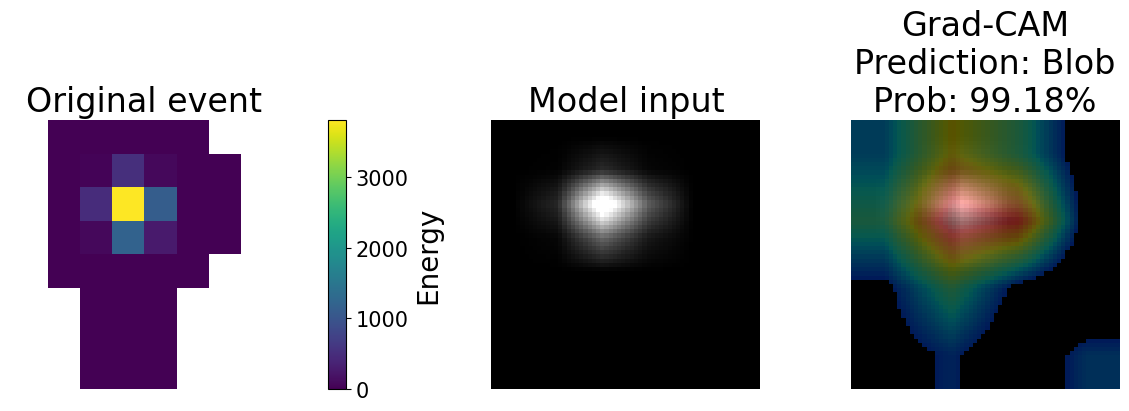

min: 0.0 max: 1.0 std: 0.2436016


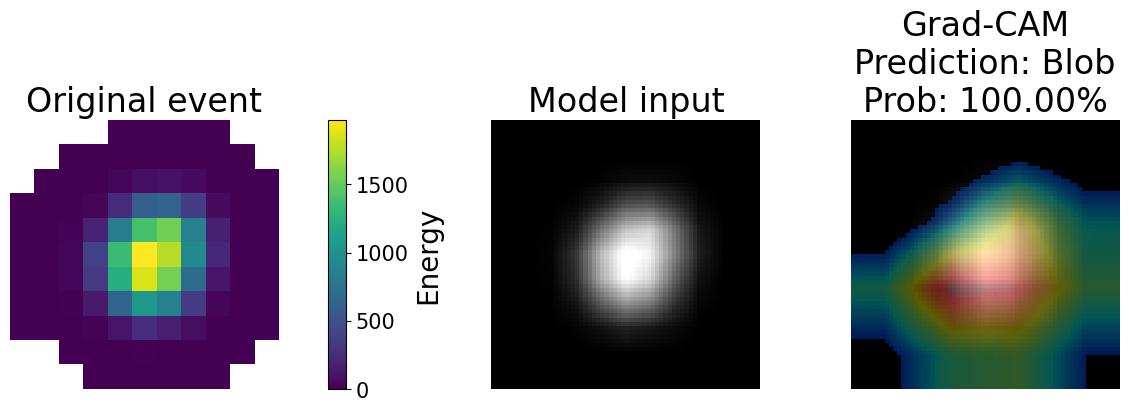

min: 0.0 max: 1.0 std: 0.29574242


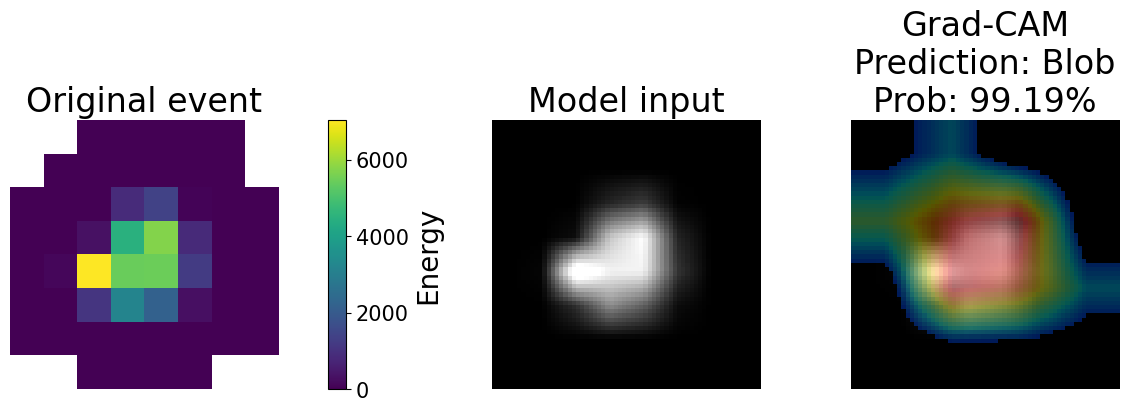

min: 0.0 max: 1.0 std: 0.23884201


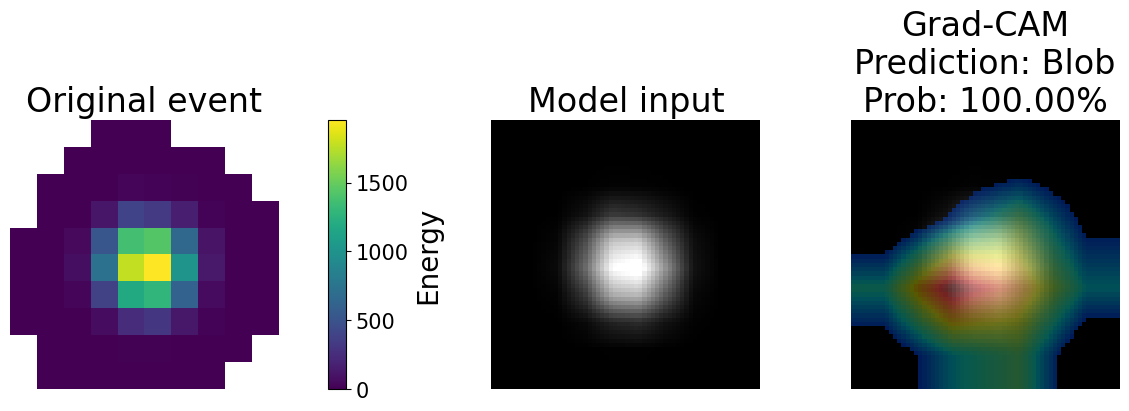

min: 0.0 max: 1.0 std: 0.2659999


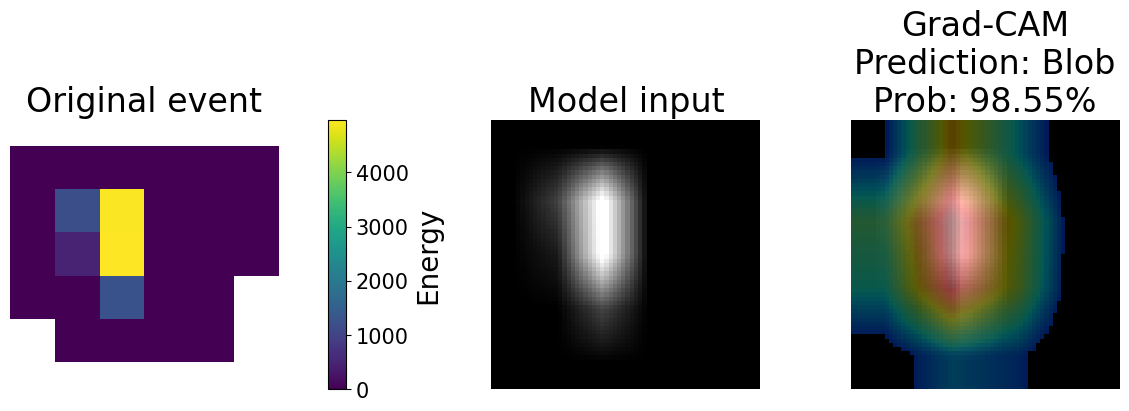

min: 0.0 max: 1.0 std: 0.19319095


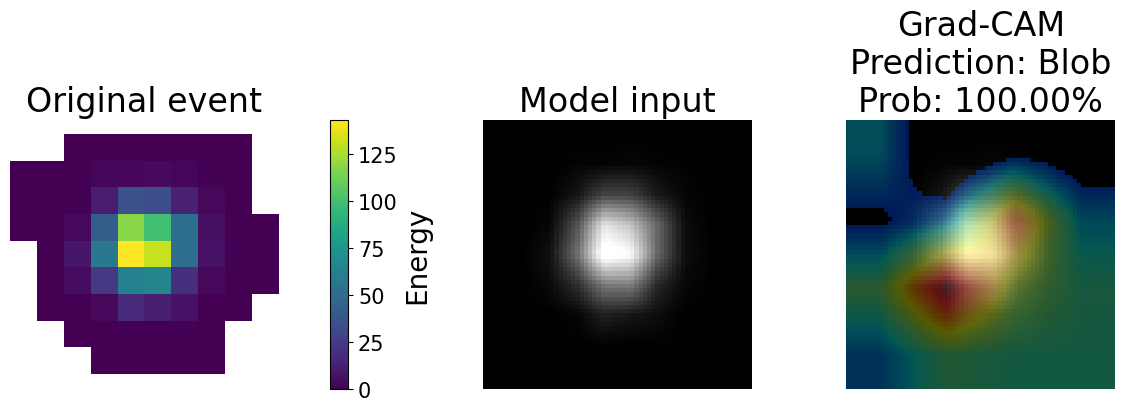

min: 0.0 max: 1.0 std: 0.22733621


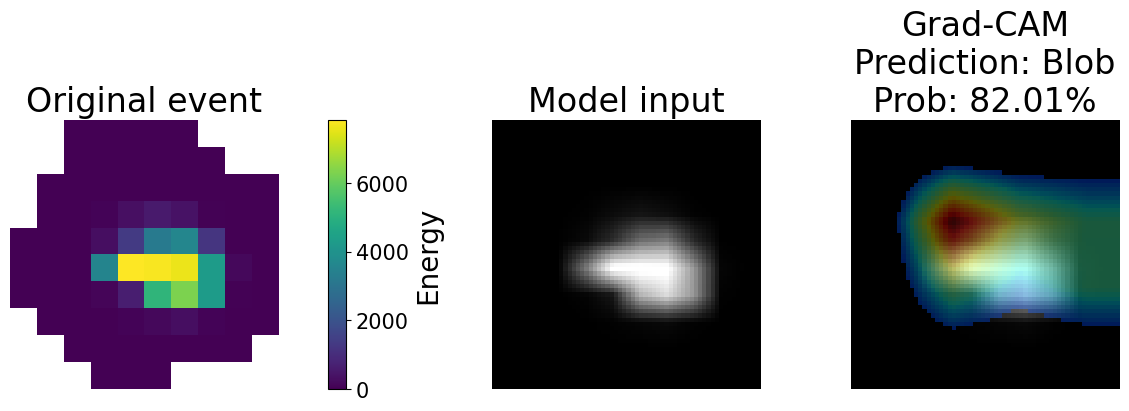

min: 0.0 max: 1.0 std: 0.22915773


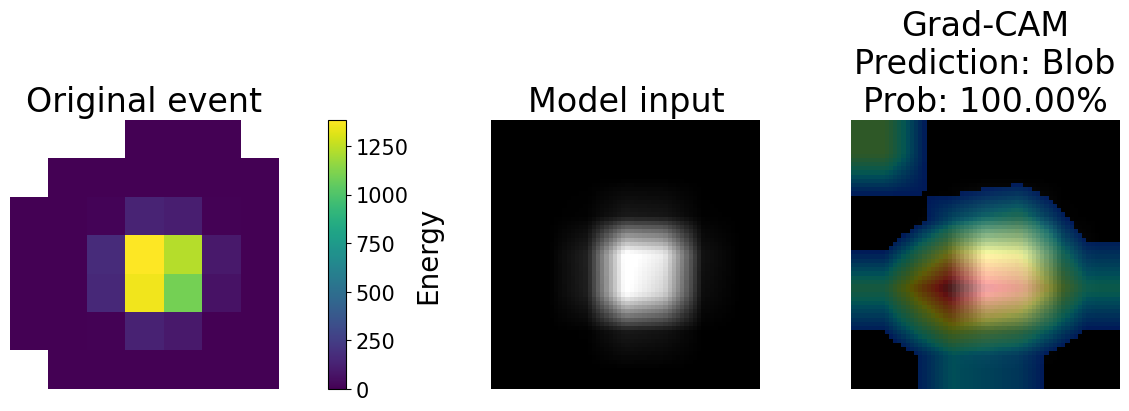

min: 0.0 max: 1.0 std: 0.23514605


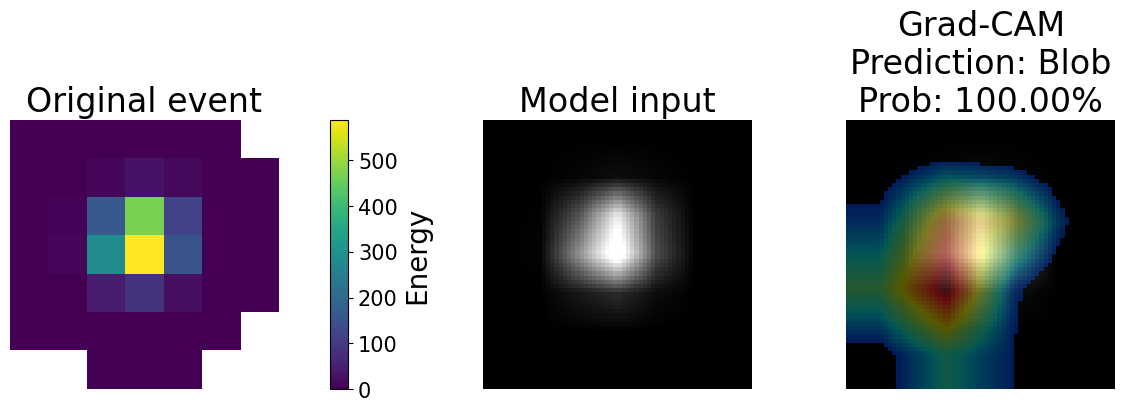

min: 0.0 max: 1.0 std: 0.24091299


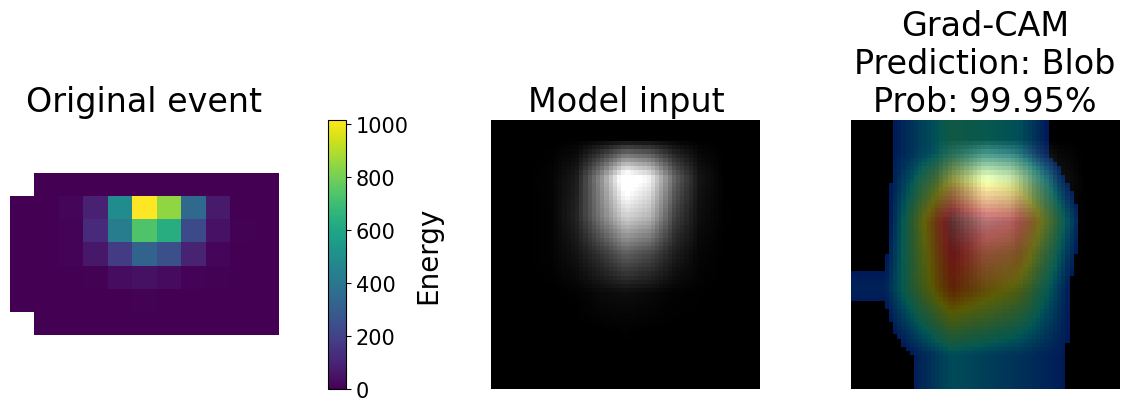

min: 0.0 max: 1.0 std: 0.1988577


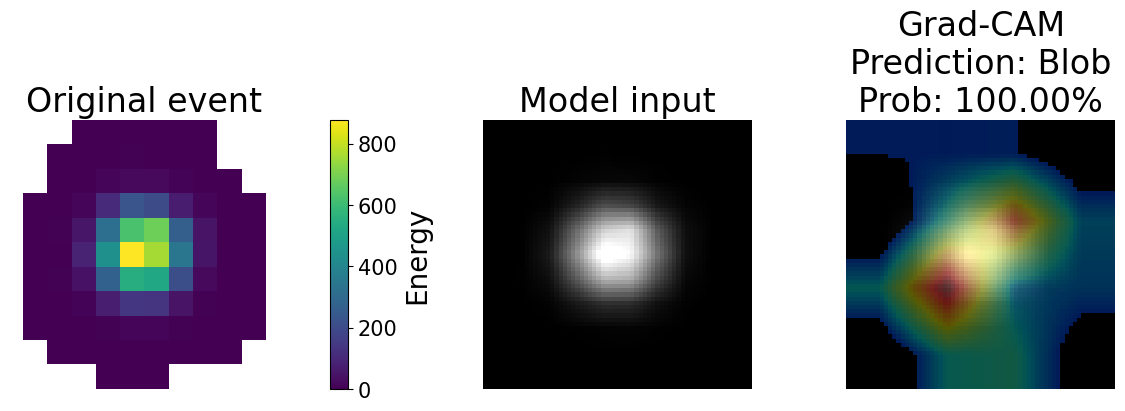

min: 0.0 max: 1.0 std: 0.206527


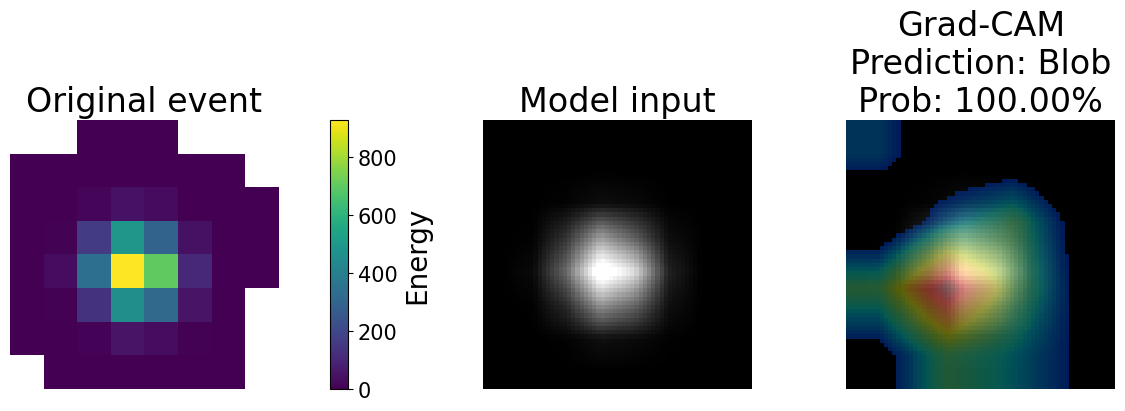

min: 0.0 max: 1.0 std: 0.2736687


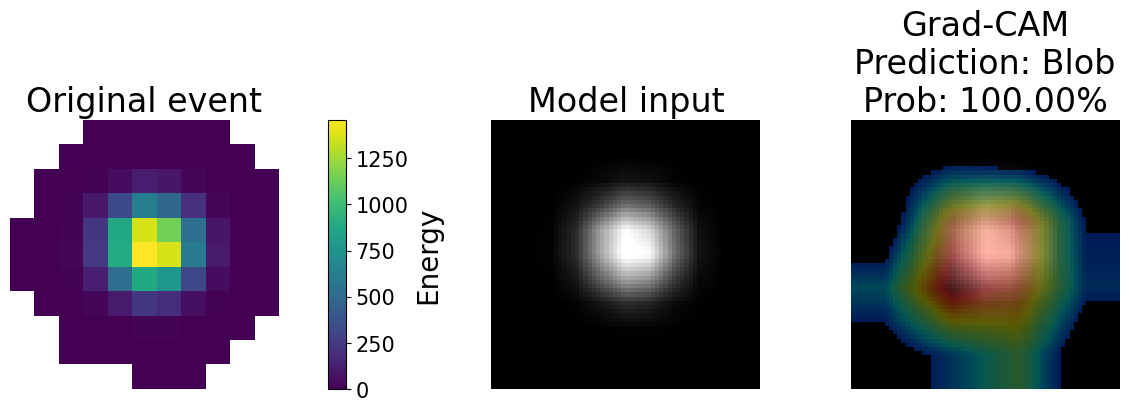

min: 0.0 max: 1.0 std: 0.22786292


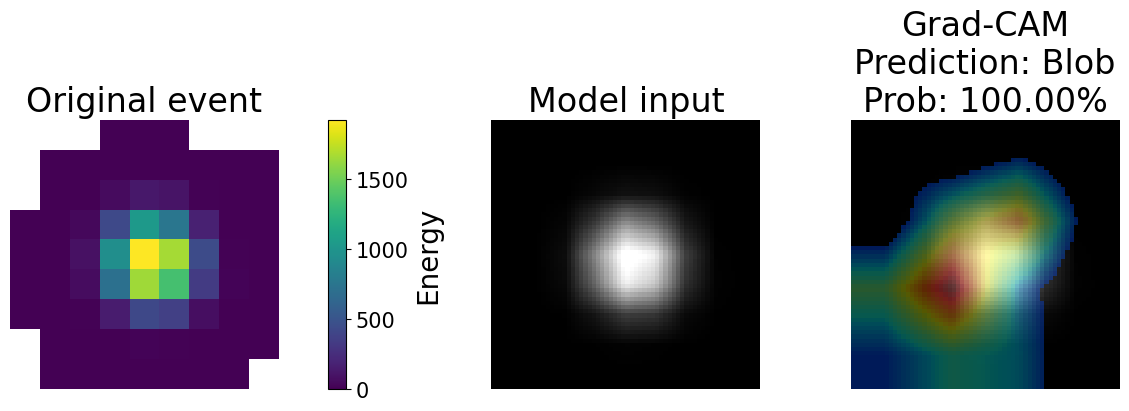

min: 0.0 max: 1.0 std: 0.20145963


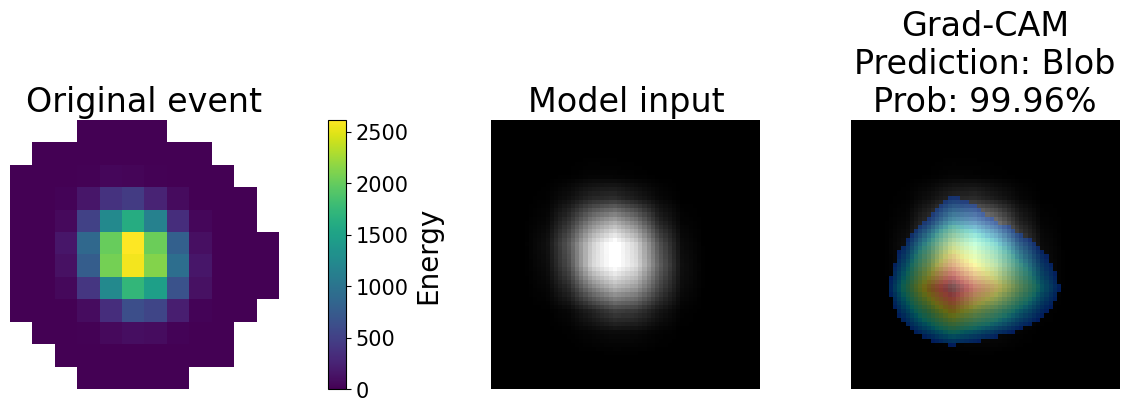

min: 0.0 max: 1.0 std: 0.24873741


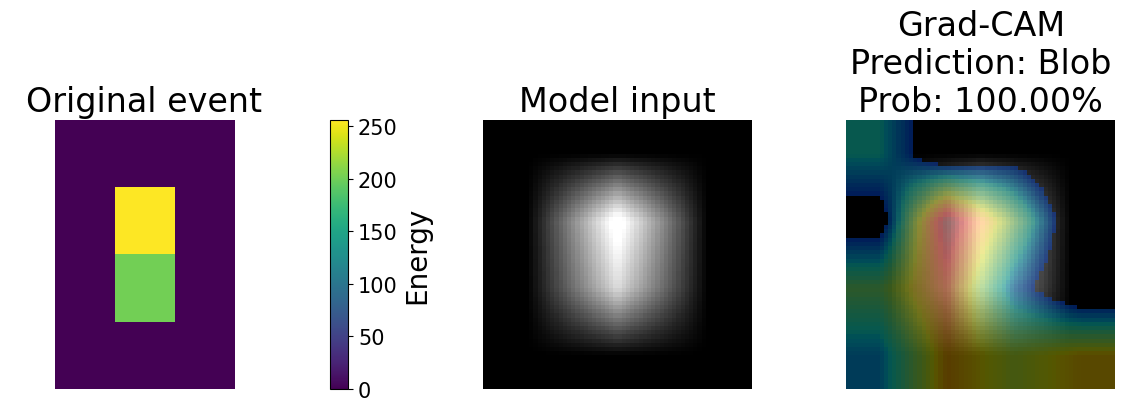

min: 0.0 max: 1.0 std: 0.20633012


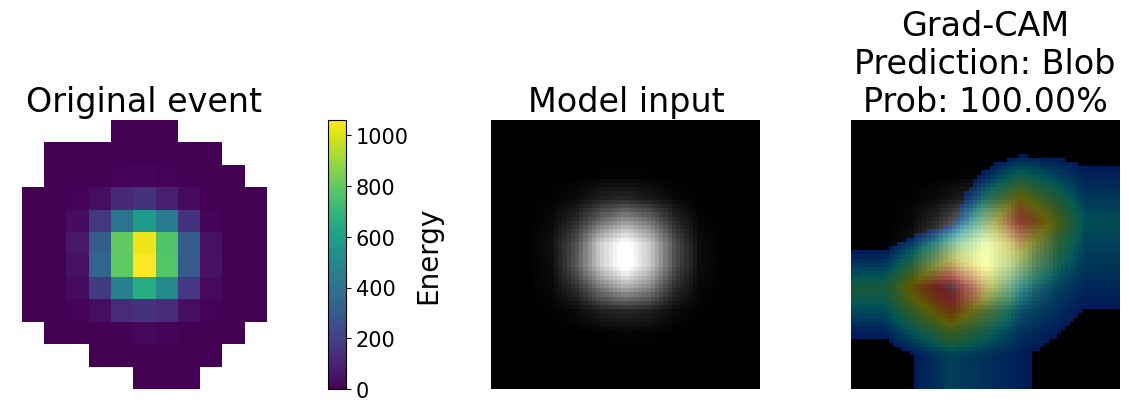

min: 0.0 max: 1.0 std: 0.20018445


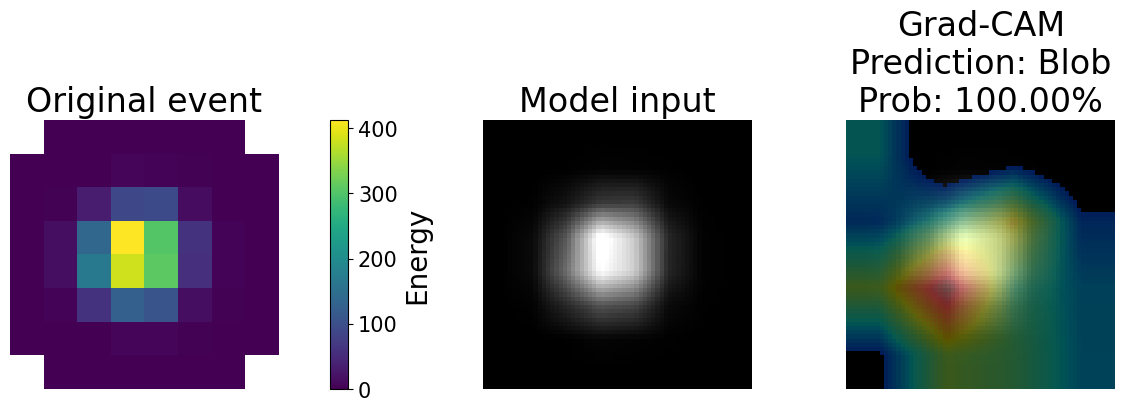

min: 0.0 max: 1.0 std: 0.28318888


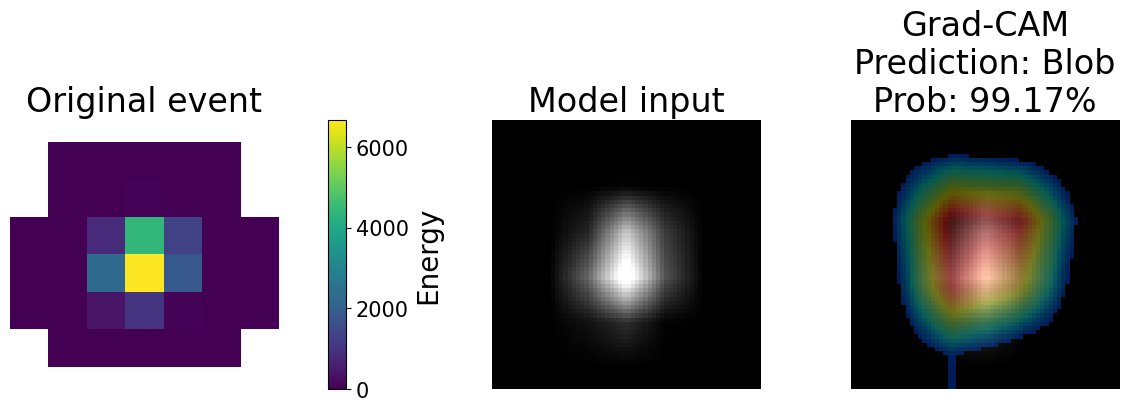

min: 0.0 max: 1.0 std: 0.23219025


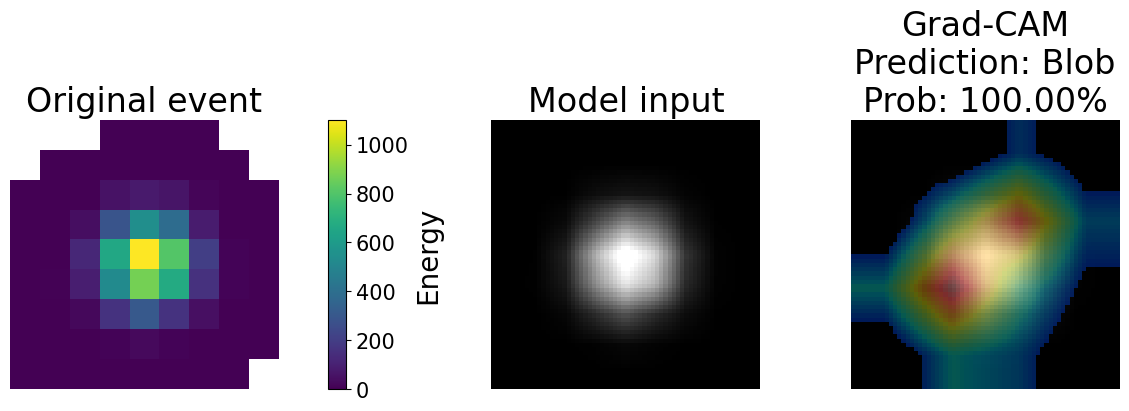


CORRECT (main figs): Diffusion Hit
min: 0.0 max: 1.0 std: 0.2569202


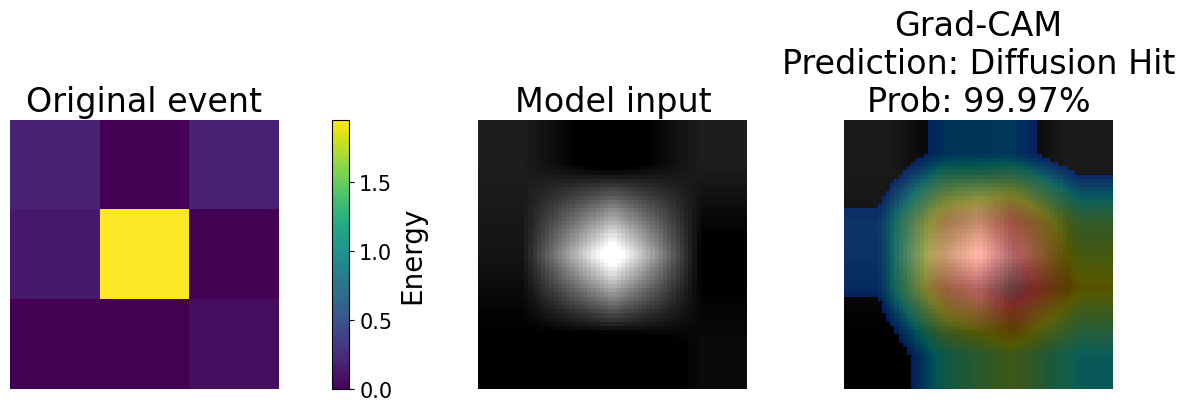

min: 0.0 max: 1.0 std: 0.25820592


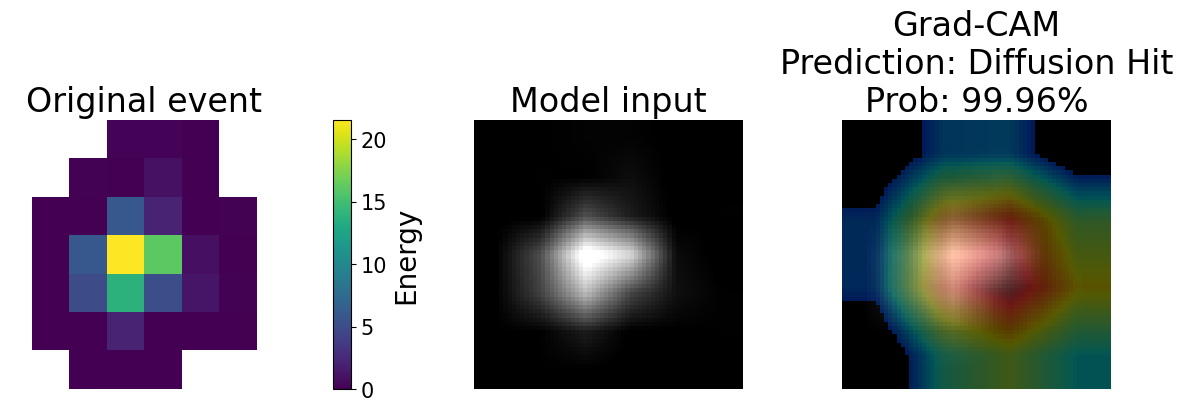

min: 0.0 max: 1.0 std: 0.25662923


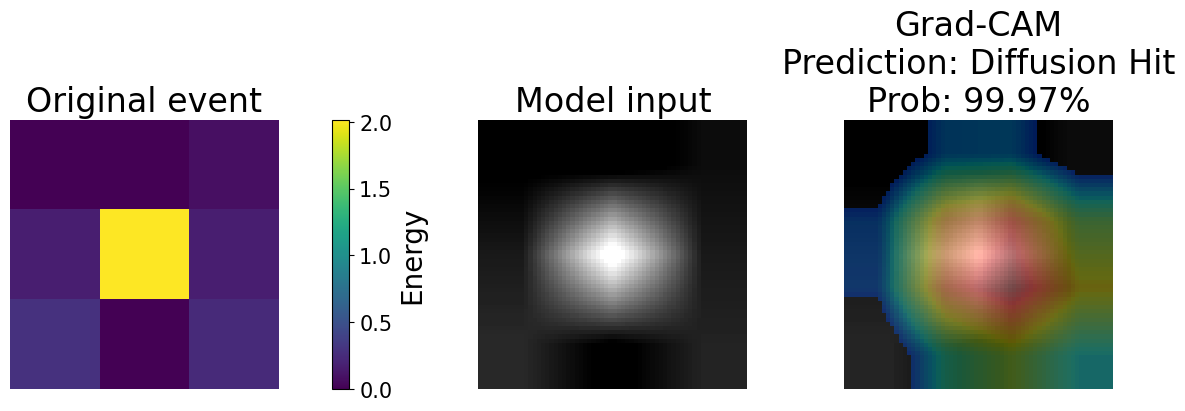

min: 0.0 max: 1.0 std: 0.25949183


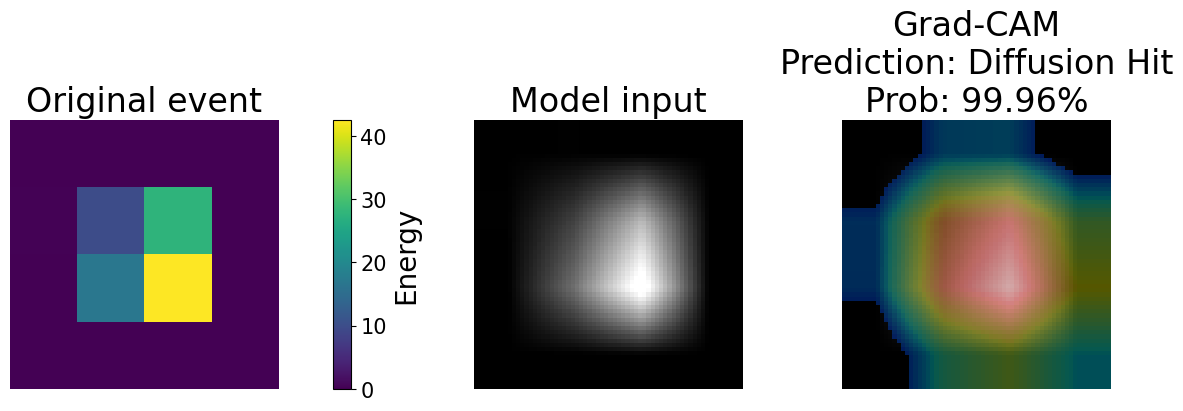

min: 0.0 max: 1.0 std: 0.25787595


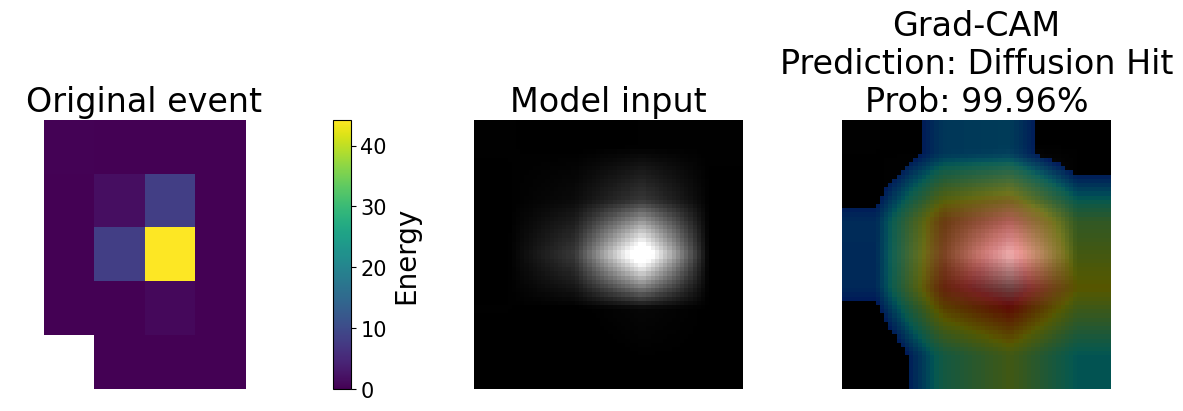

min: 0.0 max: 1.0 std: 0.25685745


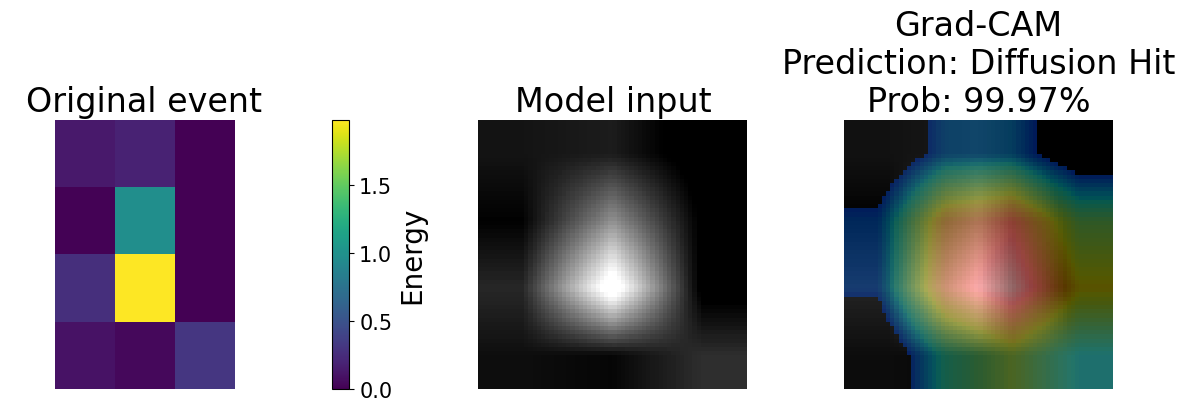

min: 0.0 max: 1.0 std: 0.2569599


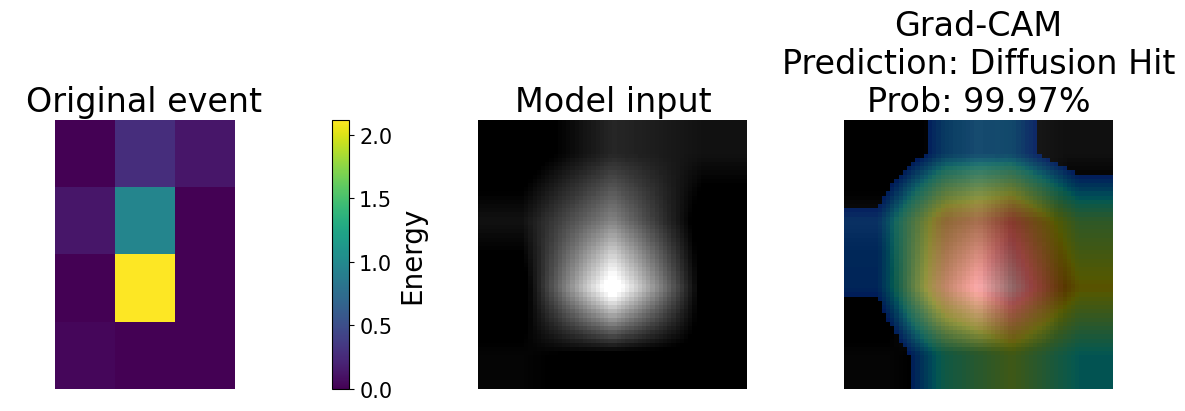

min: 0.0 max: 1.0 std: 0.2557257


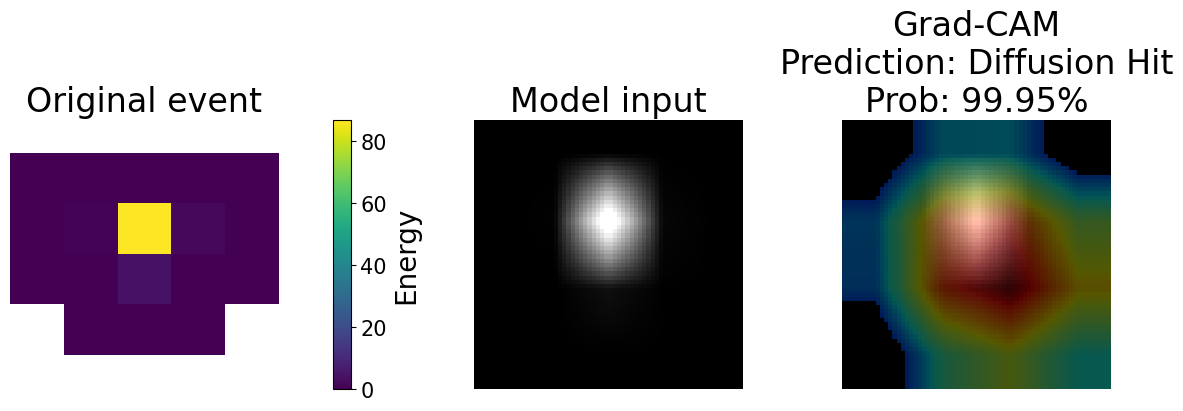


CORRECT (main figs): Electron
min: 0.0 max: 1.0 std: 0.23534456


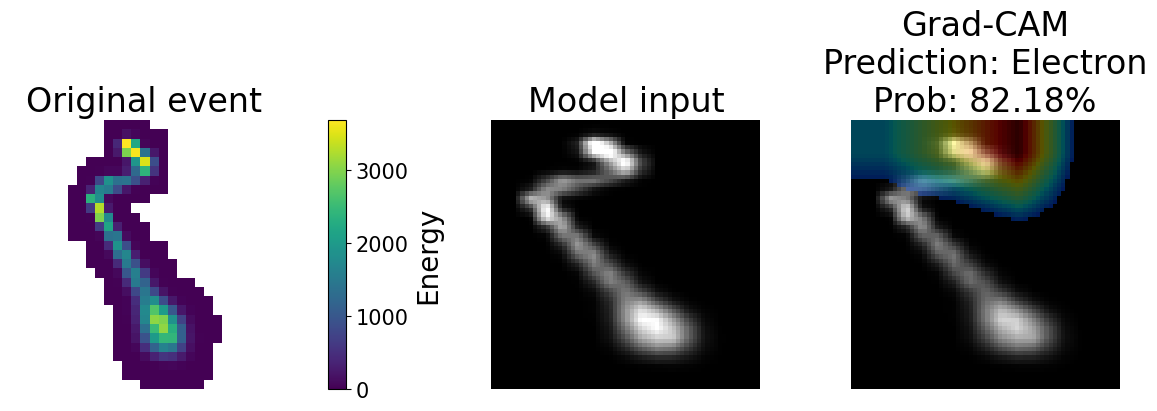

min: 0.0 max: 1.0 std: 0.2577946


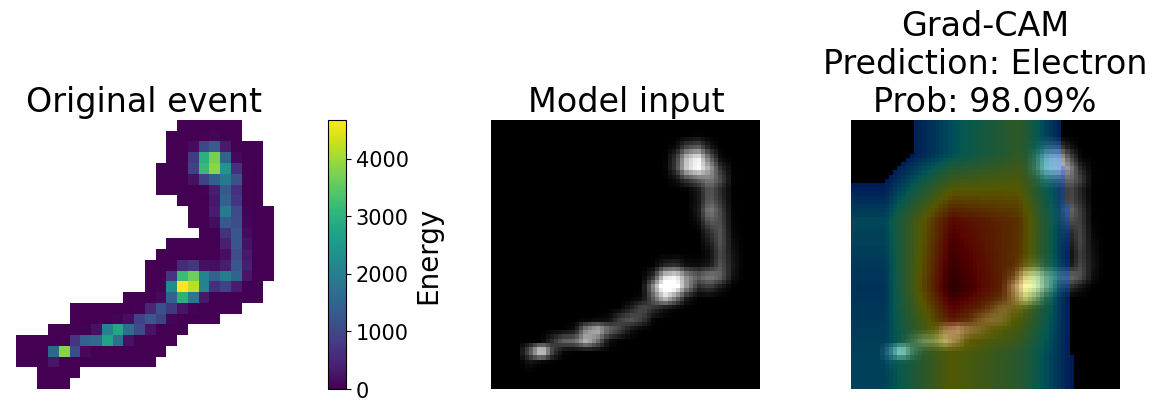

min: 0.0 max: 1.0 std: 0.278715


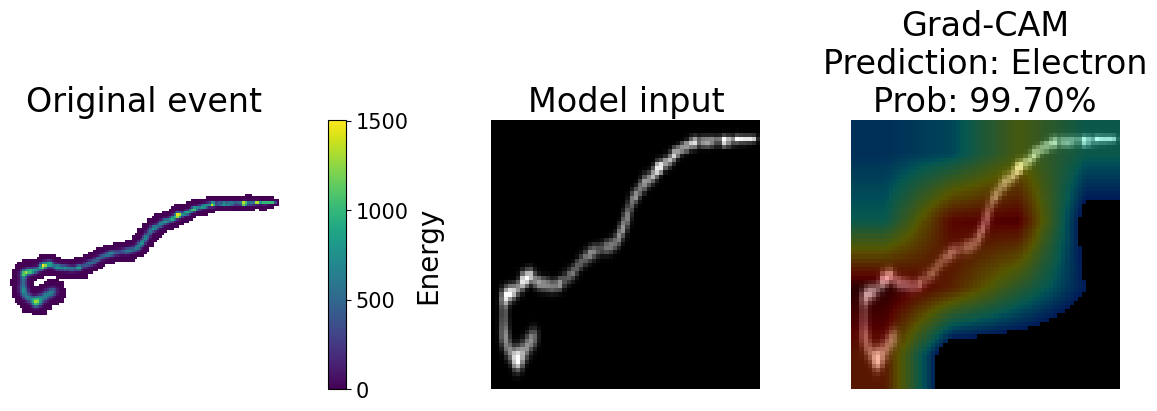

min: 0.0 max: 1.0 std: 0.27870718


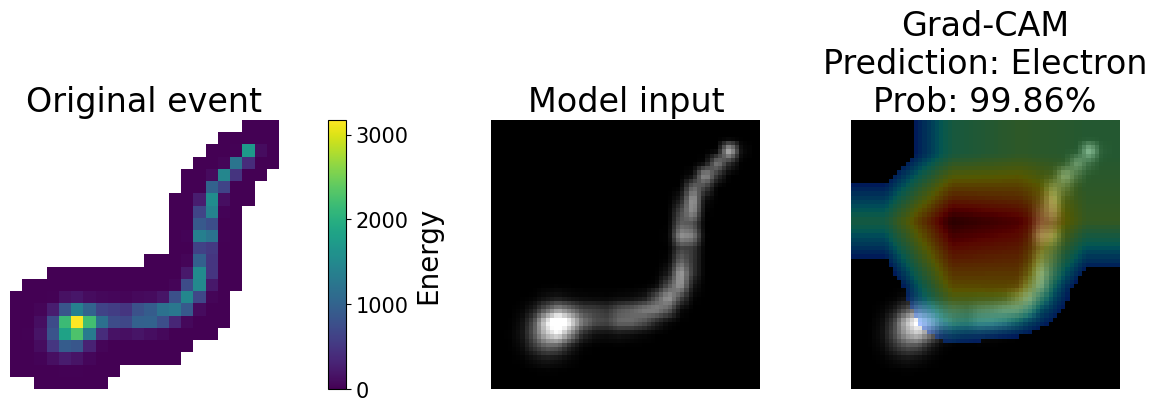

min: 0.0 max: 1.0 std: 0.26667237


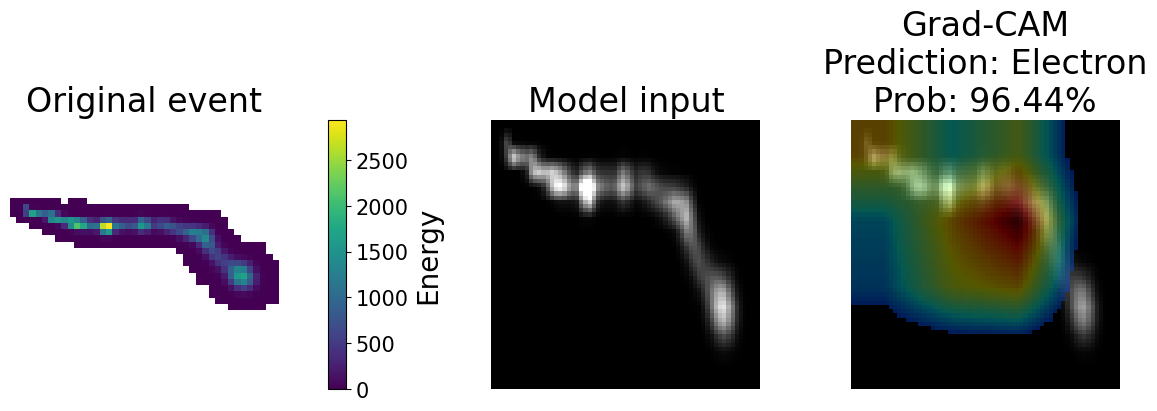

min: 0.0 max: 1.0 std: 0.24563839


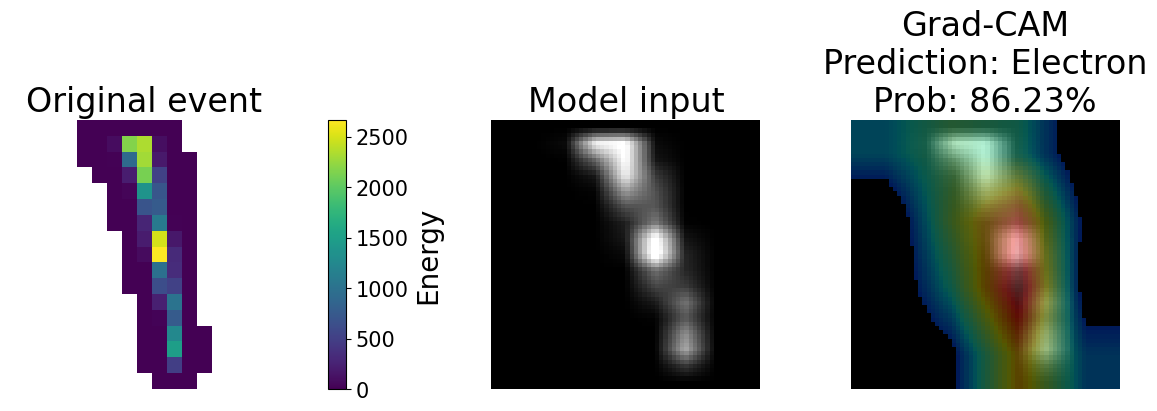

min: 0.0 max: 1.0 std: 0.23204184


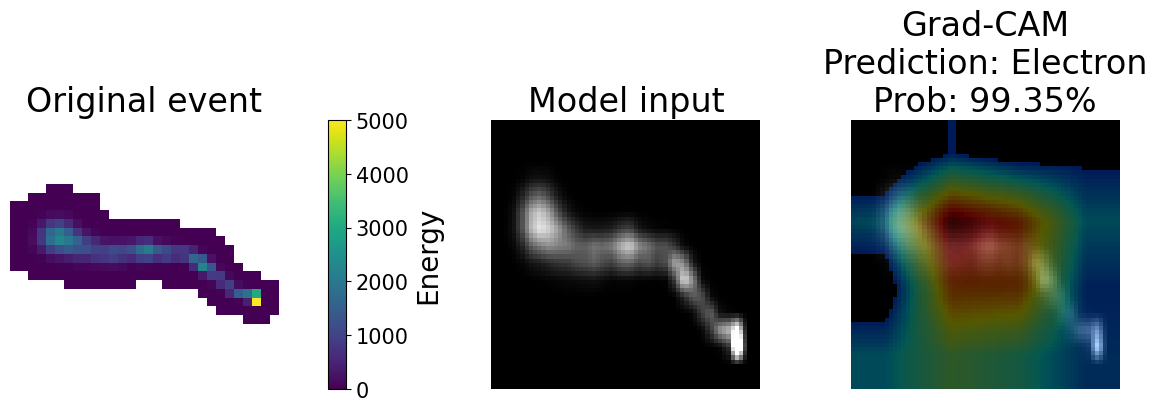

min: 0.0 max: 1.0 std: 0.24925393


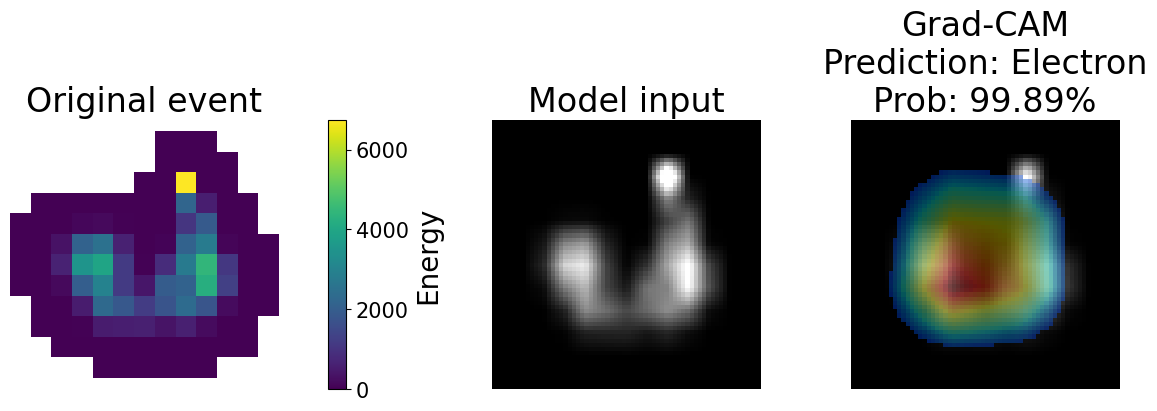

min: 0.0 max: 1.0 std: 0.27452794


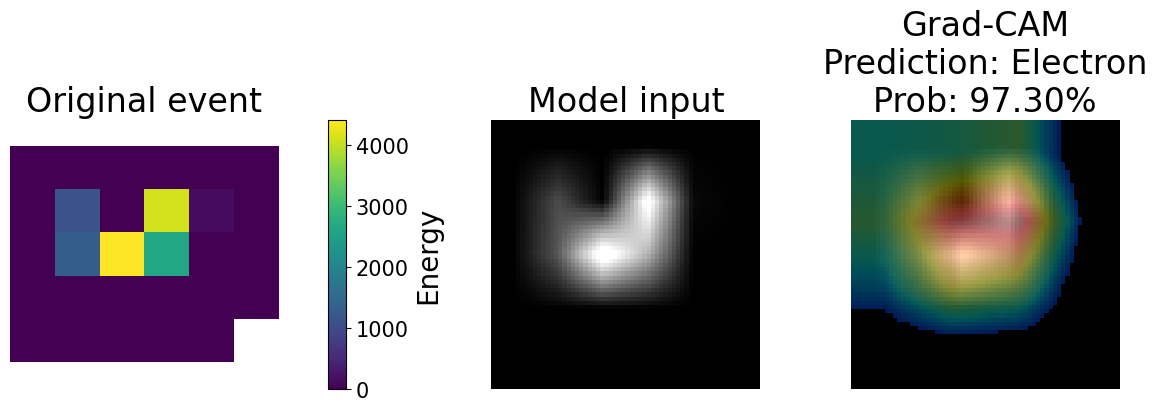

min: 0.0 max: 1.0 std: 0.27087438


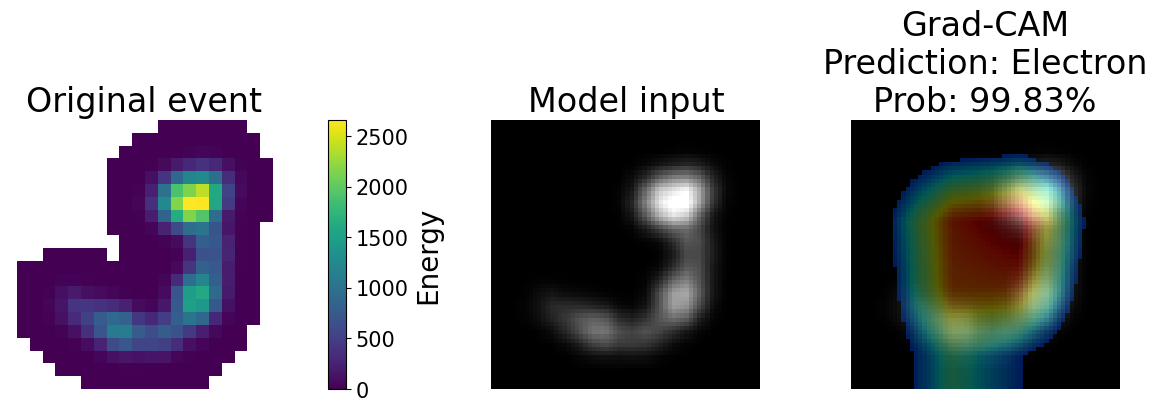

min: 0.0 max: 1.0 std: 0.2917608


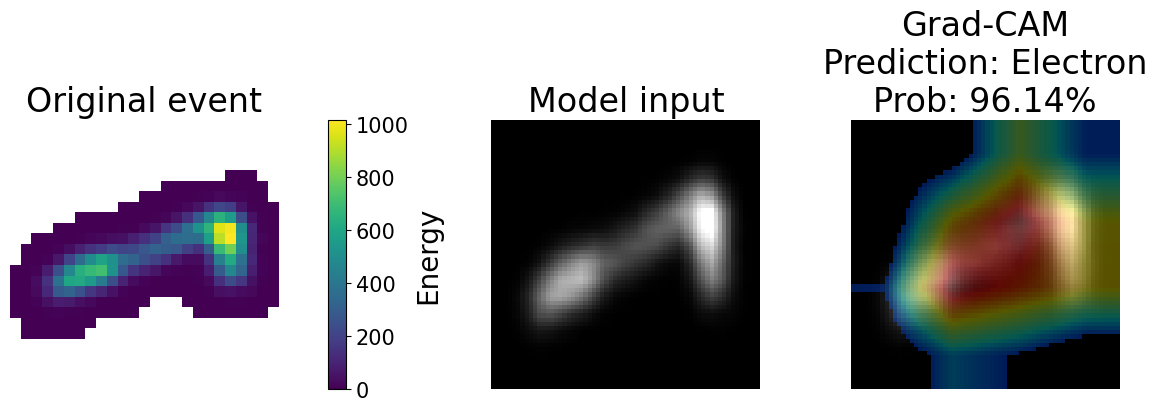

min: 0.0 max: 1.0 std: 0.25033128


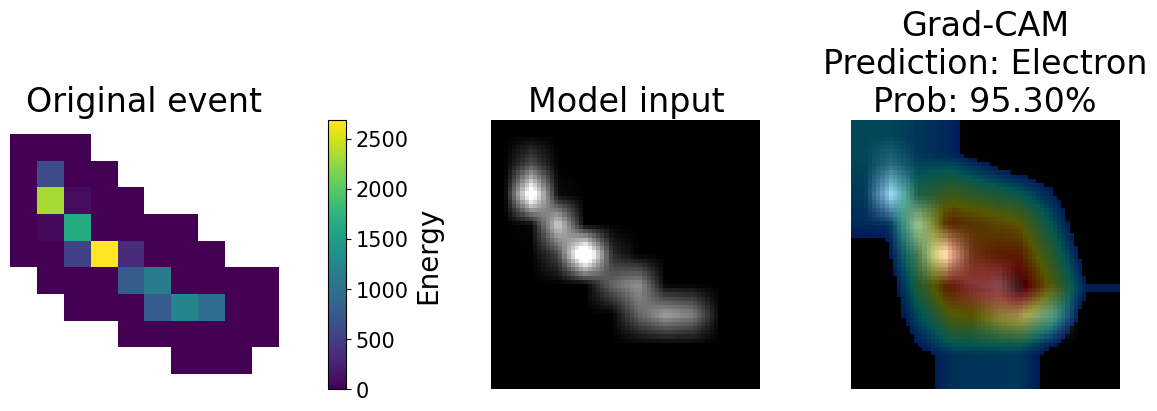

min: 0.0 max: 1.0 std: 0.23917088


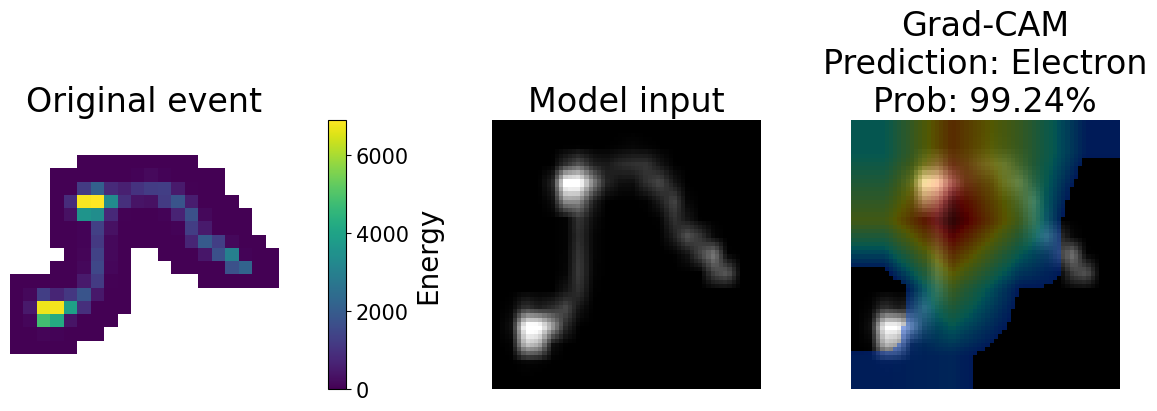

min: 0.0 max: 1.0 std: 0.22824286


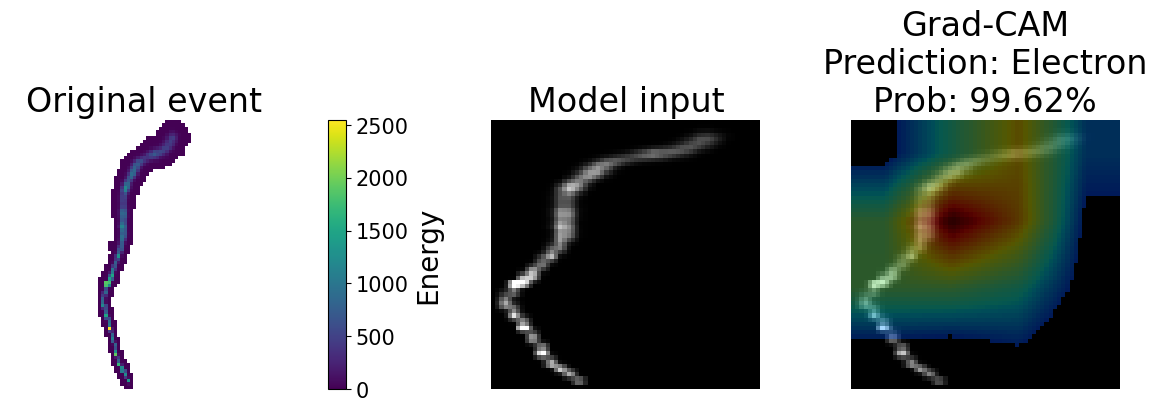

min: 0.0 max: 1.0 std: 0.23131591


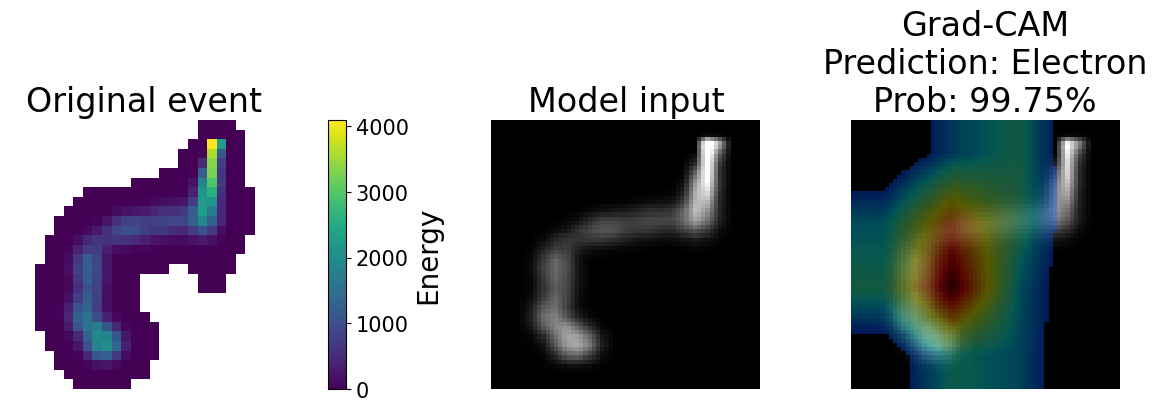

min: 0.0 max: 1.0 std: 0.19769481


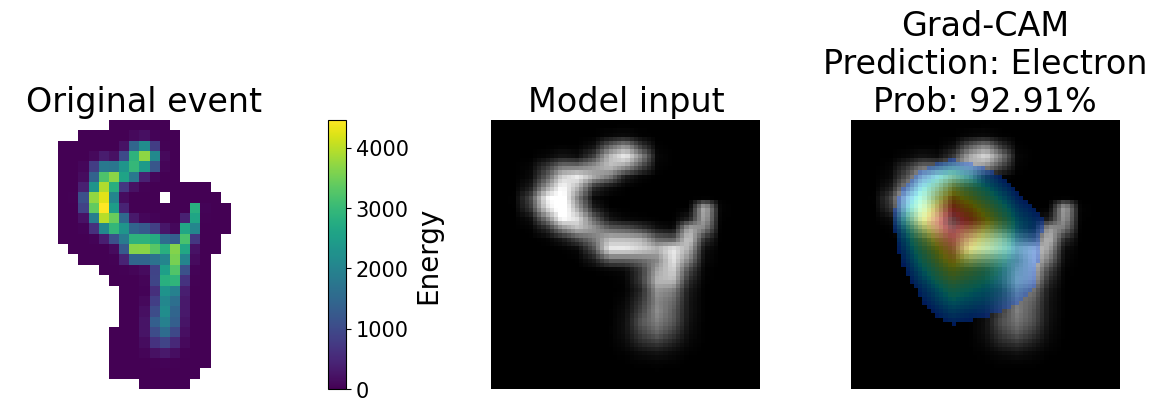

min: 0.0 max: 1.0 std: 0.23650663


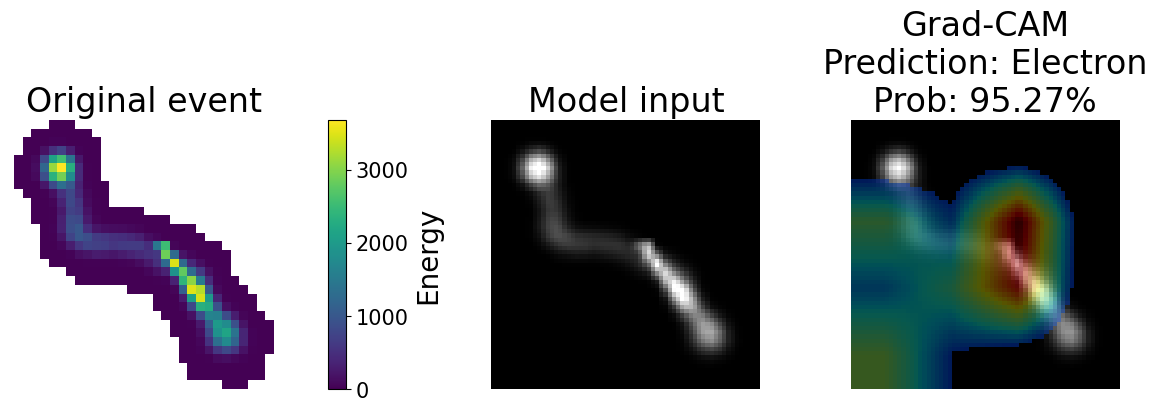

min: 0.0 max: 1.0 std: 0.2999151


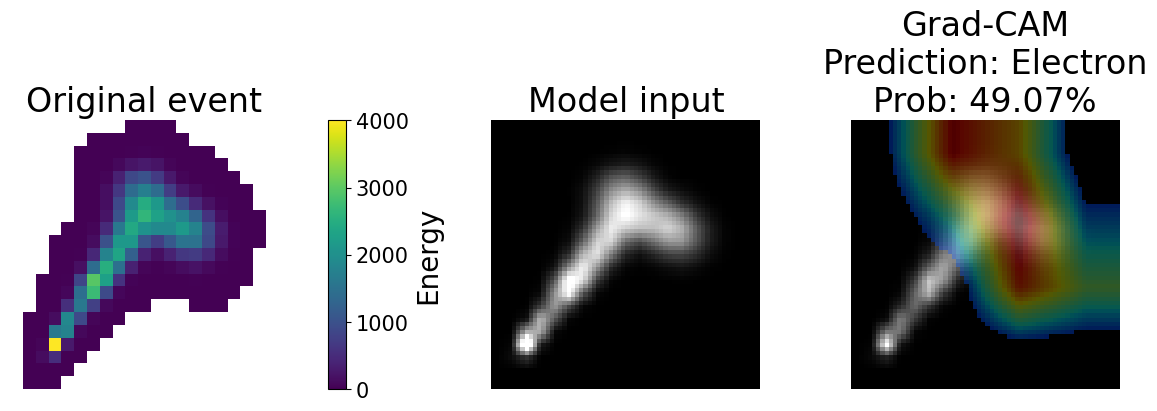

min: 0.0 max: 1.0 std: 0.22353166


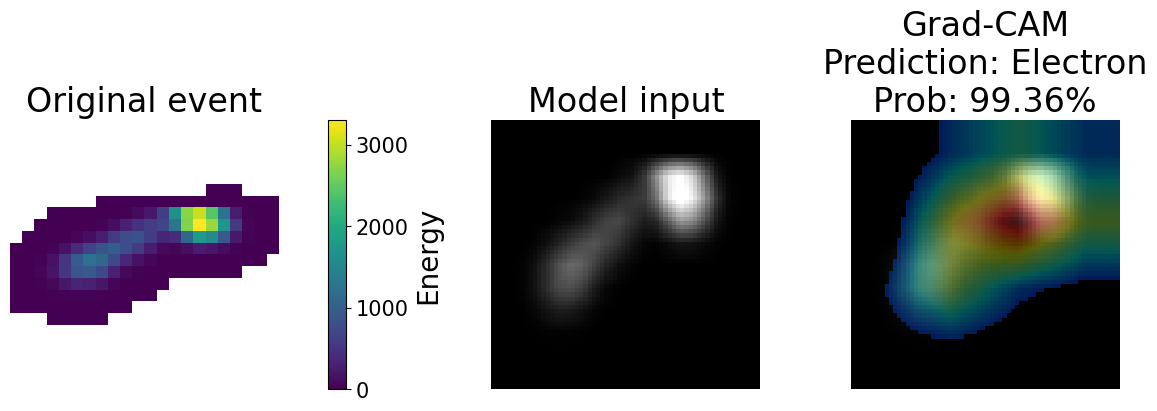

min: 0.0 max: 1.0 std: 0.21605958


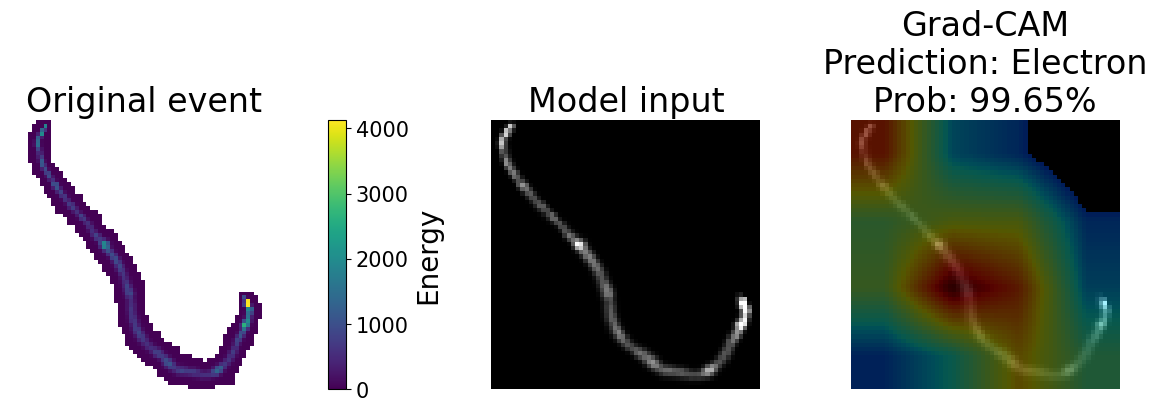


CORRECT (main figs): Muon
min: 0.0 max: 1.0 std: 0.19174974


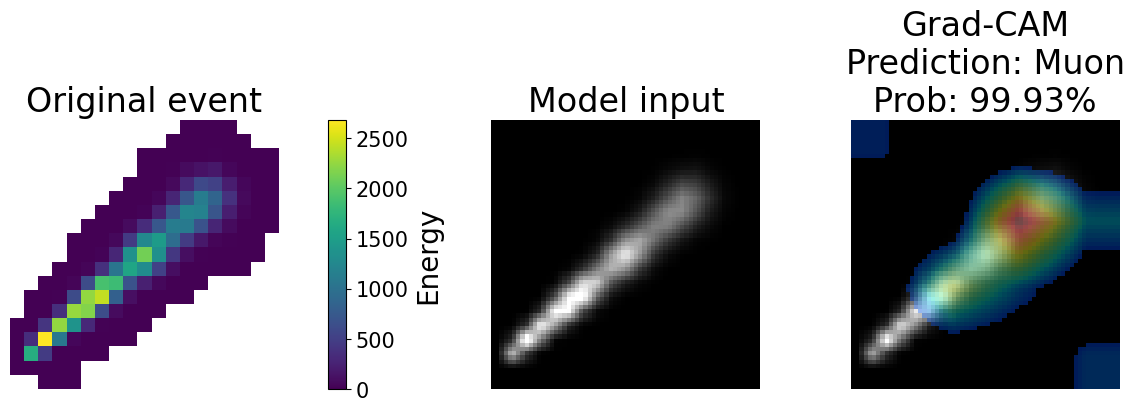

min: 0.0 max: 1.0 std: 0.2207698


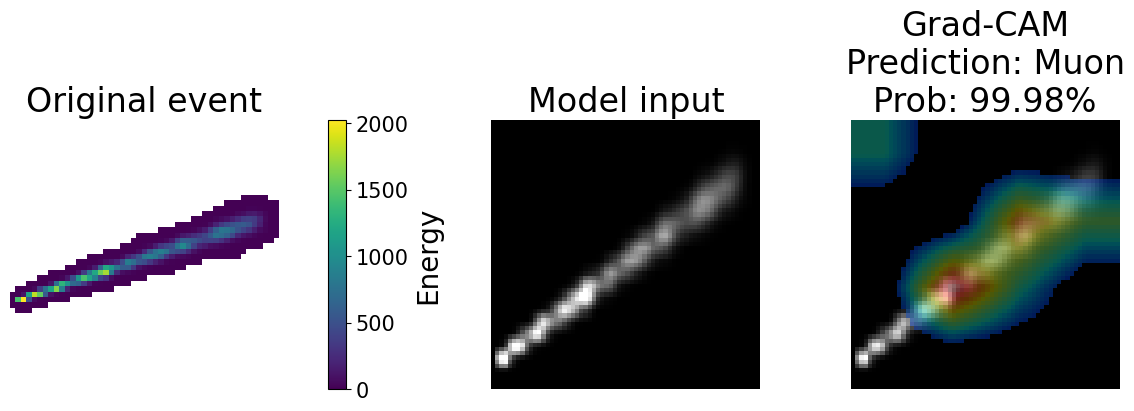

min: 0.0 max: 1.0 std: 0.25319365


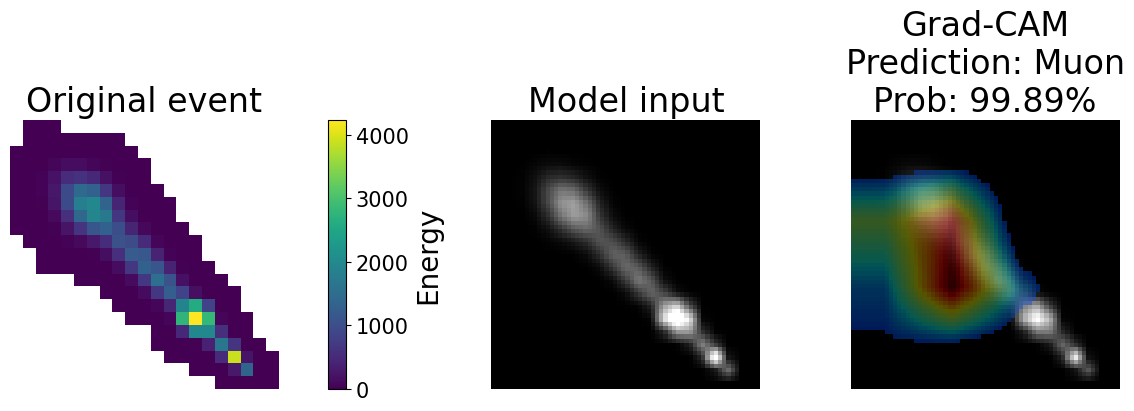

min: 0.0 max: 1.0 std: 0.23620789


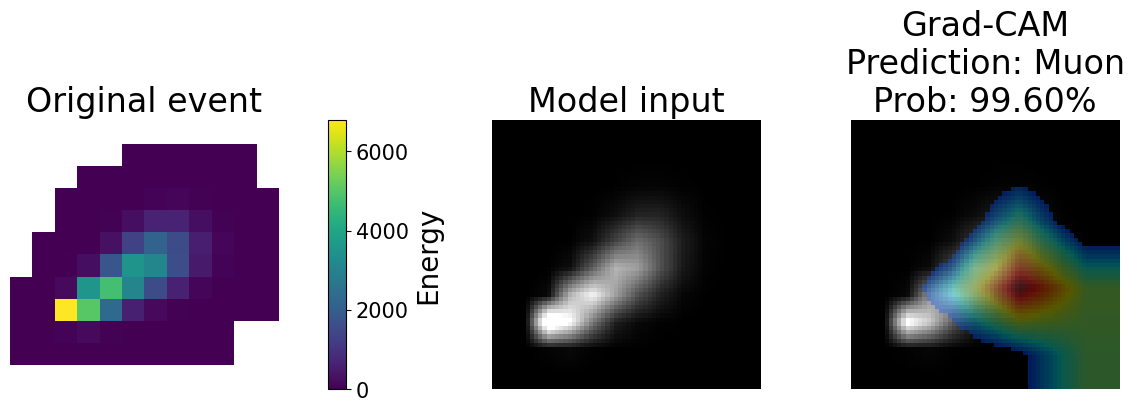

min: 0.0 max: 1.0 std: 0.30744997


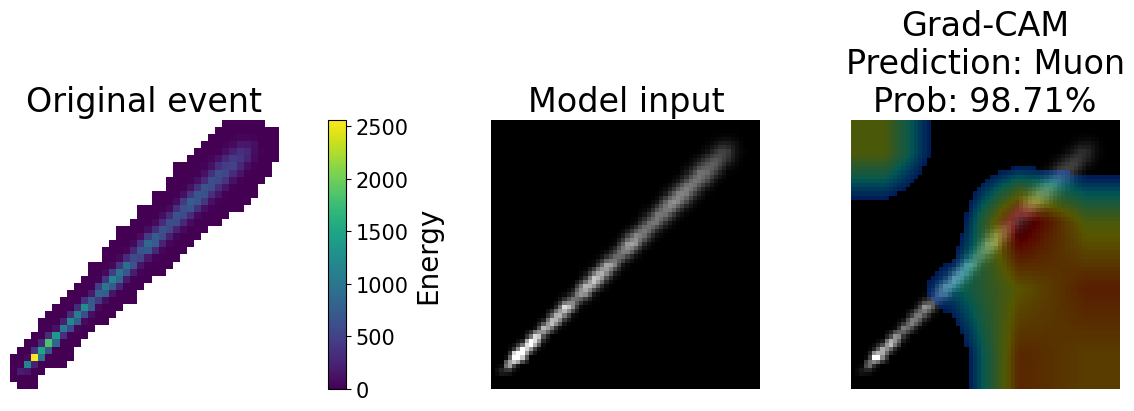

min: 0.0 max: 1.0 std: 0.21438824


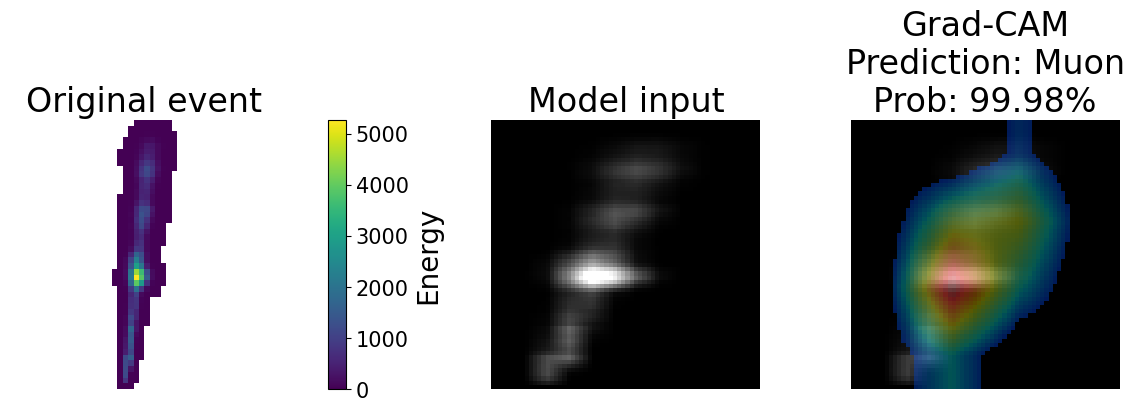

min: 0.0 max: 1.0 std: 0.28482258


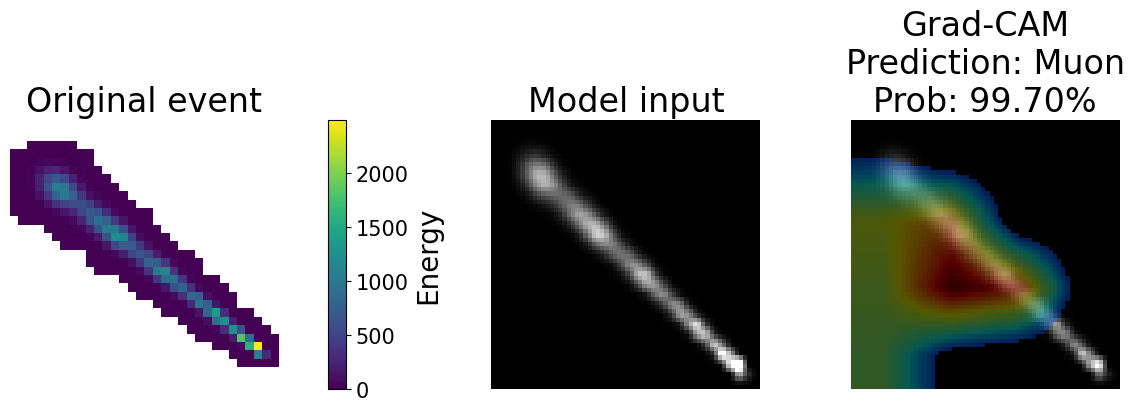

min: 0.0 max: 1.0 std: 0.25390652


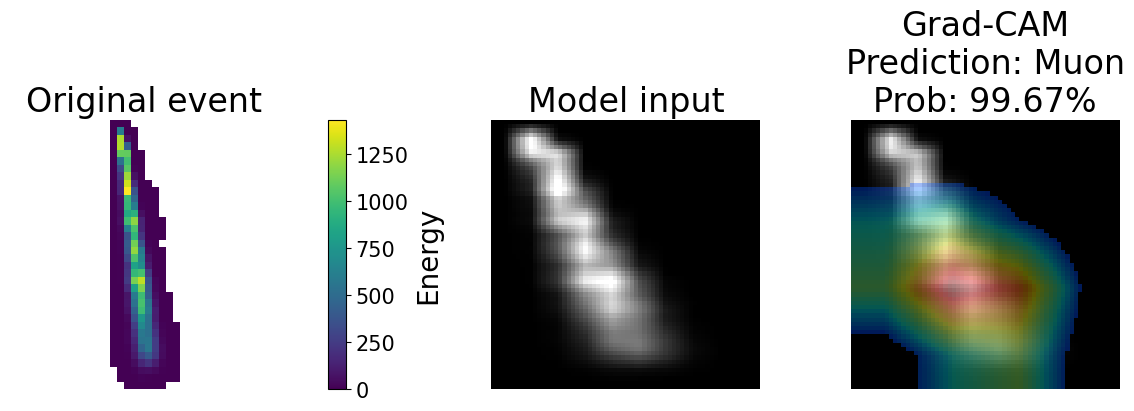

min: 0.0 max: 1.0 std: 0.21997909


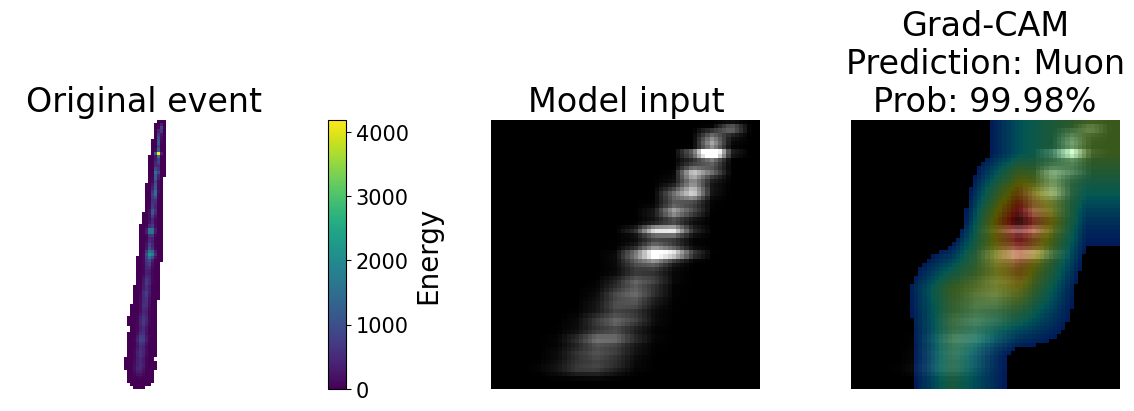

min: 0.0 max: 1.0 std: 0.22345927


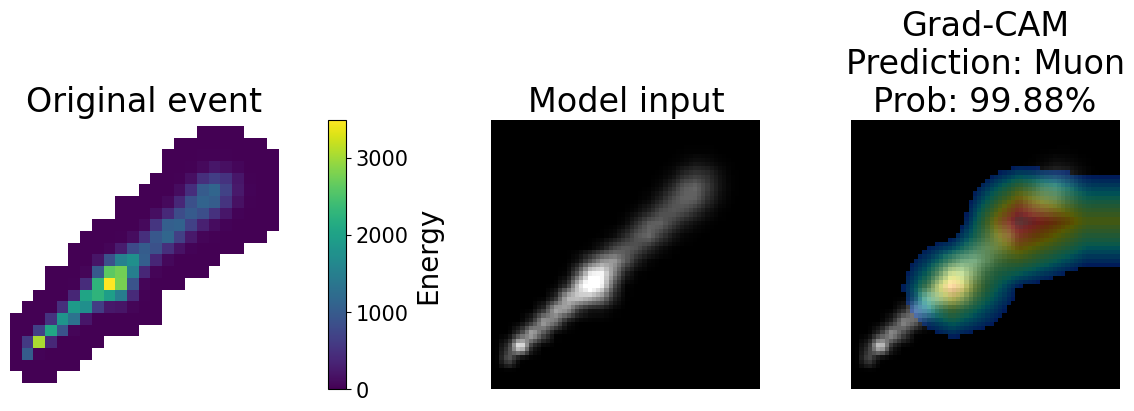

min: 0.0 max: 1.0 std: 0.22040816


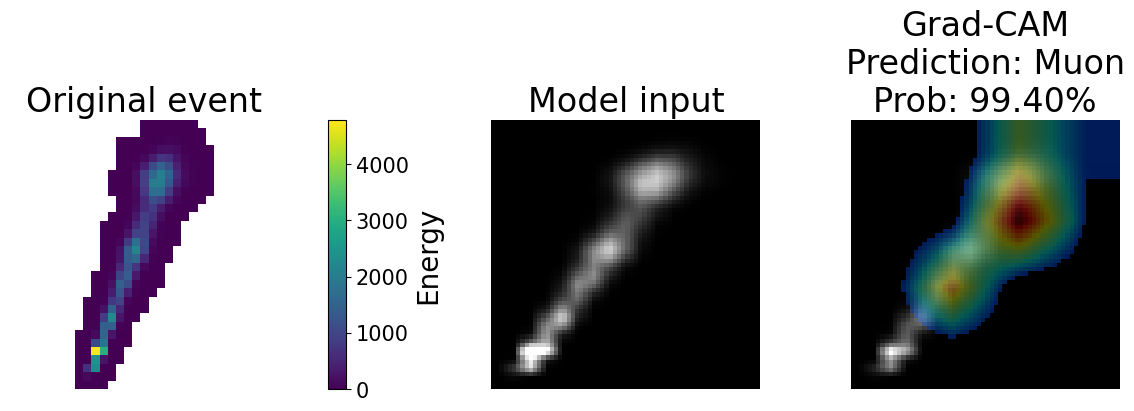

min: 0.0 max: 1.0 std: 0.25918114


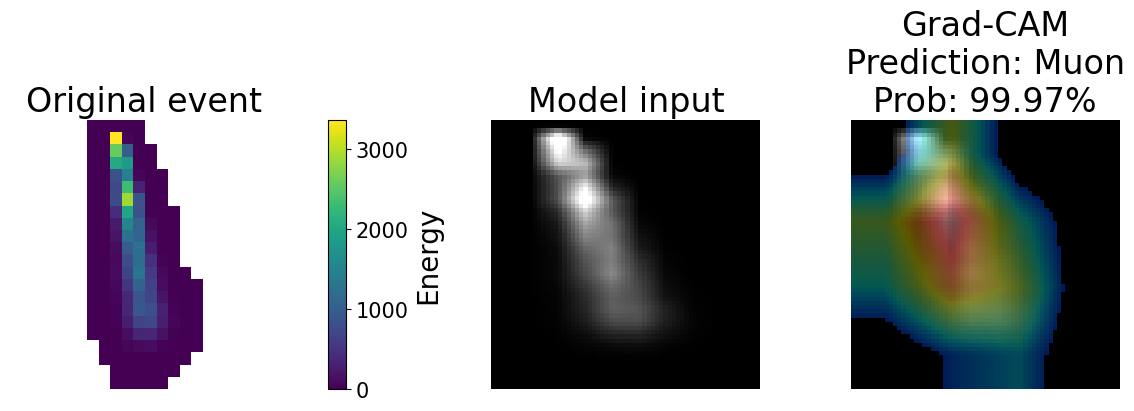

min: 0.0 max: 1.0 std: 0.2468949


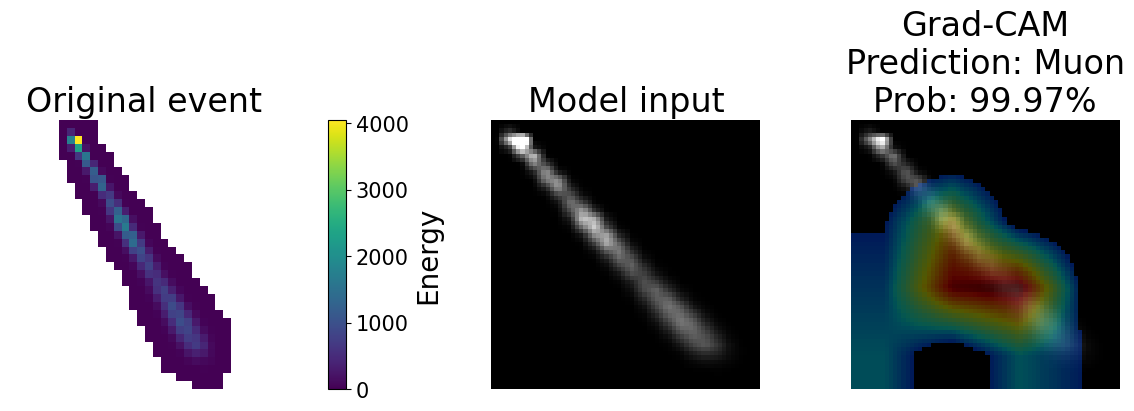

min: 0.0 max: 1.0 std: 0.28570774


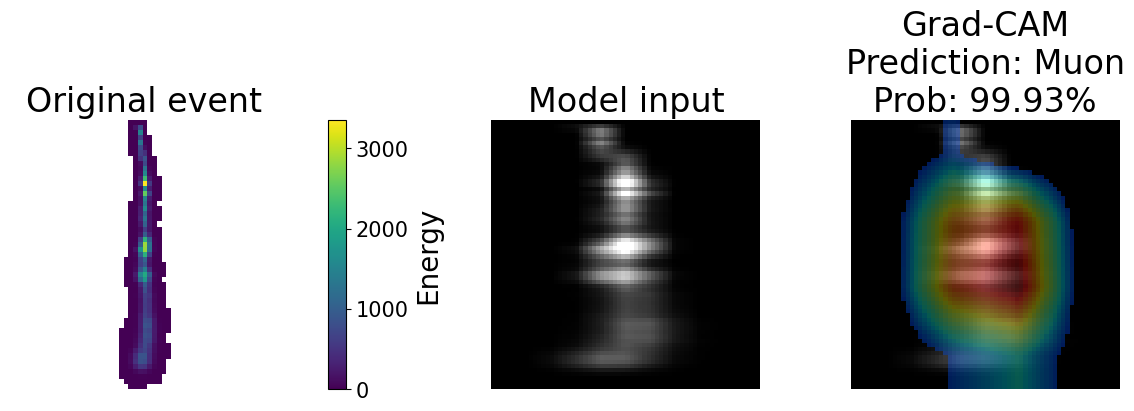

min: 0.0 max: 1.0 std: 0.2518799


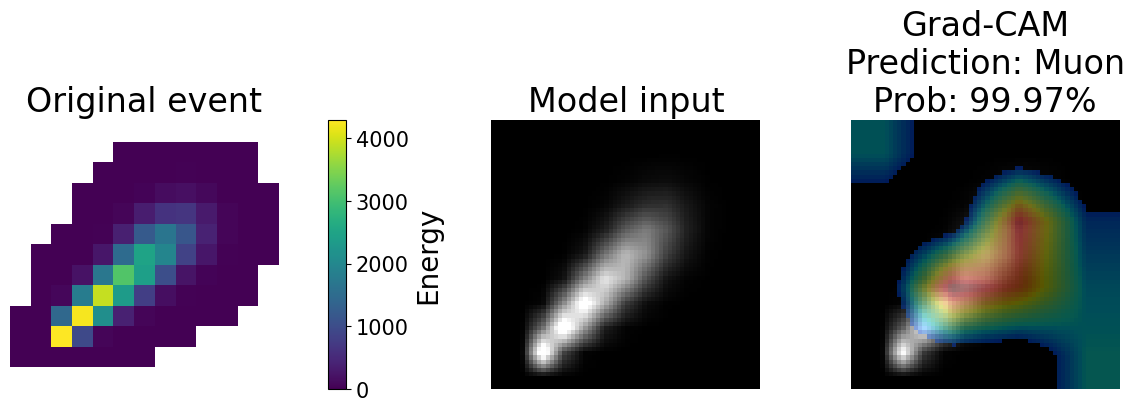

min: 0.0 max: 1.0 std: 0.2534168


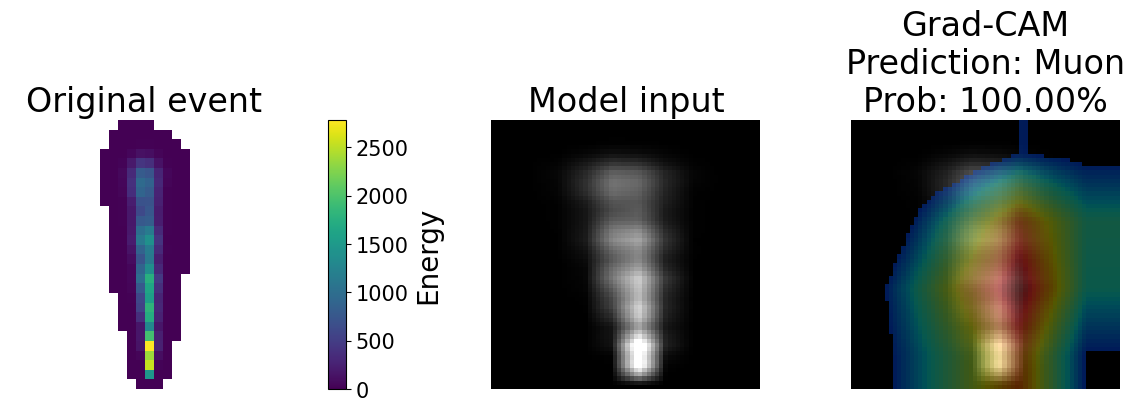

min: 0.0 max: 1.0 std: 0.26329076


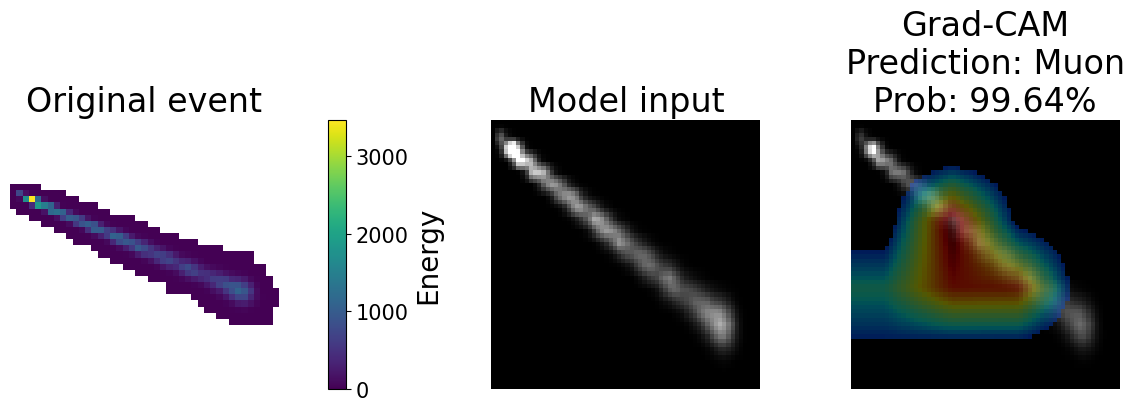

min: 0.0 max: 1.0 std: 0.2639201


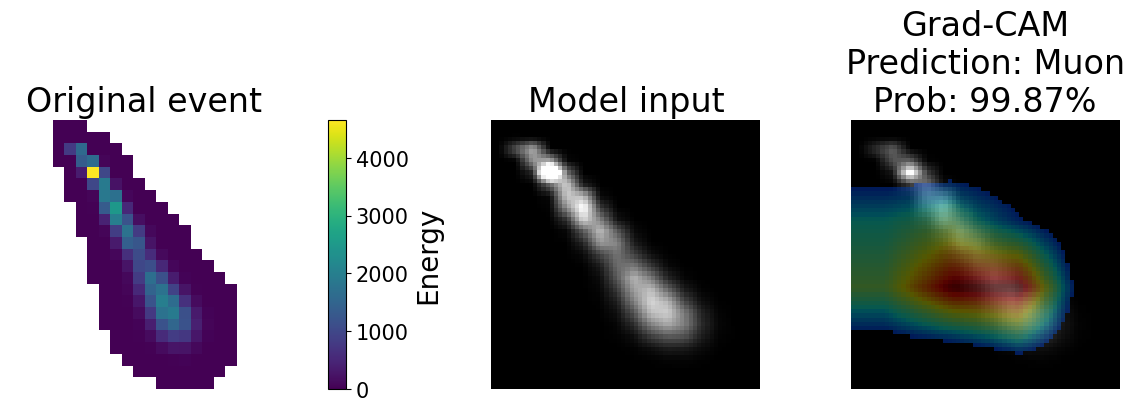

min: 0.0 max: 1.0 std: 0.28118542


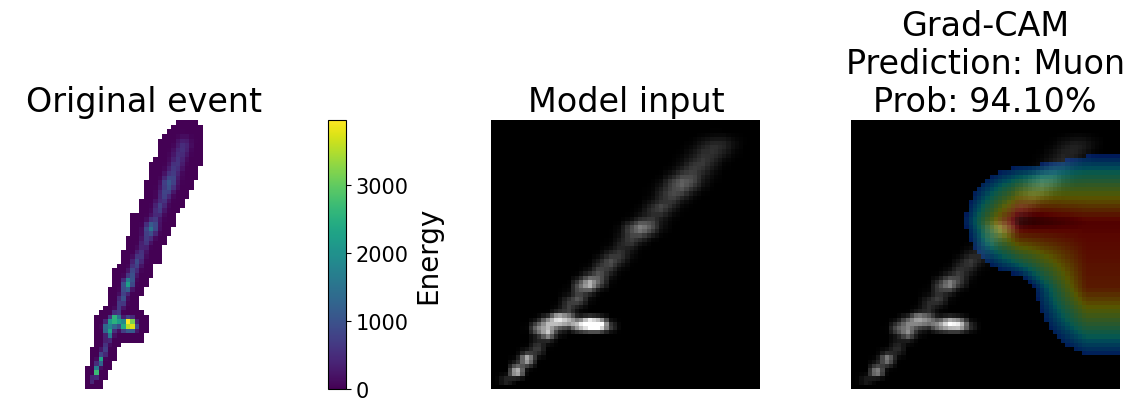

min: 0.0 max: 1.0 std: 0.20216349


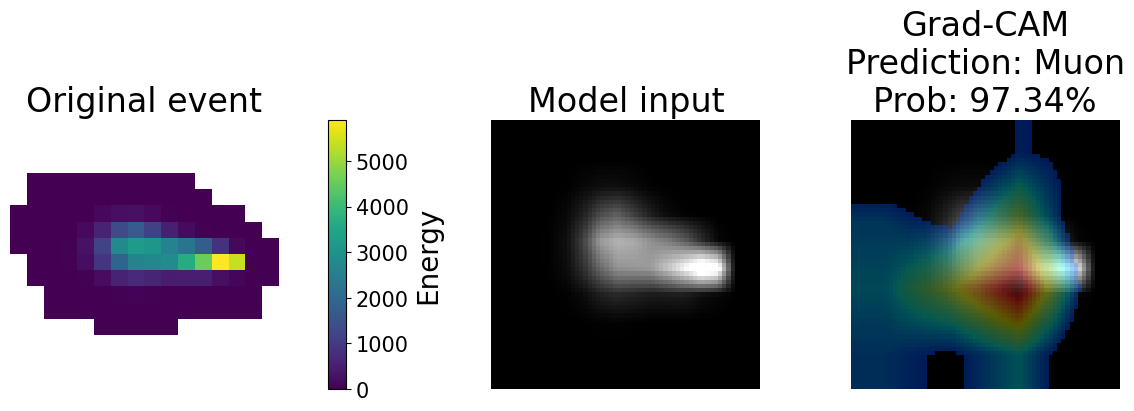


CORRECT (main figs): Others
min: 0.0 max: 1.0 std: 0.25098297


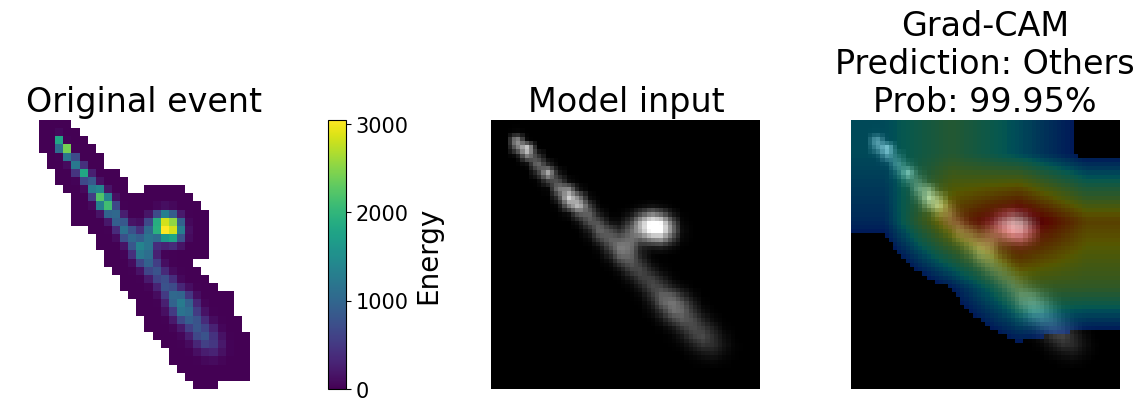

min: 0.0 max: 1.0 std: 0.24448839


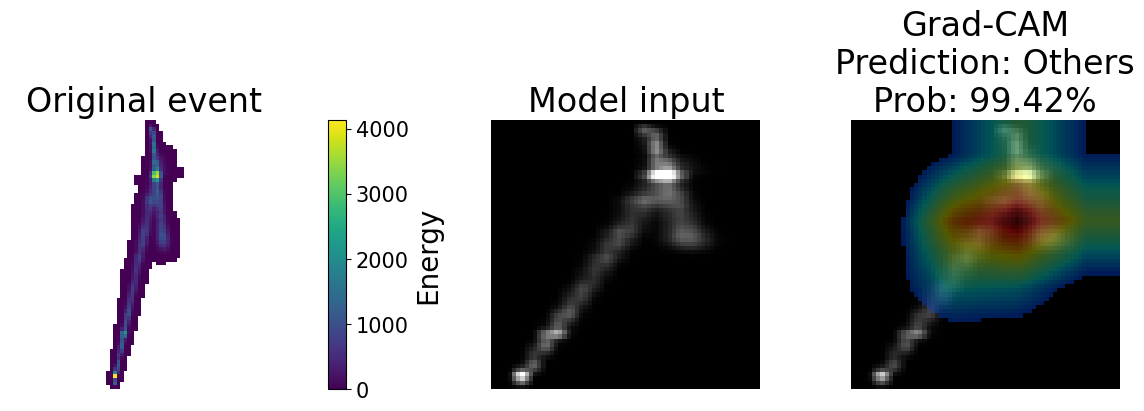

min: 0.0 max: 1.0 std: 0.3431288


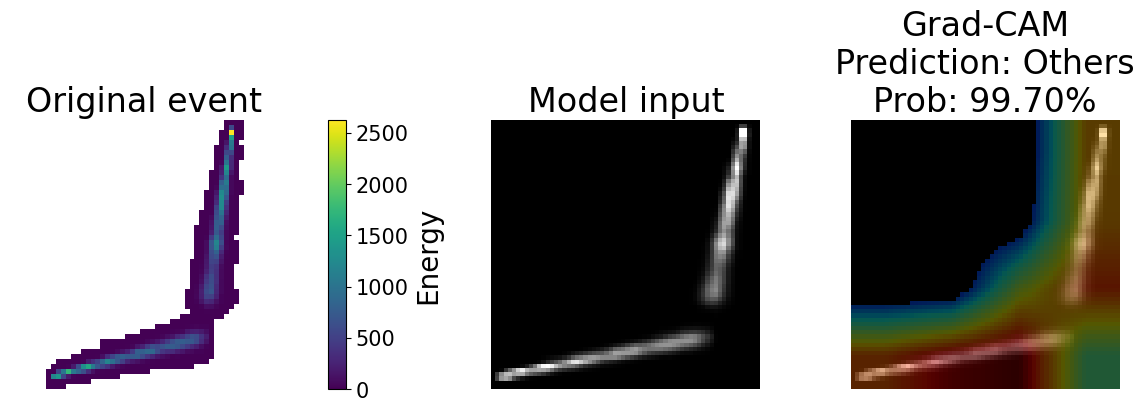

min: 0.0 max: 1.0 std: 0.24189693


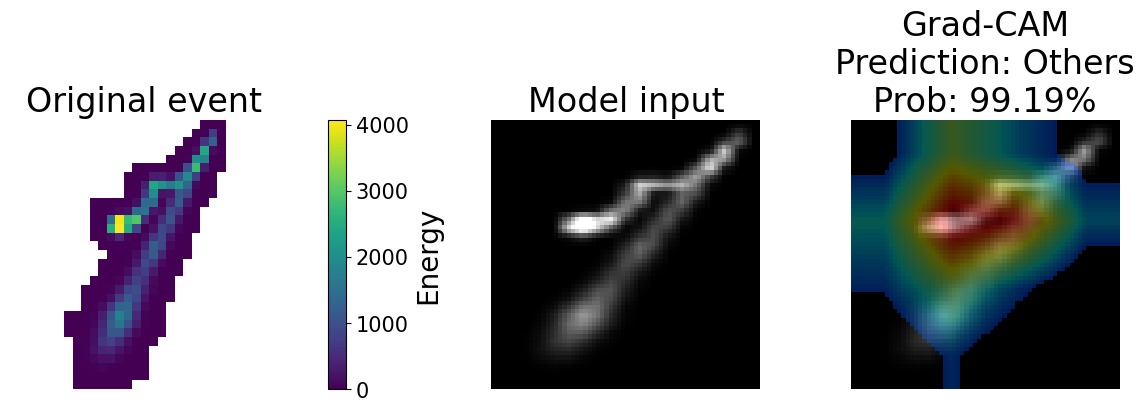

min: 0.0 max: 1.0 std: 0.3156927


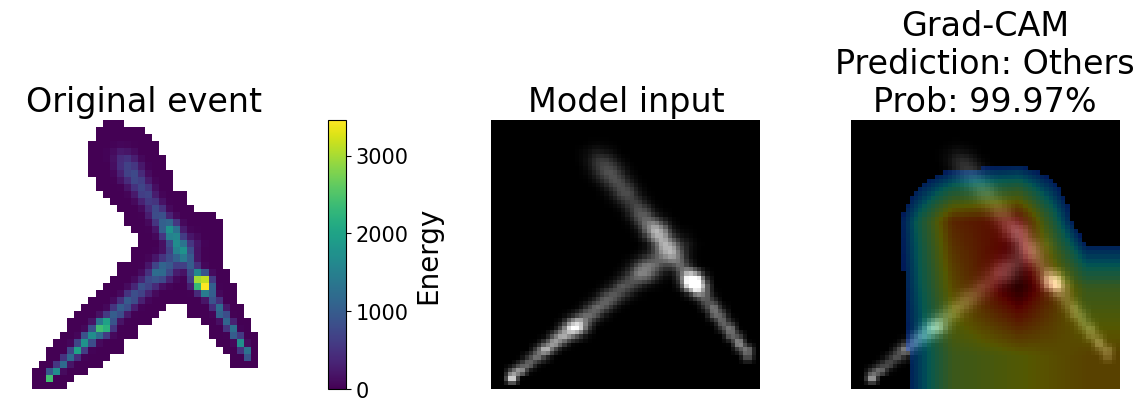

min: 0.0 max: 1.0 std: 0.23099883


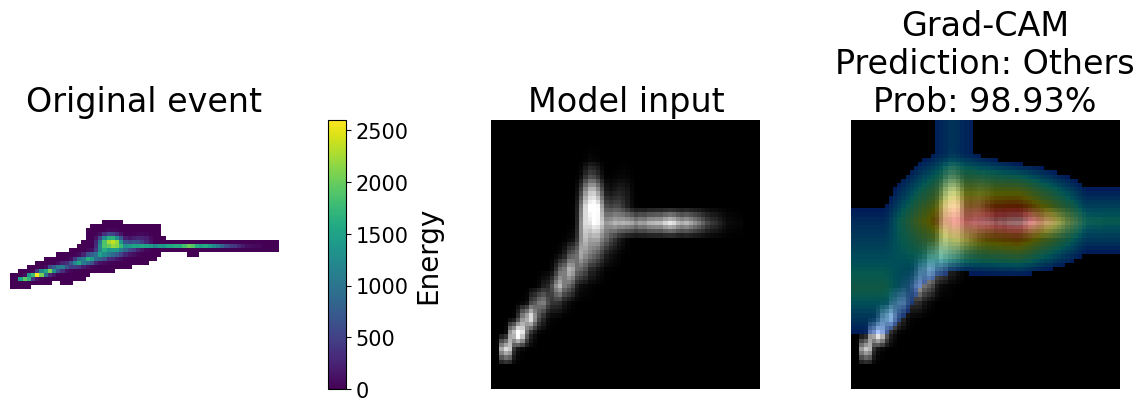

min: 0.0 max: 1.0 std: 0.18751808


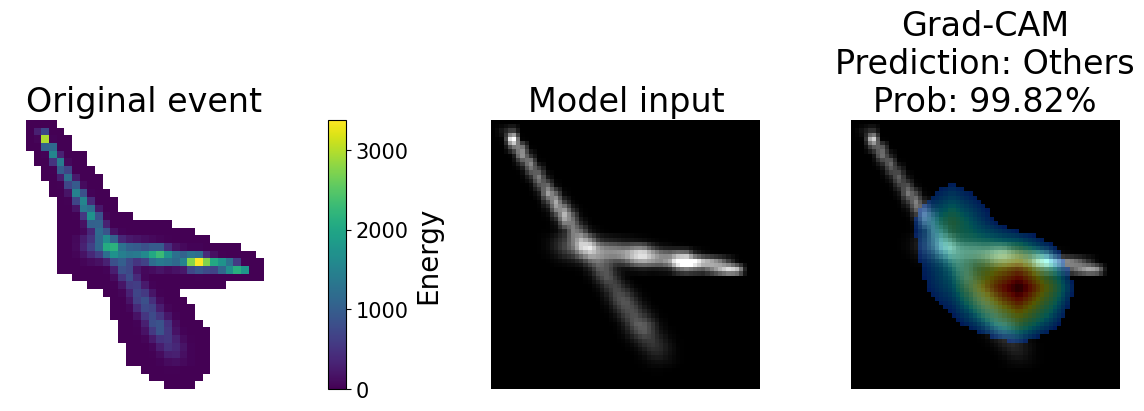

min: 0.0 max: 1.0 std: 0.3260051


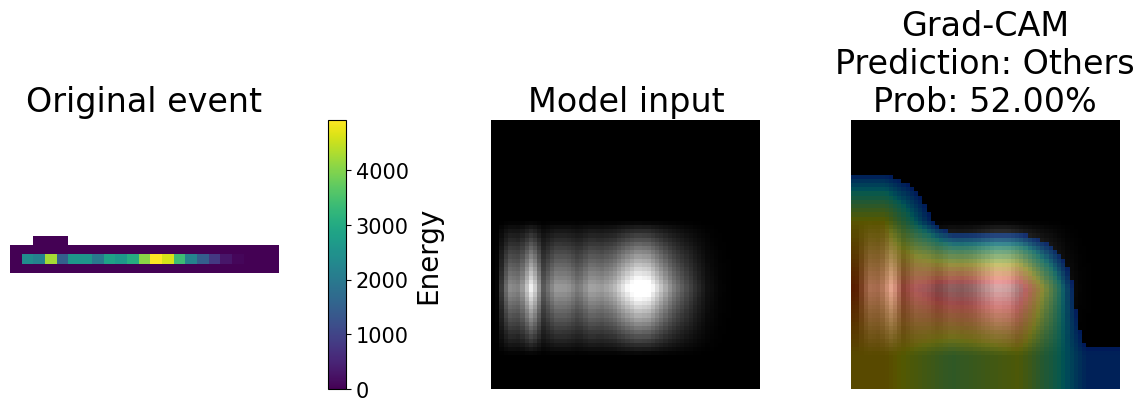

min: 0.0 max: 1.0 std: 0.22861591


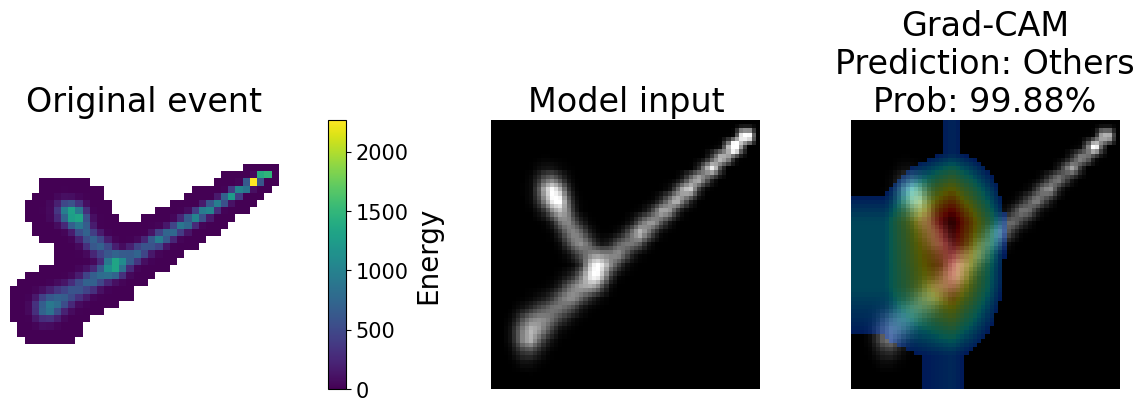

min: 0.0 max: 1.0 std: 0.30438533


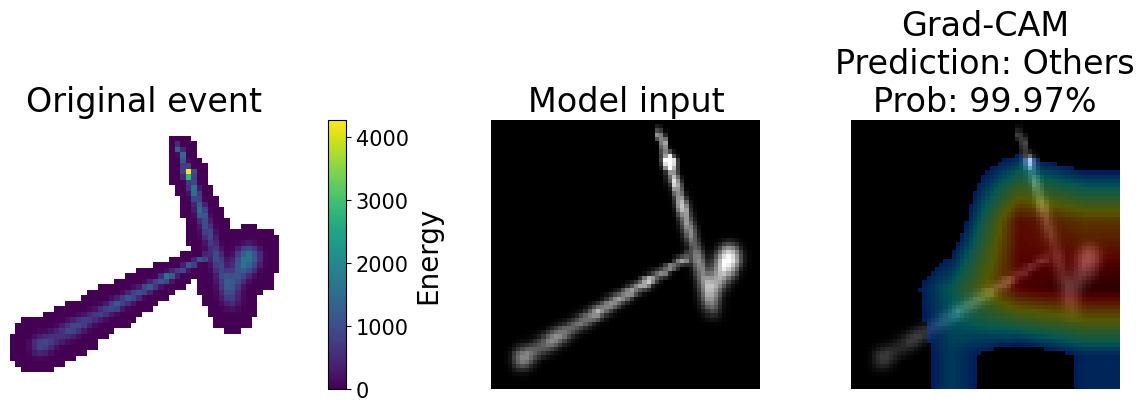

min: 0.0 max: 1.0 std: 0.2224429


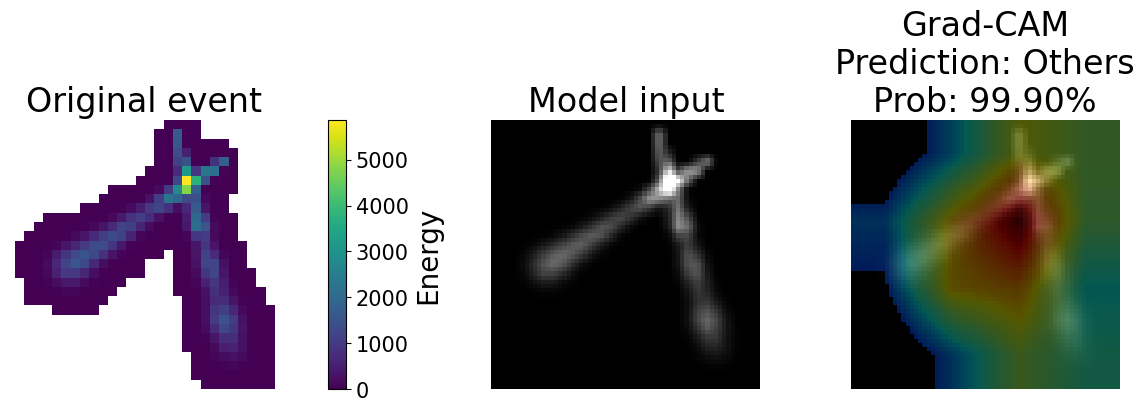

min: 0.0 max: 1.0 std: 0.32615173


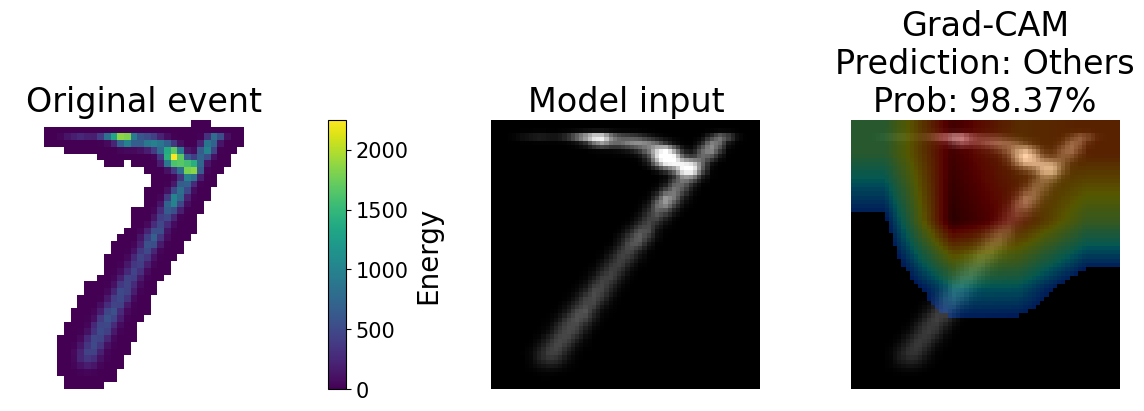

min: 0.0 max: 1.0 std: 0.22084984


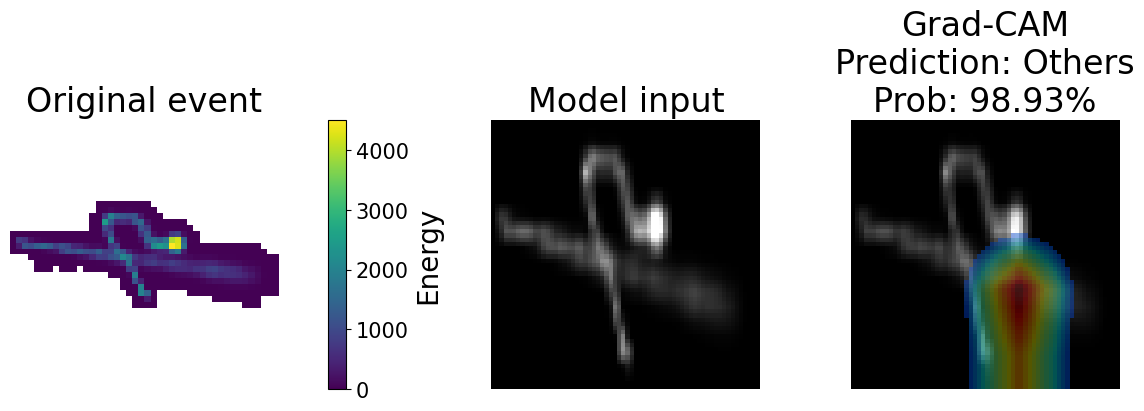

min: 0.0 max: 1.0 std: 0.26995242


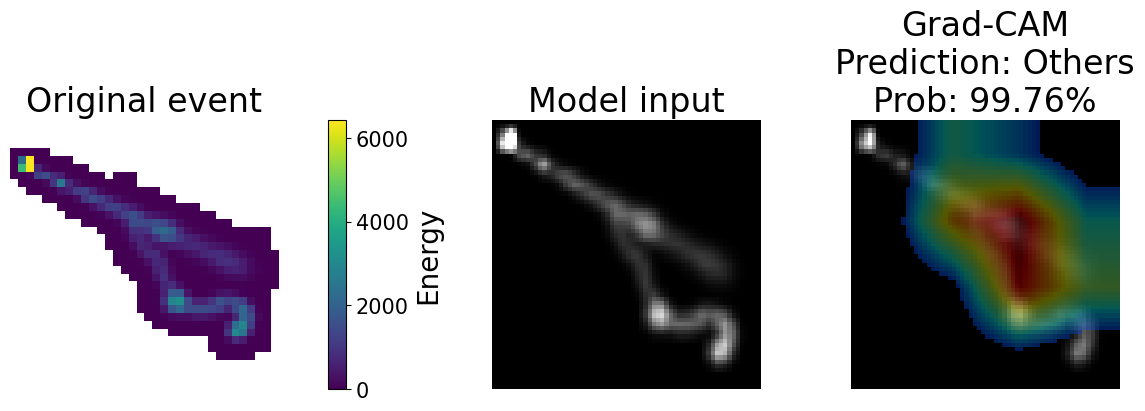

min: 0.0 max: 1.0 std: 0.2808175


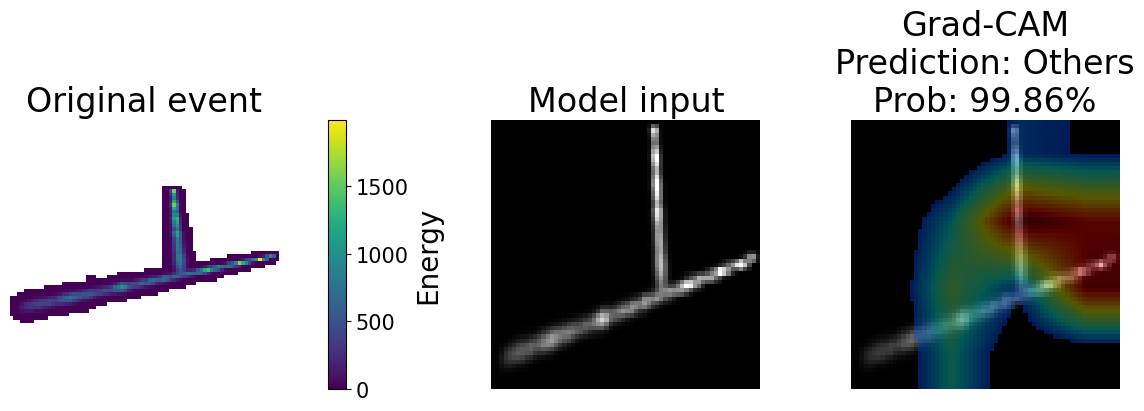

min: 0.0 max: 1.0 std: 0.36142522


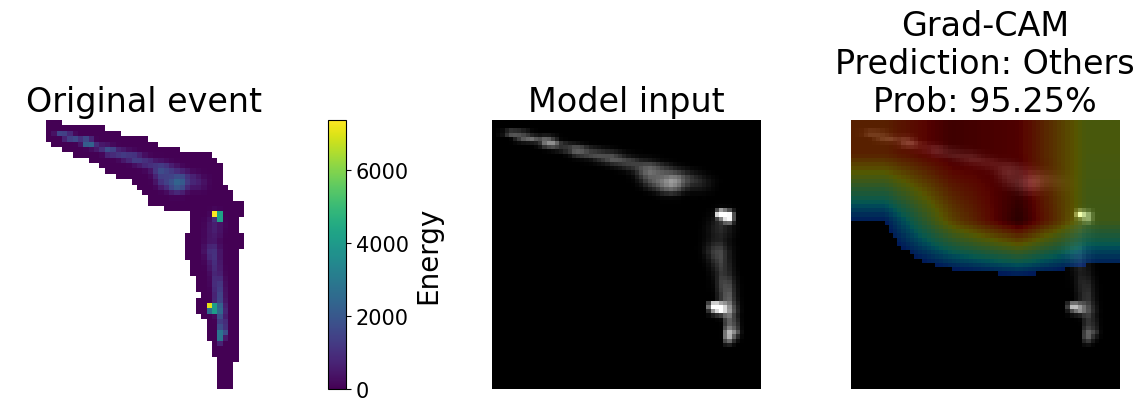

min: 0.0 max: 1.0 std: 0.24266678


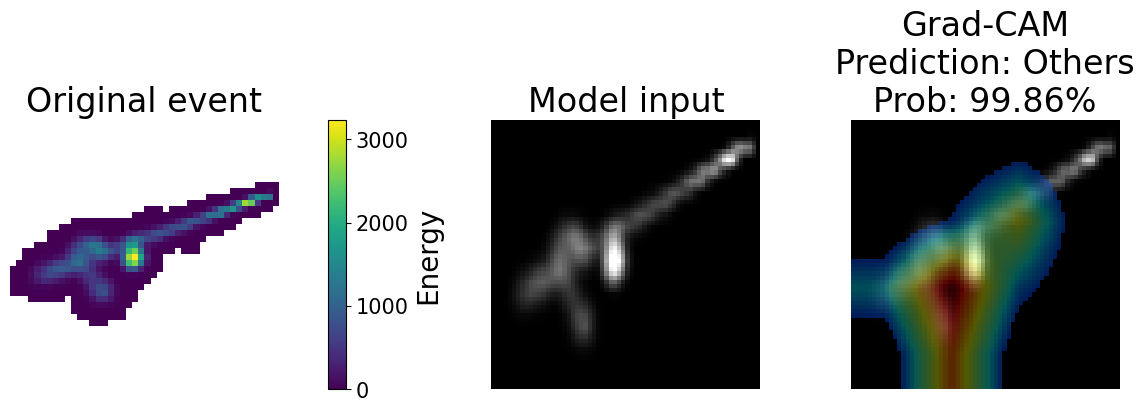

min: 0.0 max: 1.0 std: 0.26510897


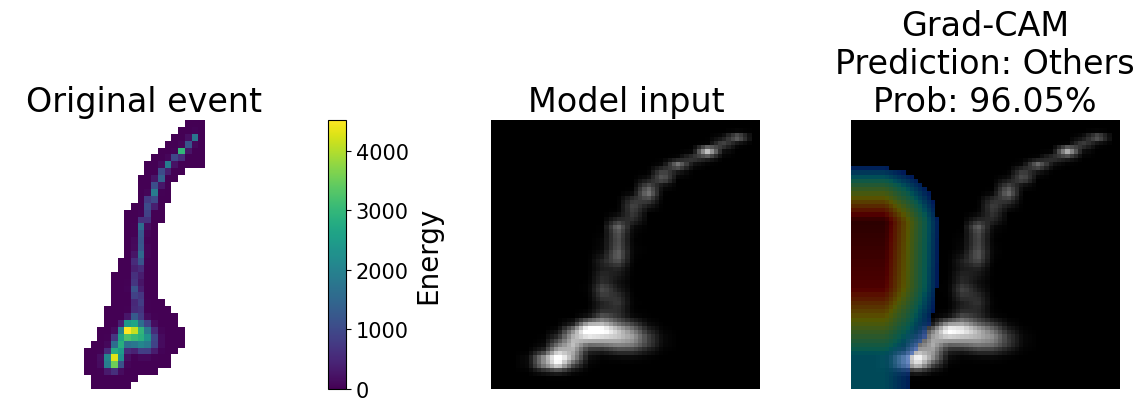

min: 0.0 max: 1.0 std: 0.1761114


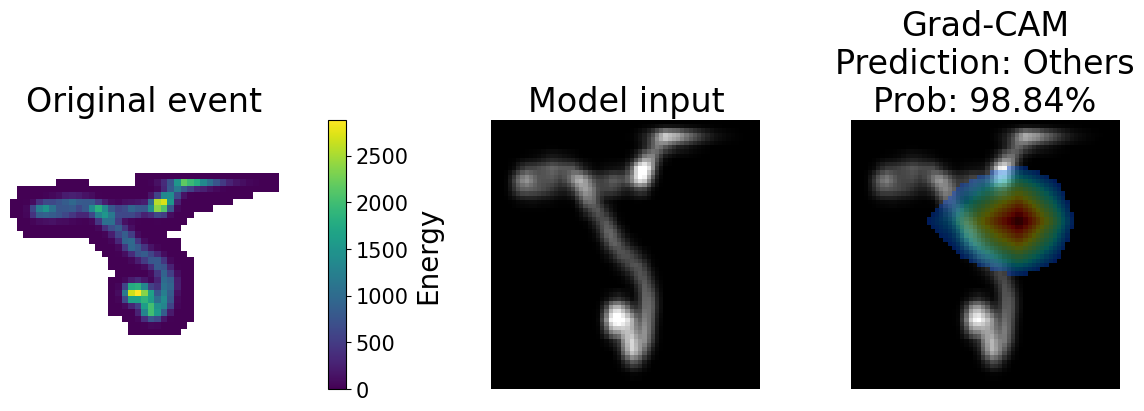

min: 0.0 max: 1.0 std: 0.29999086


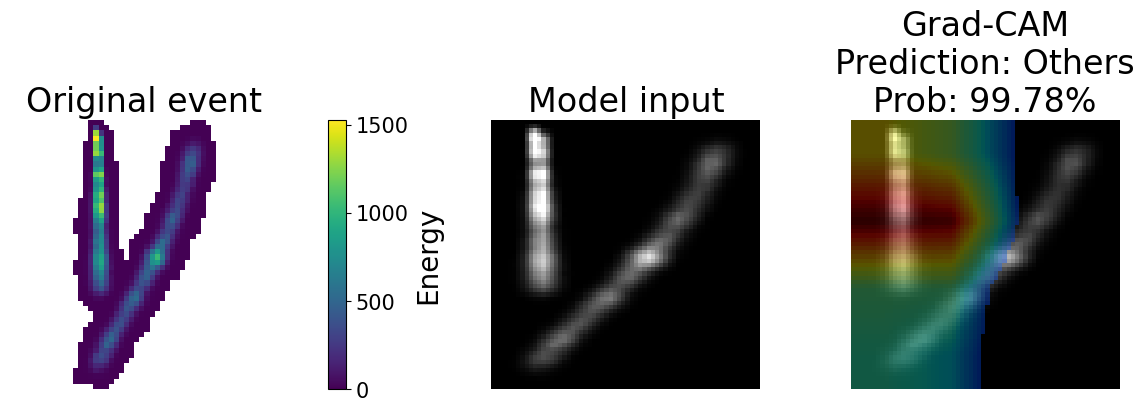

In [39]:
for class_name in class_names:
    print("\n===============================")
    print(f"CORRECT (main figs): {class_name}")
    print("===============================")
    for idx in correct_samples[class_name]:
        plot_correct_main_figure(idx)


FAILURES (main figs): Blob
min: 0.0 max: 1.0 std: 0.28946936
min: 0.0 max: 1.0 std: 0.29925472


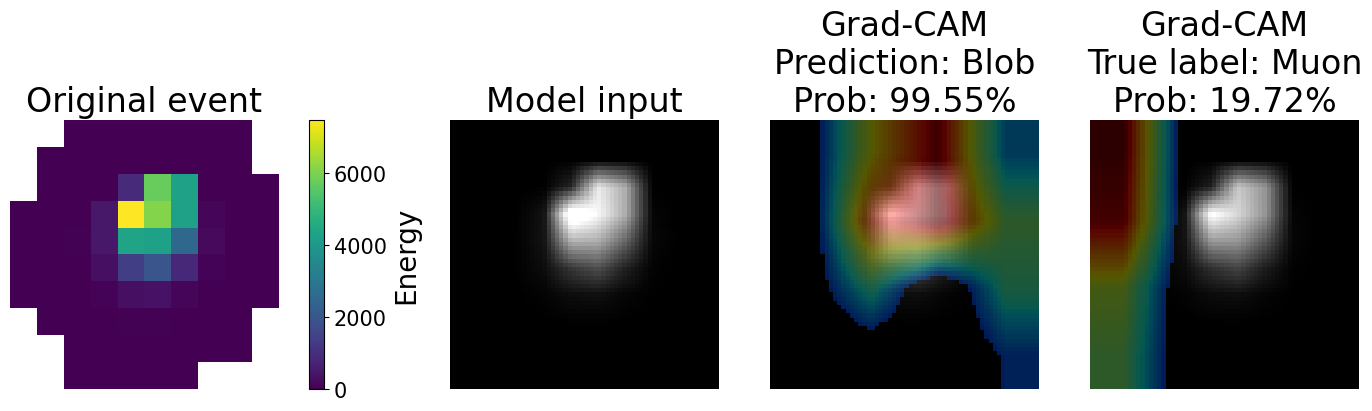

min: 0.0 max: 1.0 std: 0.2443977
min: 0.0 max: 1.0 std: 0.21898995


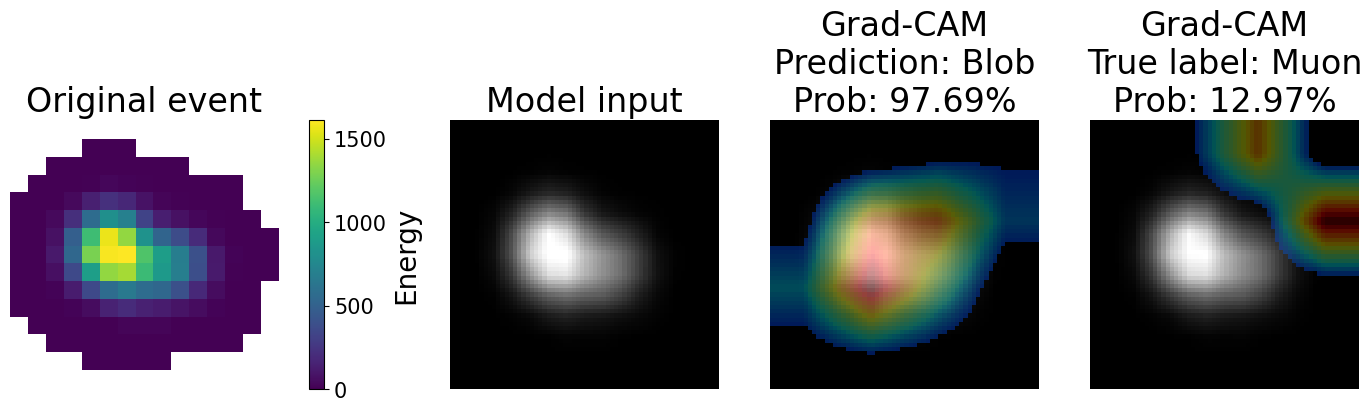

min: 0.0 max: 1.0 std: 0.2537911
min: 0.0 max: 1.0 std: 0.2523607


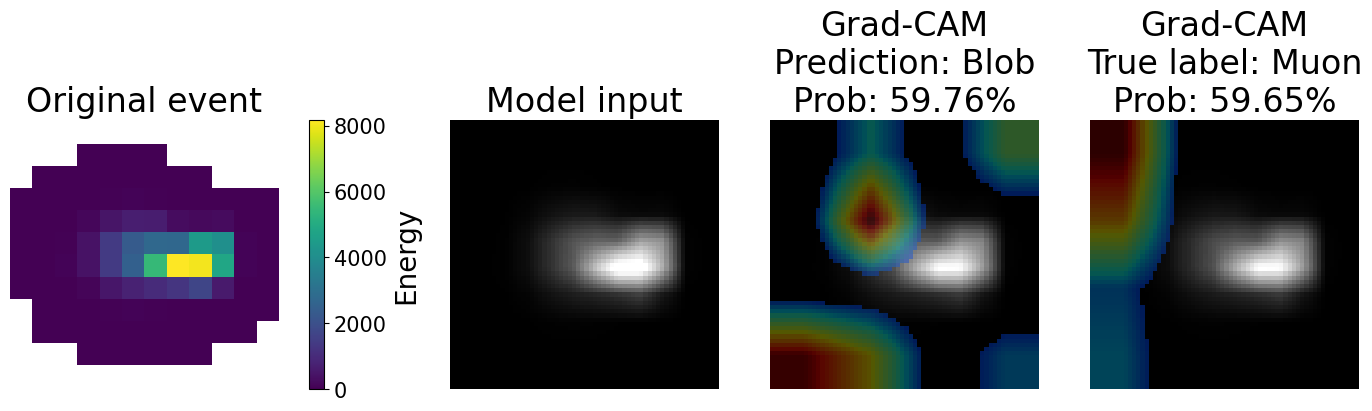

min: 0.0 max: 1.0 std: 0.22861964
min: 0.0 max: 1.0 std: 0.23826051


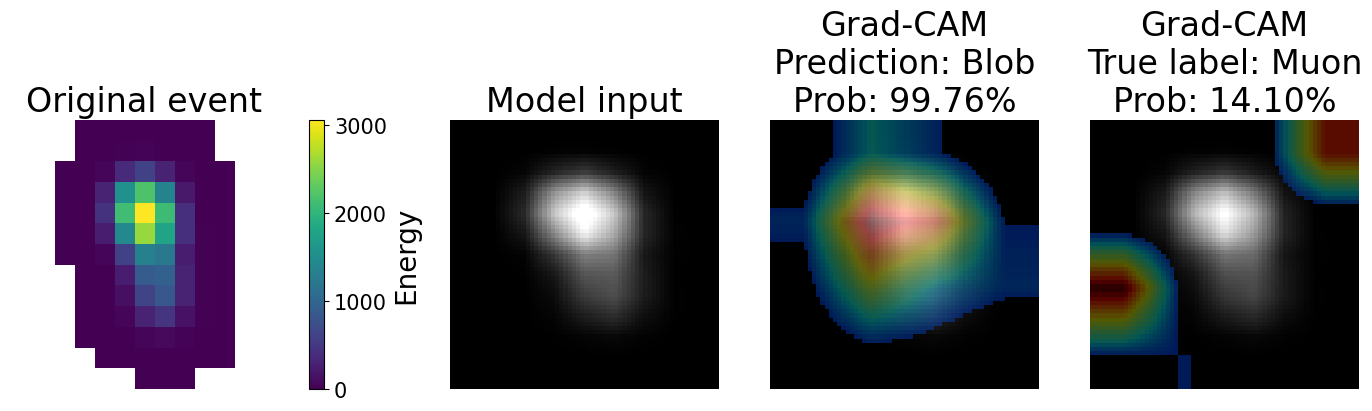

min: 0.0 max: 1.0 std: 0.22905701
min: 0.0 max: 1.0 std: 0.2169256


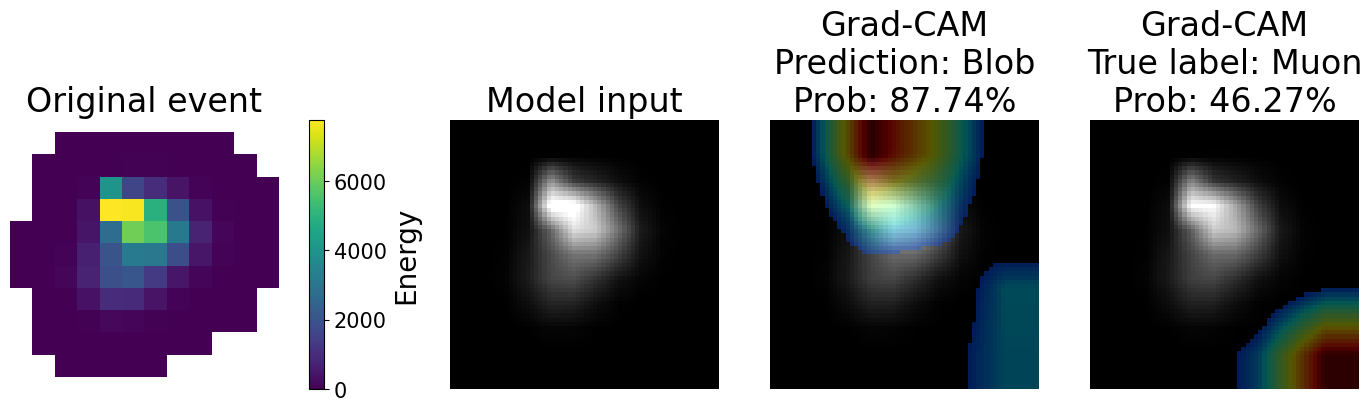

min: 0.0 max: 1.0 std: 0.25448257
min: 0.0 max: 1.0 std: 0.2477146


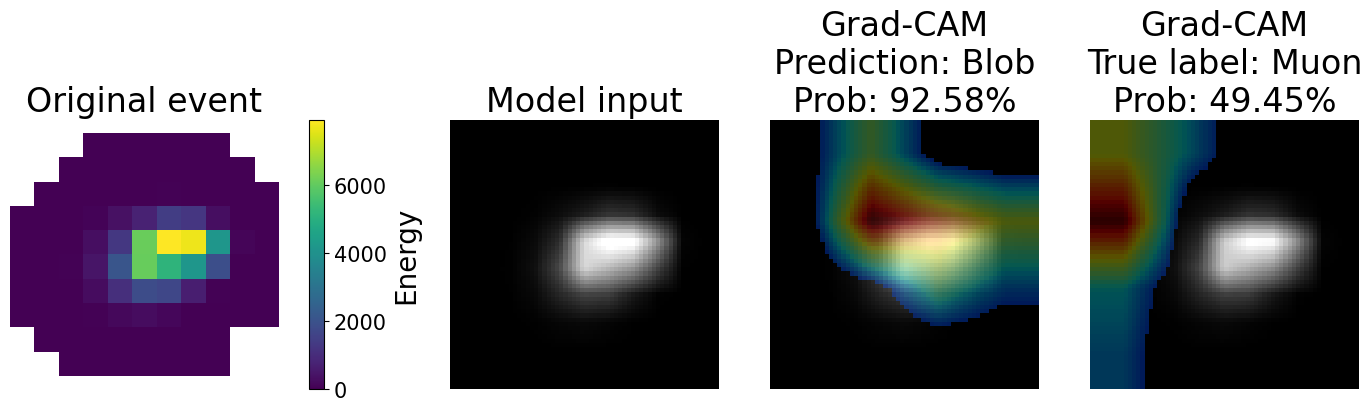

min: 0.0 max: 1.0 std: 0.23062438
min: 0.0 max: 1.0 std: 0.20380294


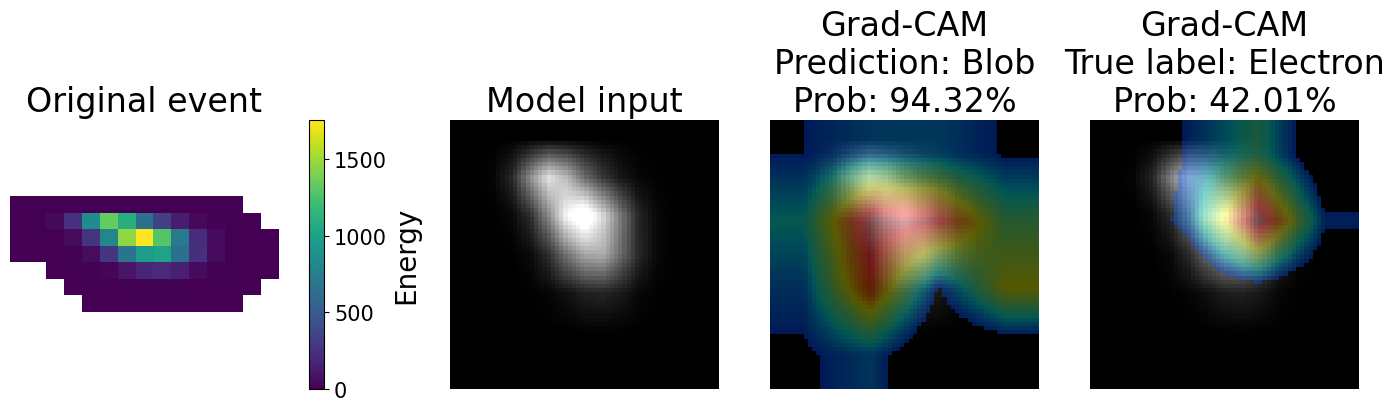

min: 0.0 max: 1.0 std: 0.21395737
min: 0.0 max: 1.0 std: 0.18144883


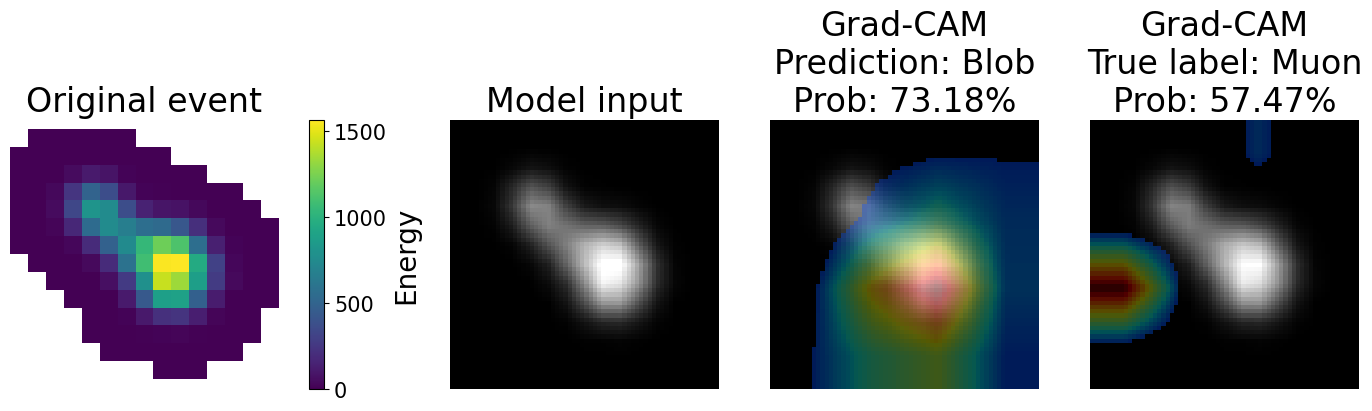

min: 0.0 max: 1.0 std: 0.2774911
min: 0.0 max: 1.0 std: 0.23175055


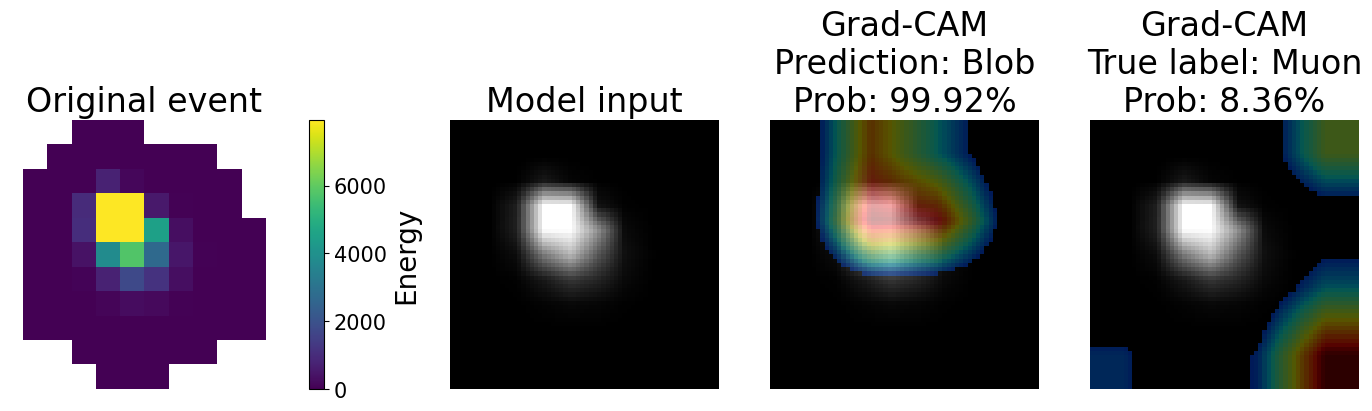

min: 0.0 max: 1.0 std: 0.3070065
min: 0.0 max: 1.0 std: 0.23713665


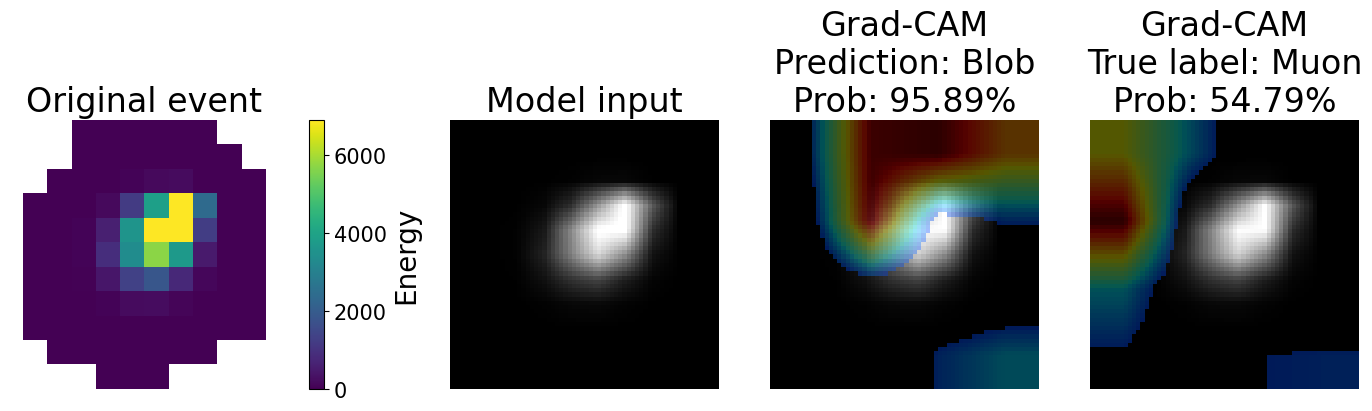

min: 0.0 max: 1.0 std: 0.17441772
min: 0.0 max: 1.0 std: 0.18106793


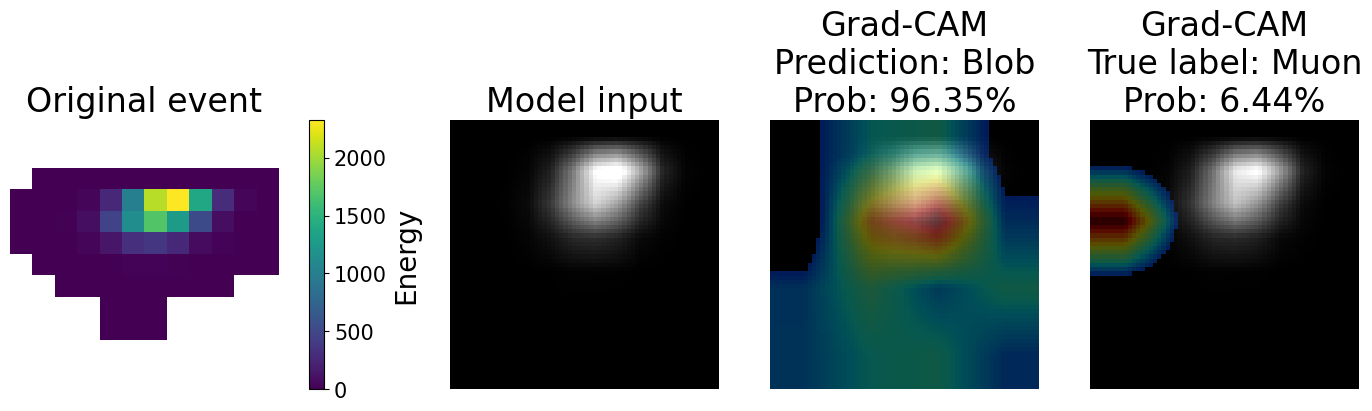

min: 0.0 max: 1.0 std: 0.24154161
min: 0.0 max: 1.0 std: 0.2858996


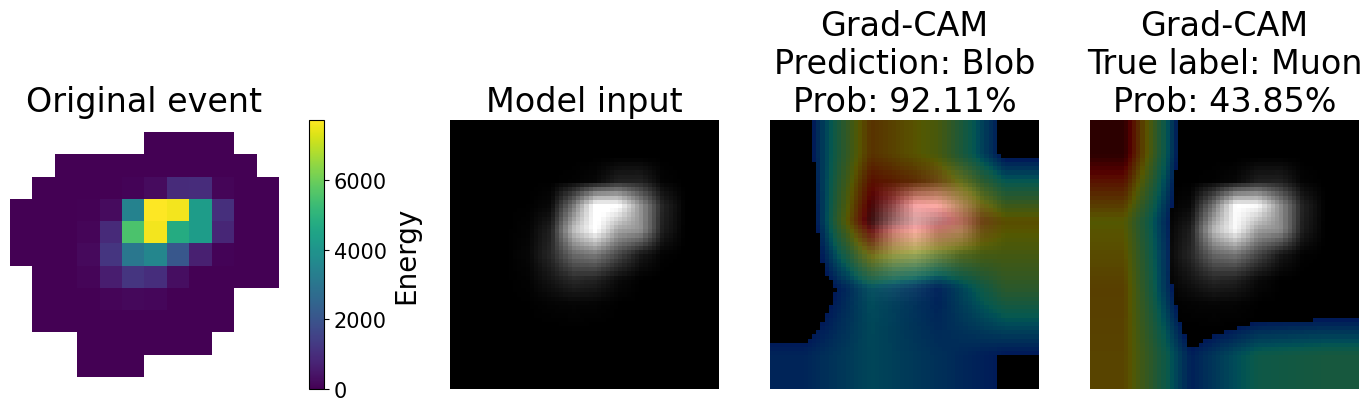

min: 0.0 max: 1.0 std: 0.25141653
min: 0.0 max: 1.0 std: 0.2100836


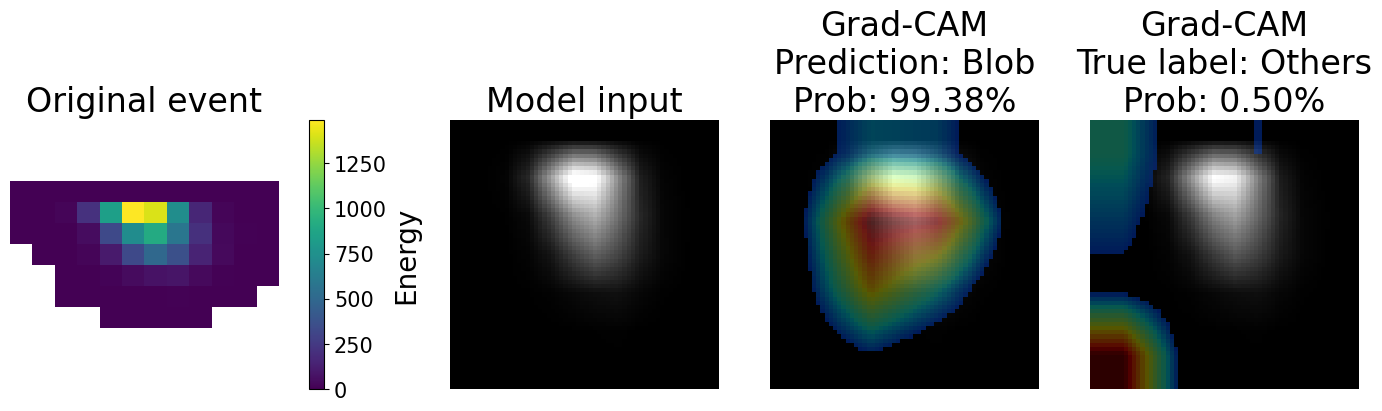


FAILURES (main figs): Diffusion Hit
min: 0.0 max: 1.0 std: 0.25678566
min: 0.0 max: 1.0 std: 0.21554983


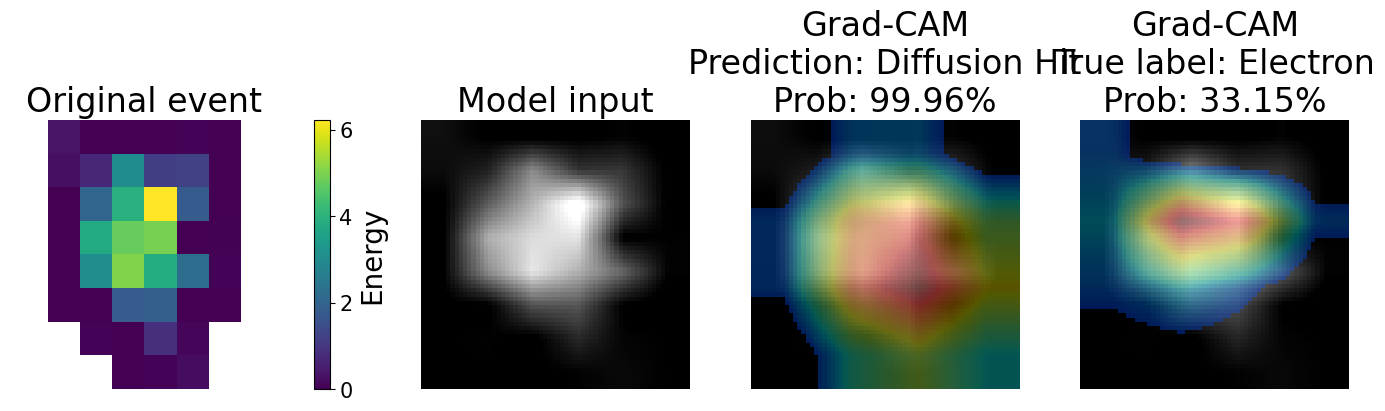

min: 0.0 max: 1.0 std: 0.25760624
min: 0.0 max: 1.0 std: 0.26240835


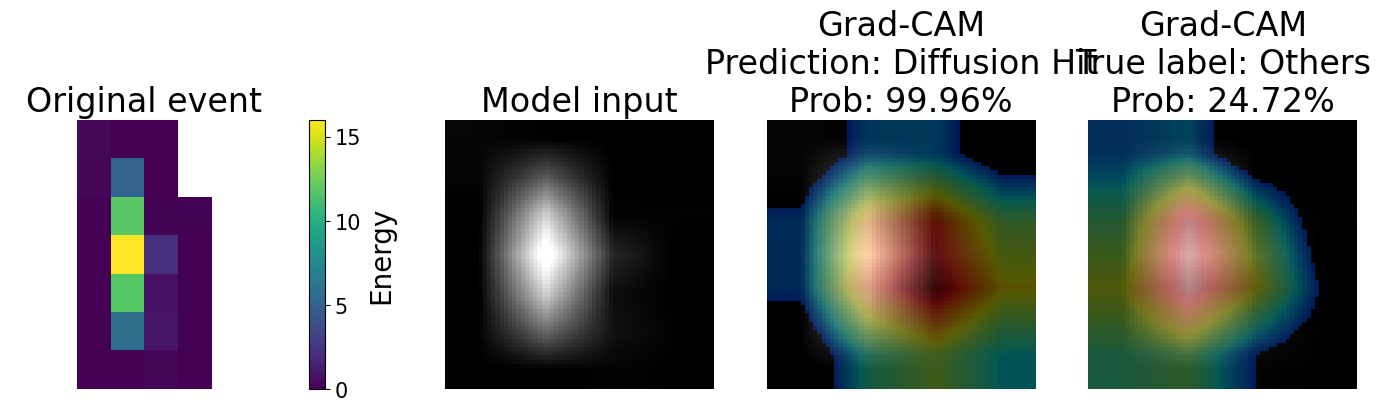


FAILURES (main figs): Electron
min: 0.0 max: 1.0 std: 0.2168602
min: 0.0 max: 1.0 std: 0.25919765


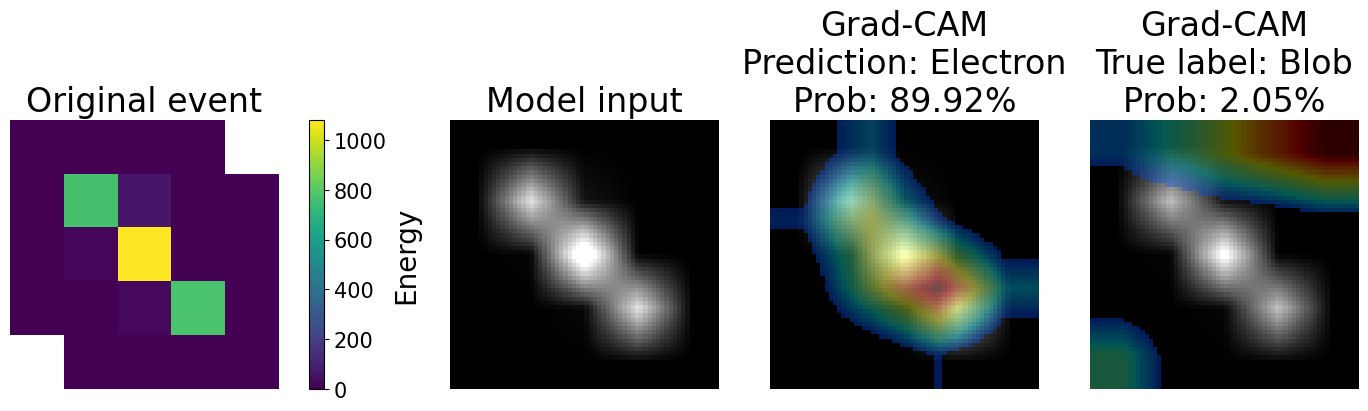

min: 0.0 max: 1.0 std: 0.24170603
min: 0.0 max: 1.0 std: 0.32770514


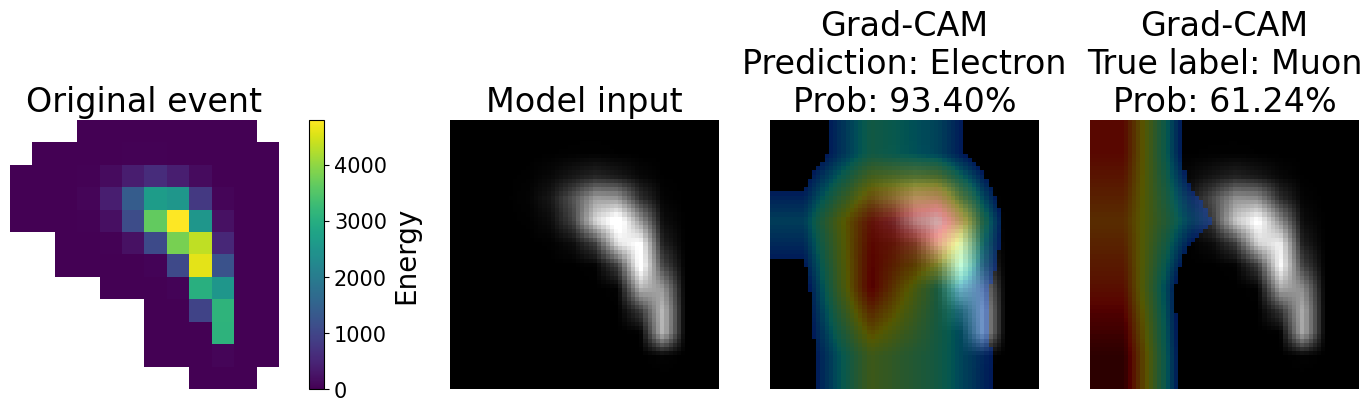

min: 0.0 max: 1.0 std: 0.21588656
min: 0.0 max: 1.0 std: 0.26373243


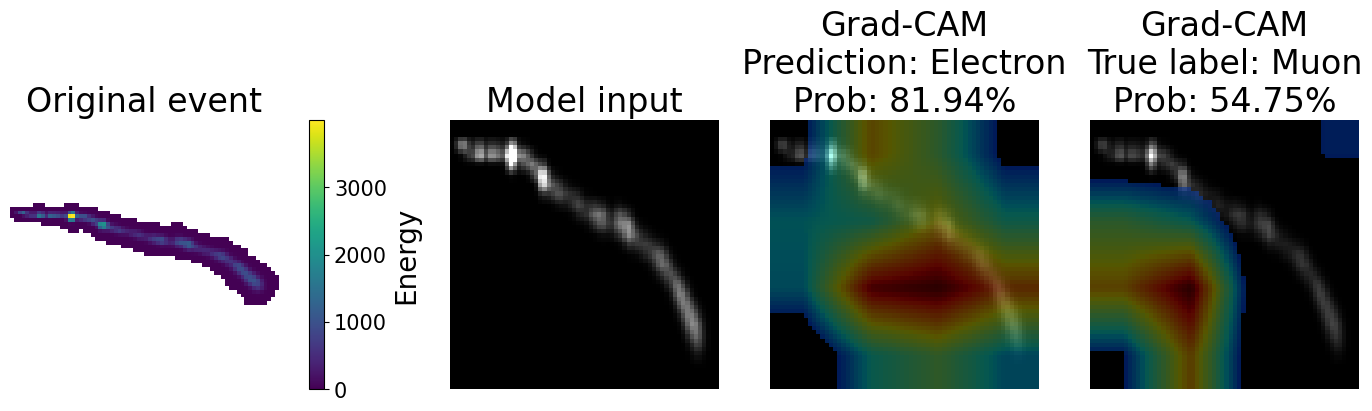

min: 0.0 max: 1.0 std: 0.22280227
min: 0.0 max: 0.0 std: 0.0


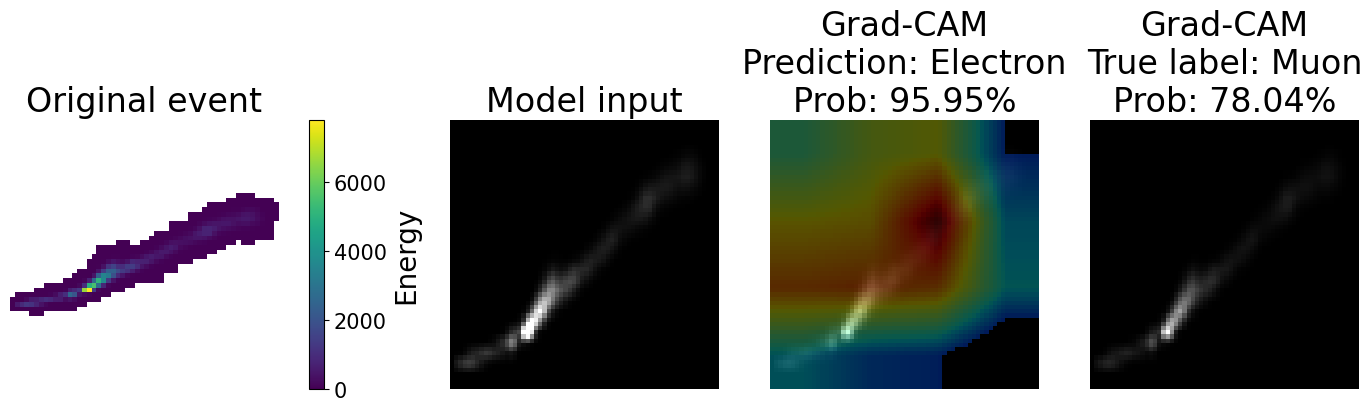

min: 0.0 max: 1.0 std: 0.25672403
min: 0.0 max: 1.0 std: 0.23472248


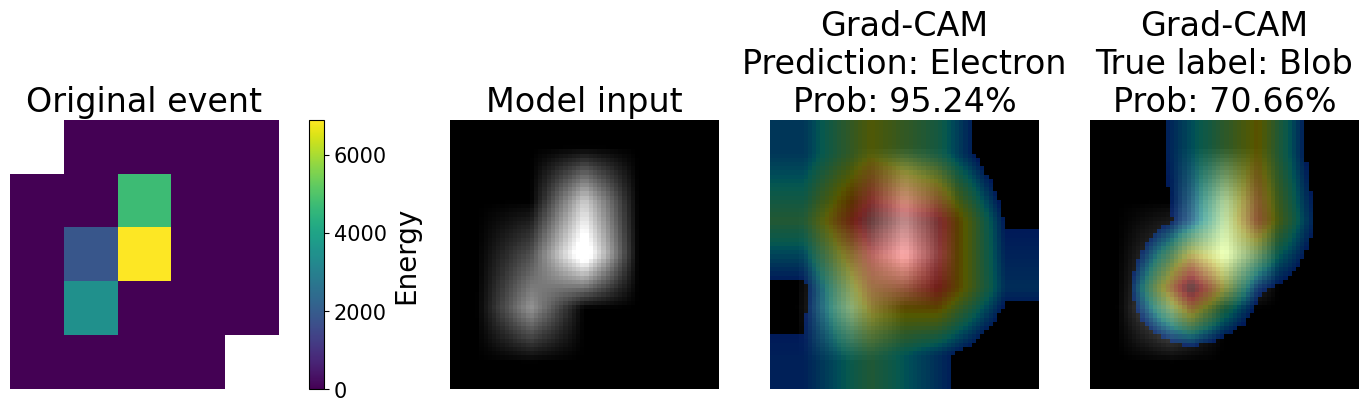

min: 0.0 max: 1.0 std: 0.28610992
min: 0.0 max: 1.0 std: 0.28417164


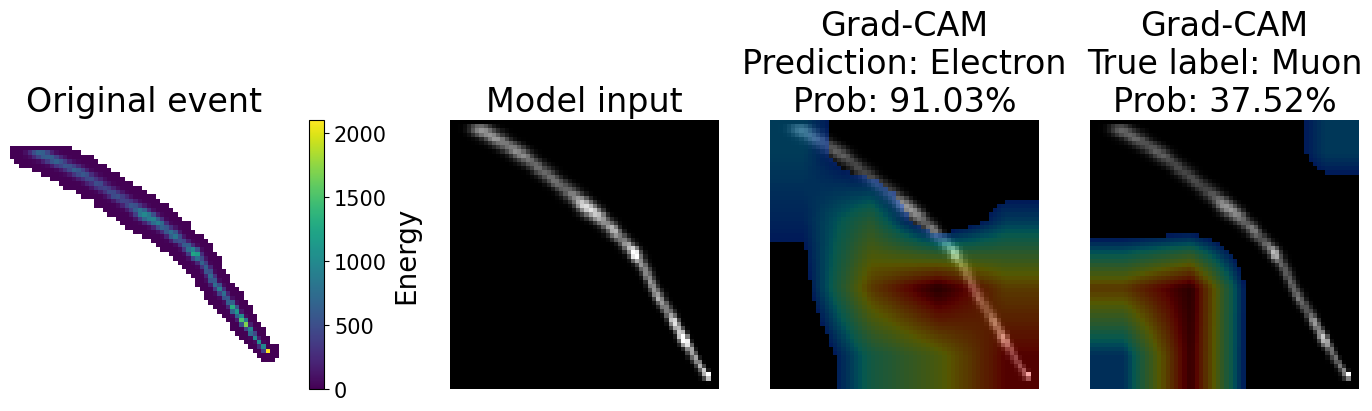

min: 0.0 max: 1.0 std: 0.26907432
min: 0.0 max: 1.0 std: 0.23146755


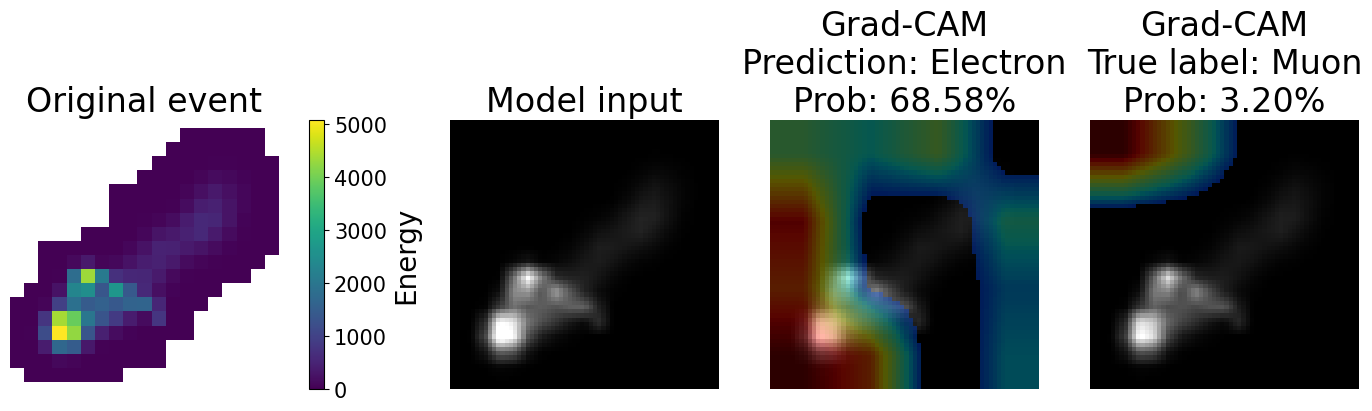

min: 0.0 max: 1.0 std: 0.23026684
min: 0.0 max: 1.0 std: 0.18106791


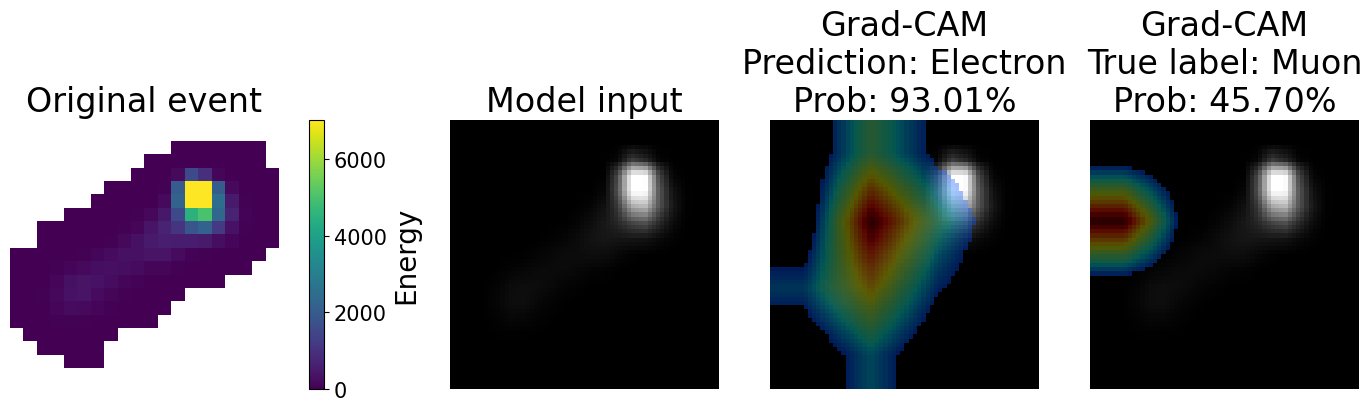

min: 0.0 max: 1.0 std: 0.24984807
min: 0.0 max: 1.0 std: 0.26584923


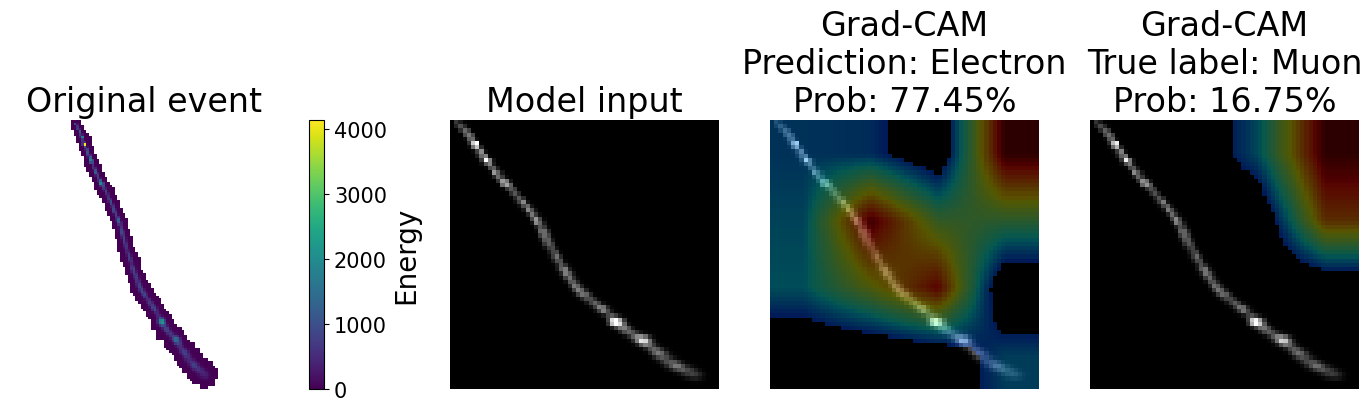

min: 0.0 max: 1.0 std: 0.20885837
min: 0.0 max: 1.0 std: 0.28636107


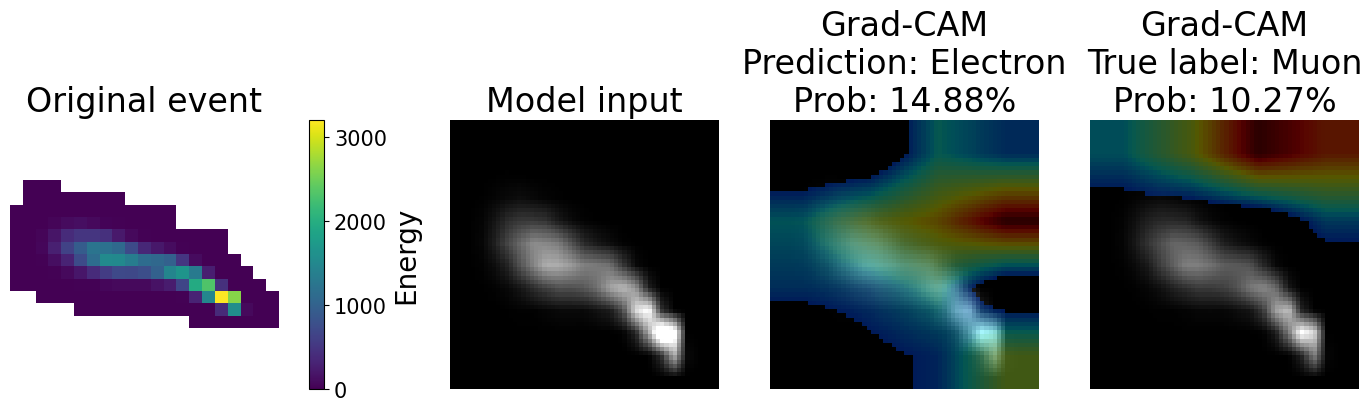

min: 0.0 max: 1.0 std: 0.2980357
min: 0.0 max: 1.0 std: 0.28716817


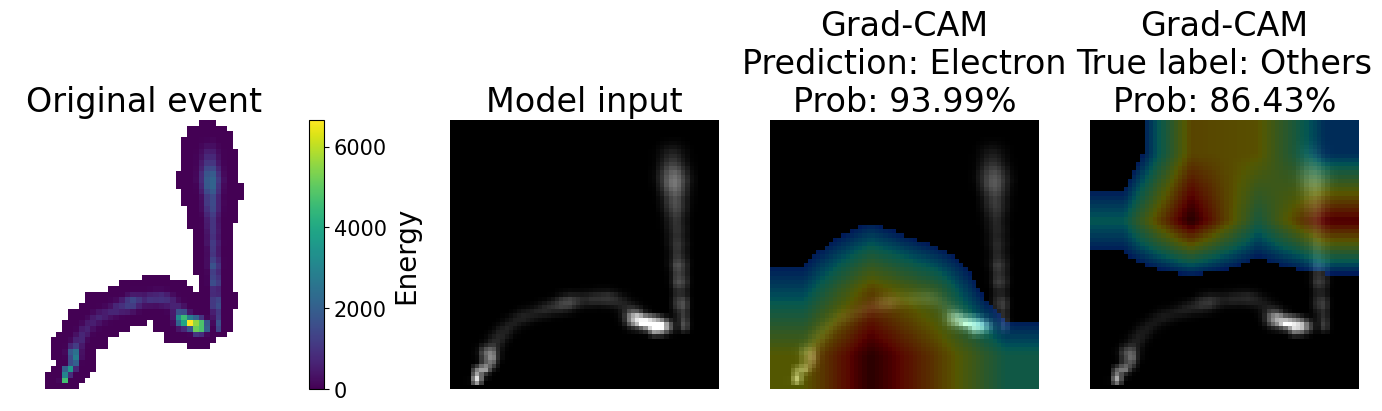

min: 0.0 max: 1.0 std: 0.33251068
min: 0.0 max: 1.0 std: 0.2154414


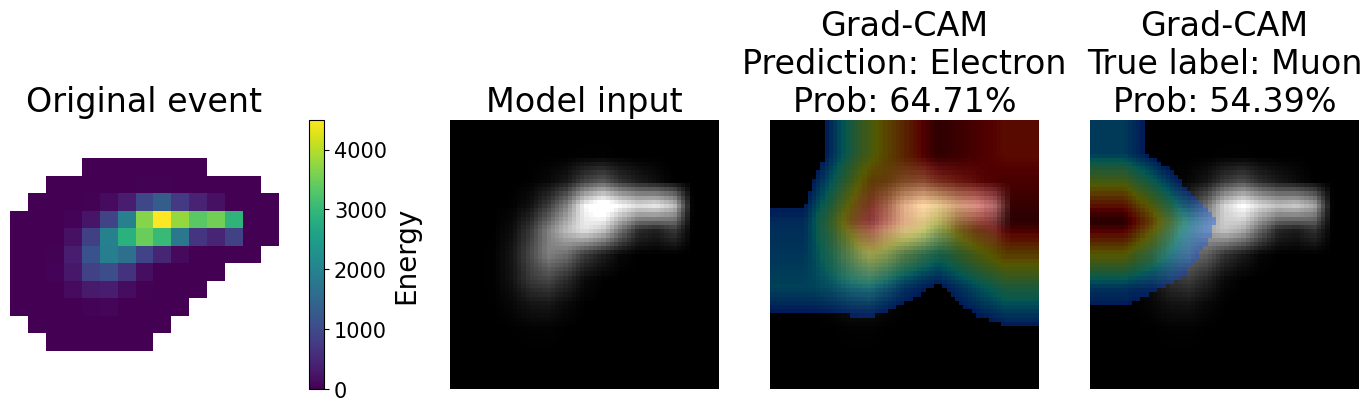


FAILURES (main figs): Muon
min: 0.0 max: 1.0 std: 0.33224732
min: 0.0 max: 1.0 std: 0.2249614


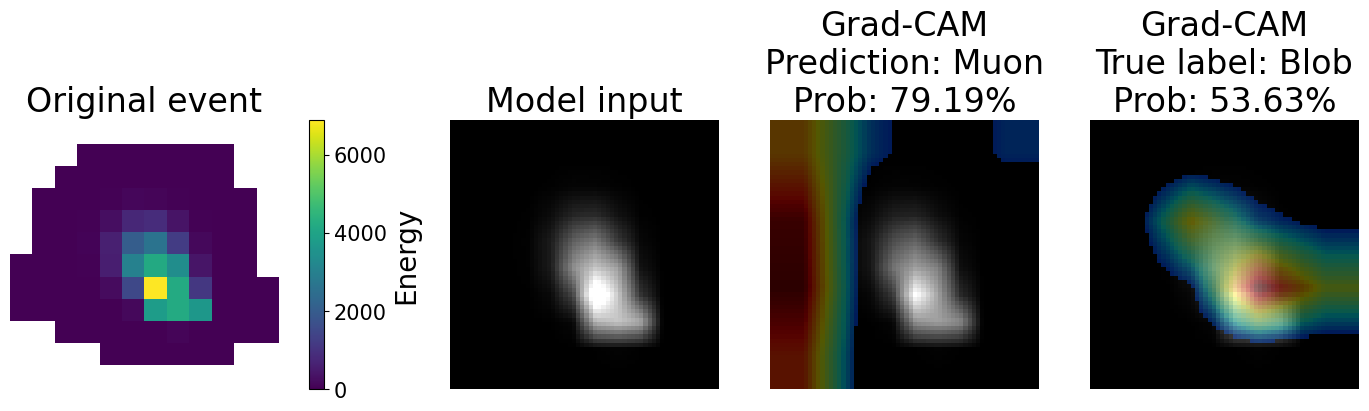

min: 0.0 max: 1.0 std: 0.23182705
min: 0.0 max: 1.0 std: 0.24650408


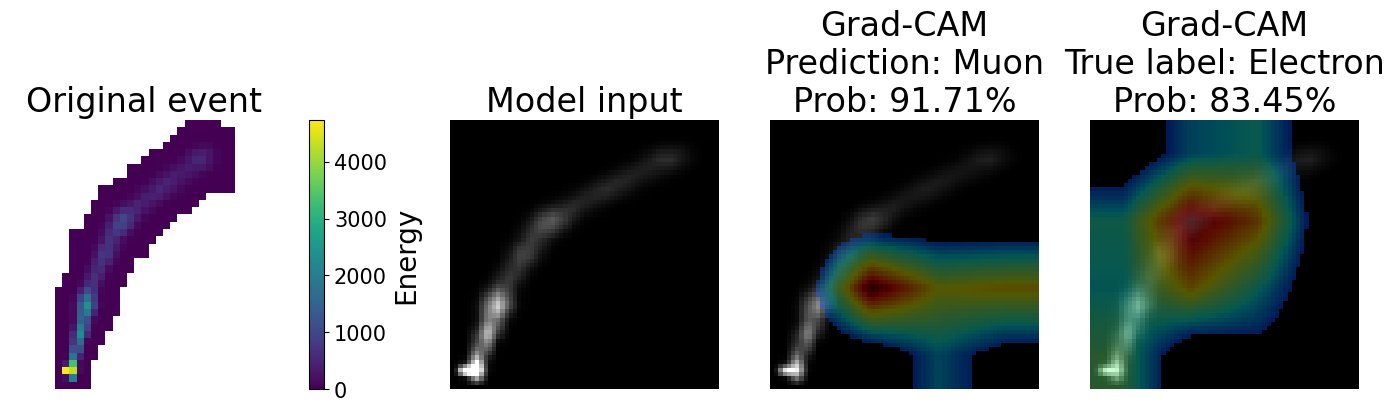

min: 0.0 max: 1.0 std: 0.27583066
min: 0.0 max: 1.0 std: 0.22552082


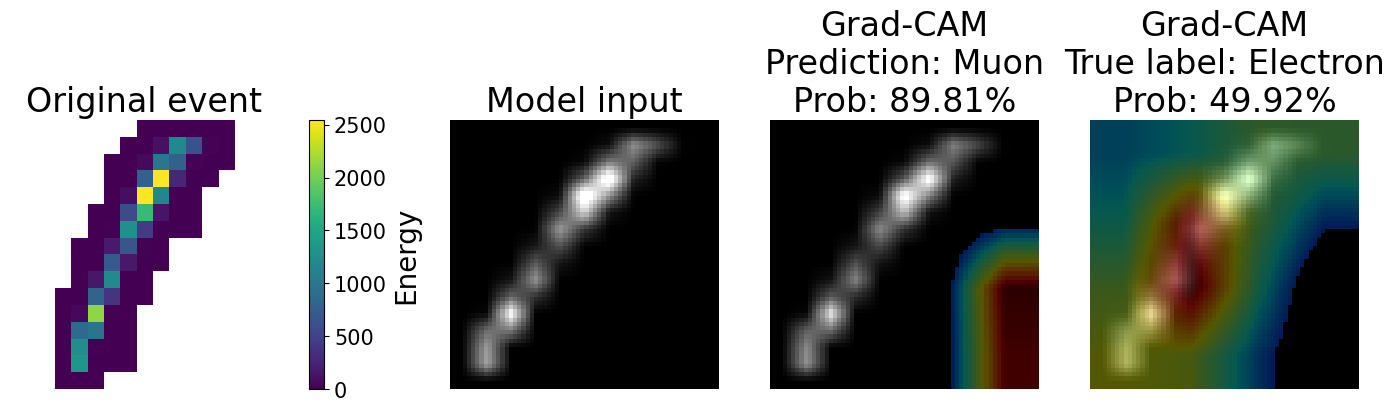

min: 0.0 max: 1.0 std: 0.2784033
min: 0.0 max: 1.0 std: 0.23165654


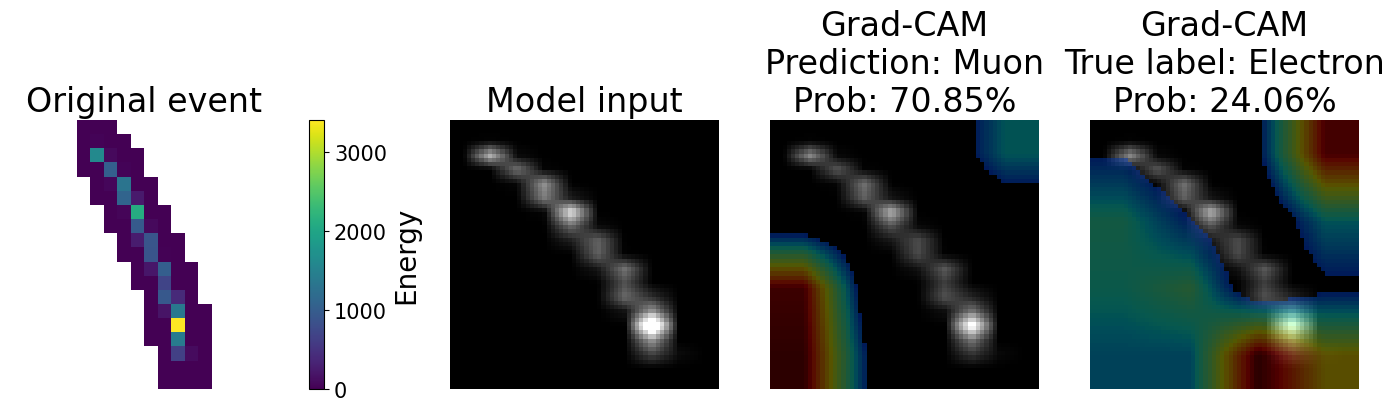

min: 0.0 max: 0.0 std: 0.0
min: 0.0 max: 1.0 std: 0.29678506


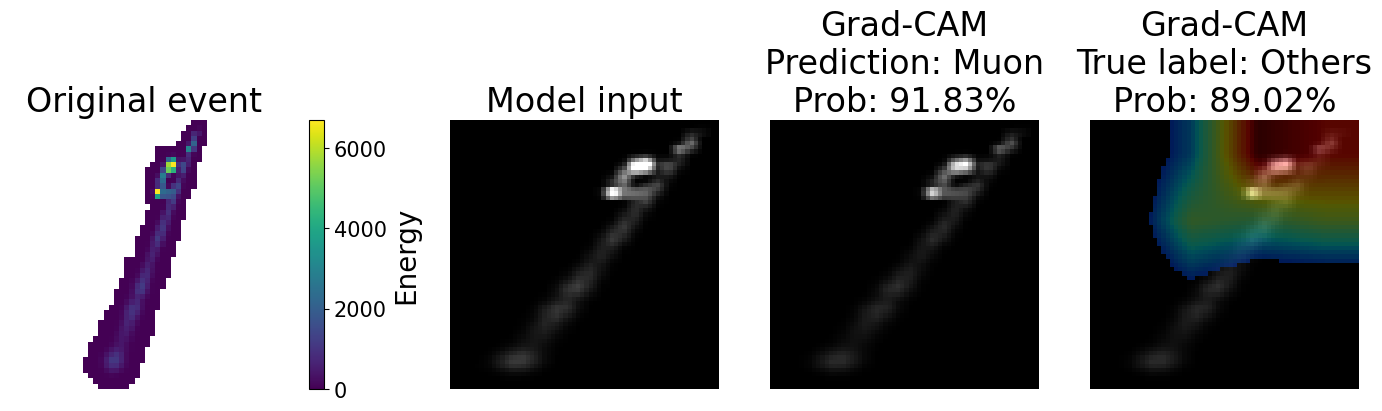


FAILURES (main figs): Others
min: 0.0 max: 1.0 std: 0.2955527
min: 0.0 max: 1.0 std: 0.3157706


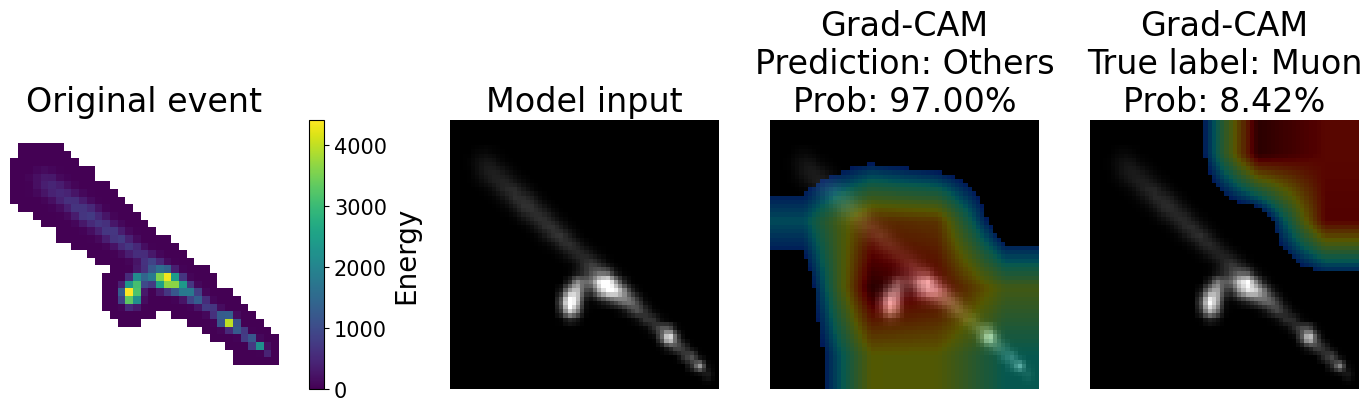

min: 0.0 max: 1.0 std: 0.2617613
min: 0.0 max: 1.0 std: 0.23363504


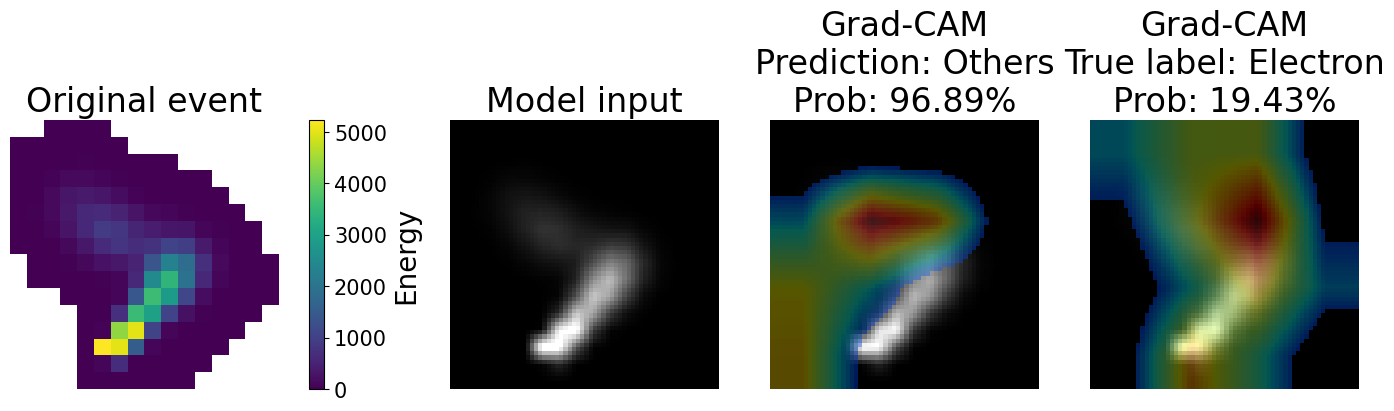

min: 0.0 max: 1.0 std: 0.27633998
min: 0.0 max: 1.0 std: 0.2498027


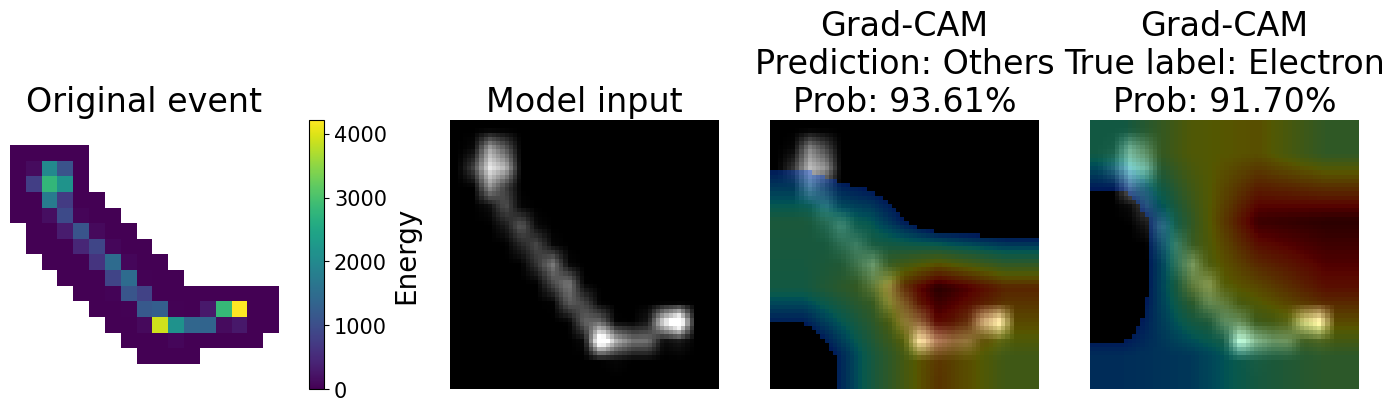

min: 0.0 max: 1.0 std: 0.24263029
min: 0.0 max: 1.0 std: 0.21758968


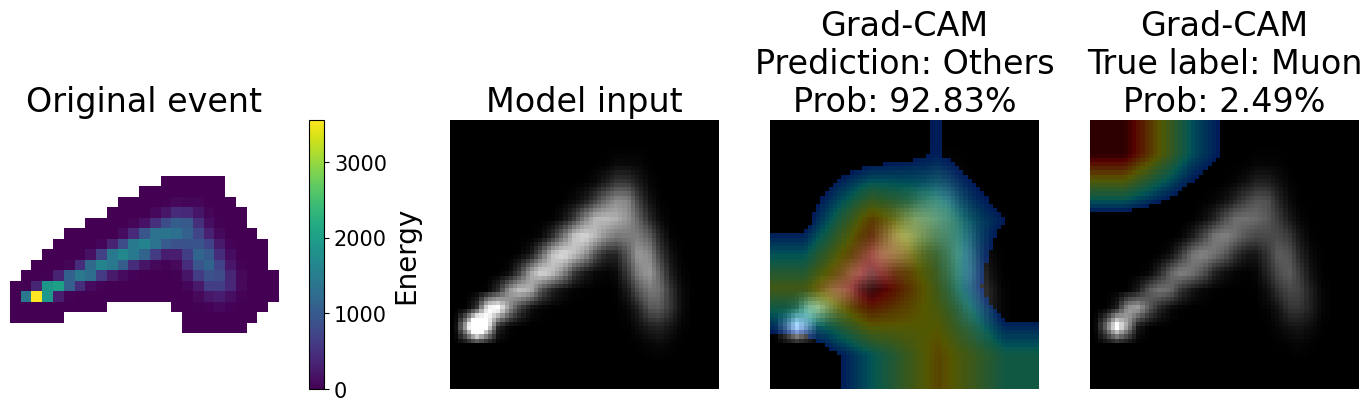

min: 0.0 max: 1.0 std: 0.266074
min: 0.0 max: 1.0 std: 0.26905784


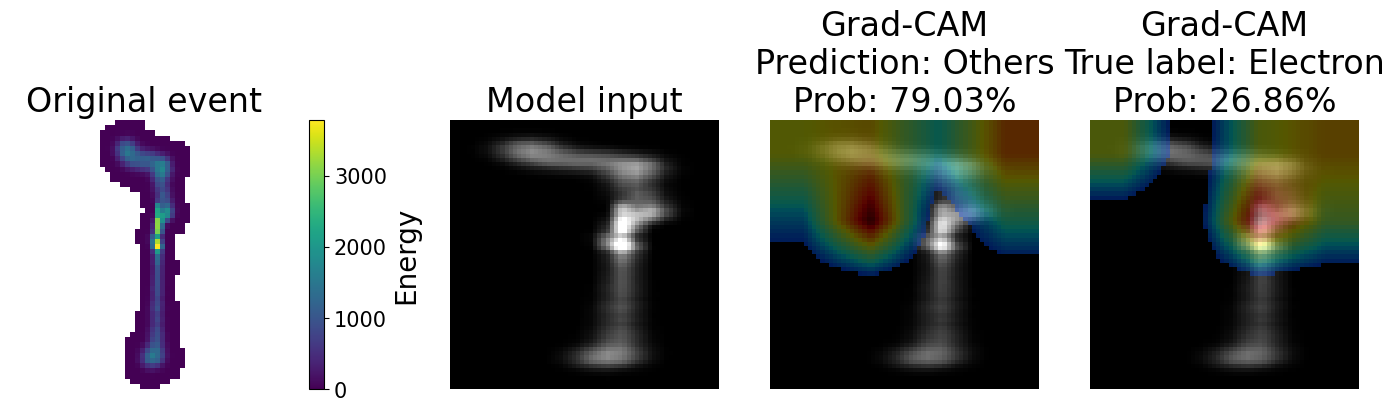

min: 0.0 max: 1.0 std: 0.2534551
min: 0.0 max: 1.0 std: 0.2886611


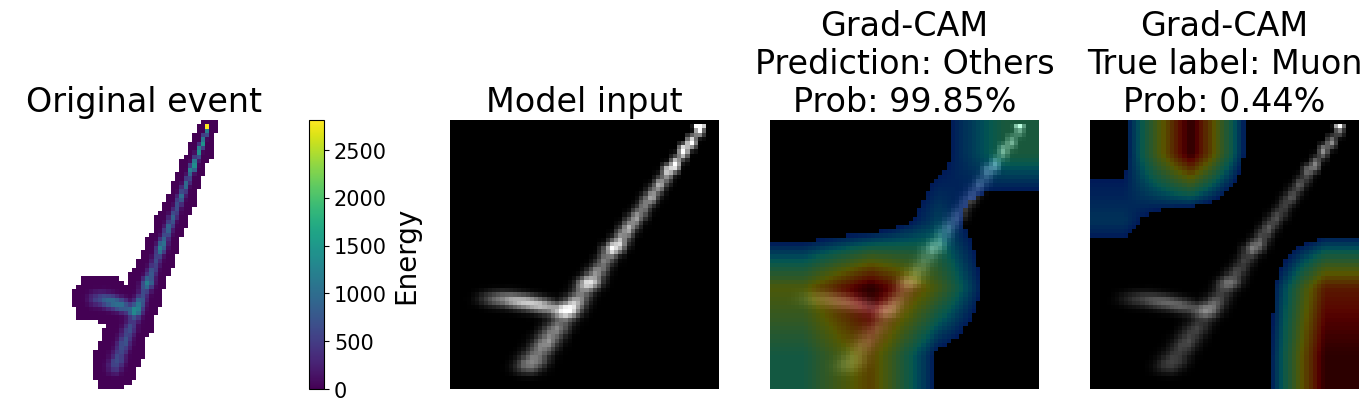

min: 0.0 max: 1.0 std: 0.2529685
min: 0.0 max: 1.0 std: 0.24752404


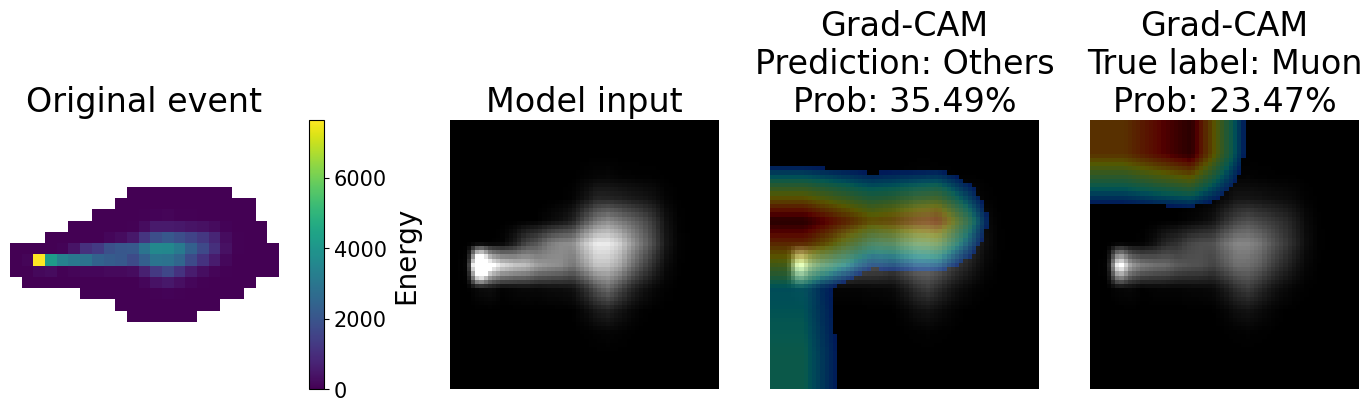

min: 0.0 max: 1.0 std: 0.25362173
min: 0.0 max: 1.0 std: 0.25624278


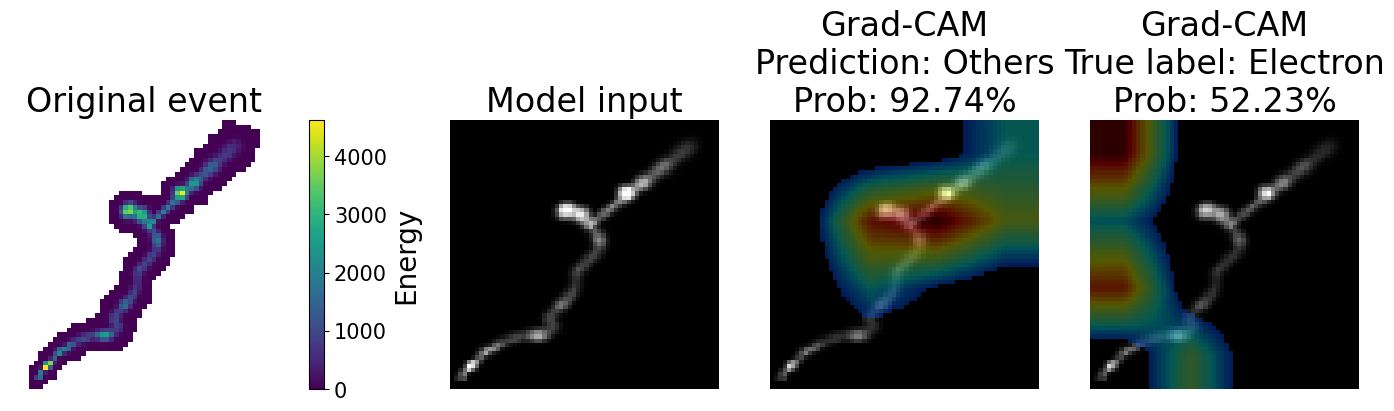

min: 0.0 max: 1.0 std: 0.31492144
min: 0.0 max: 1.0 std: 0.19865203


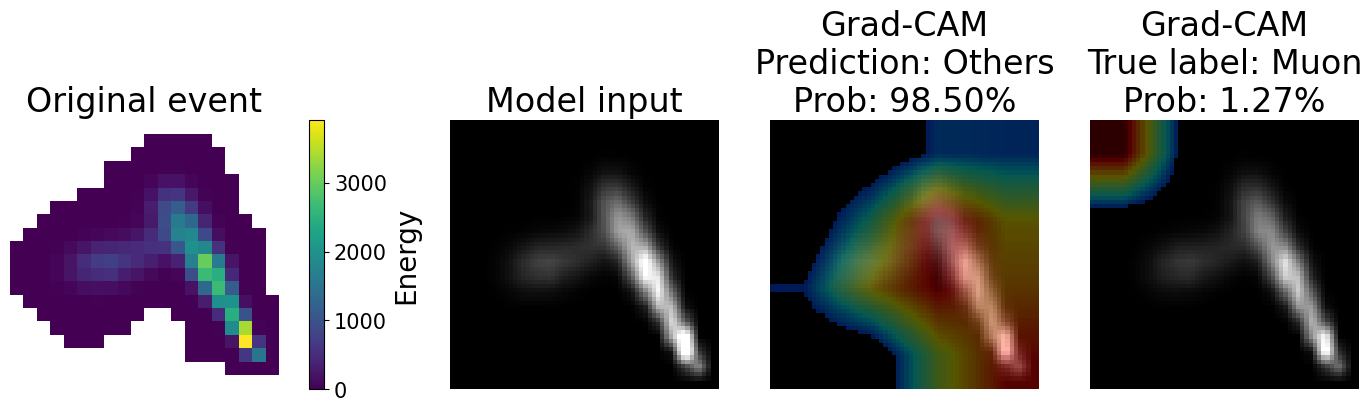

min: 0.0 max: 1.0 std: 0.31899253
min: 0.0 max: 1.0 std: 0.24204123


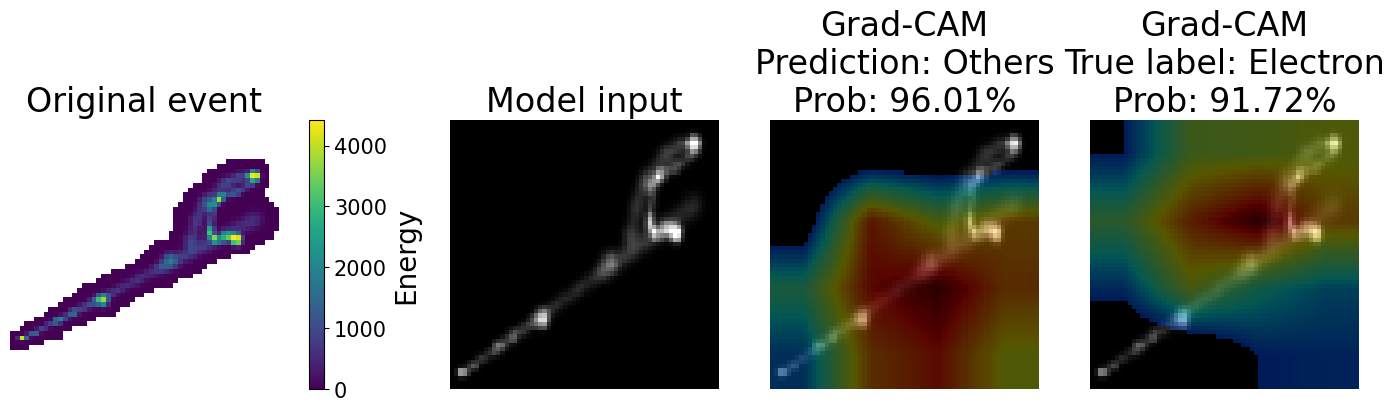

min: 0.0 max: 1.0 std: 0.19637768
min: 0.0 max: 1.0 std: 0.3335426


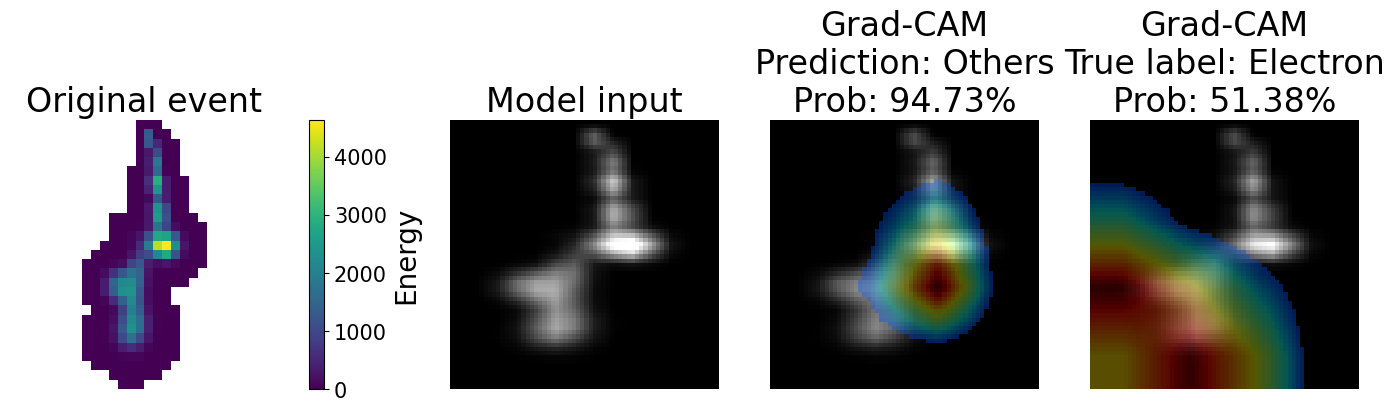

min: 0.0 max: 1.0 std: 0.25723255
min: 0.0 max: 1.0 std: 0.2798306


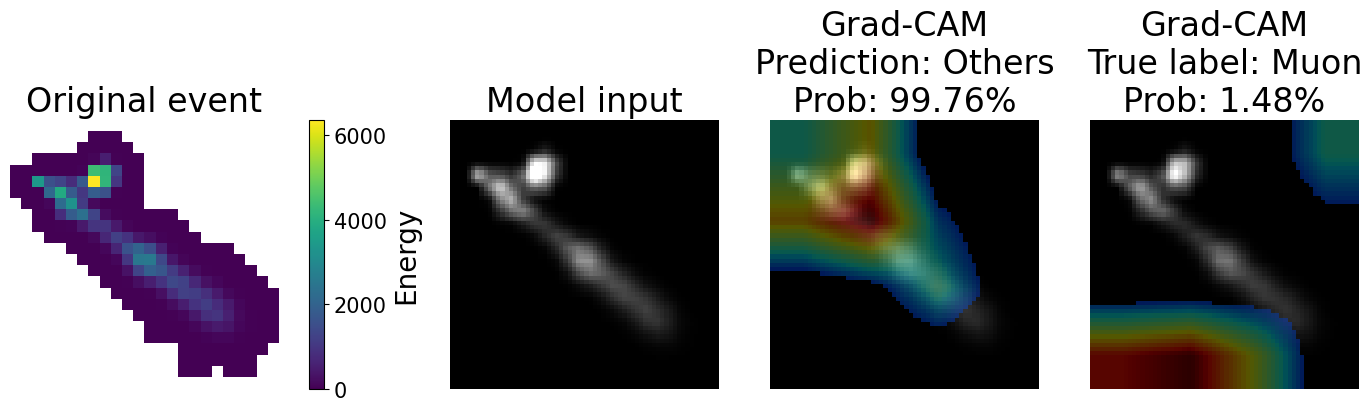

min: 0.0 max: 1.0 std: 0.29346818
min: 0.0 max: 1.0 std: 0.25954342


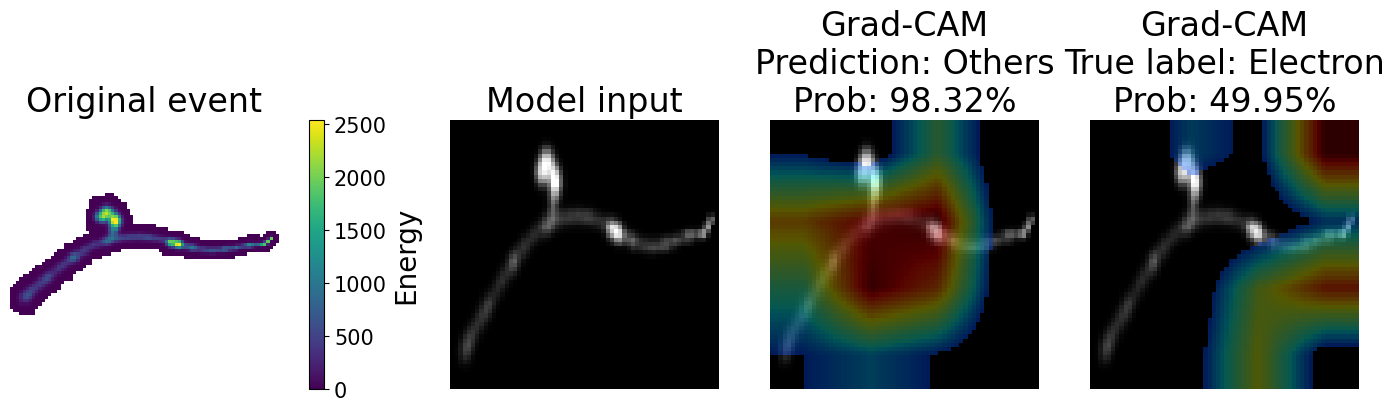

In [40]:
for class_name in class_names:
    print("\n===============================")
    print(f"FAILURES (main figs): {class_name}")
    print("===============================")
    for idx in incorrect_samples[class_name]:
        plot_failure_main_figure(idx)

## Saving Predictions

In [41]:
for class_idx, class_name in enumerate(class_names):
    print("\n===============================")
    print(f"Saving: {class_name}")
    print("===============================")

    correct_idx = np.where((preds_int == class_idx) & (y_true == class_idx))[0]

    incorrect_idx = np.where((preds_int == class_idx) & (y_true != class_idx))[0]

    print(f"Correct:   {len(correct_idx)}")
    print(f"Incorrect: {len(incorrect_idx)}")

    # Save all correct predictions
    for idx in correct_idx:
        plot_correct_main_figure(idx, save_img=True)

    # Save all incorrect predictions
    for idx in incorrect_idx:
        plot_failure_main_figure(idx, save_img=True)


Saving: Blob
Correct:   59
Incorrect: 13
min: 0.0 max: 1.0 std: 0.2659999
min: 0.0 max: 1.0 std: 0.21018471
min: 0.0 max: 1.0 std: 0.1988577
min: 0.0 max: 1.0 std: 0.21500063
min: 0.0 max: 1.0 std: 0.19319095
min: 0.0 max: 1.0 std: 0.21586962
min: 0.0 max: 1.0 std: 0.23219025
min: 0.0 max: 1.0 std: 0.28318888
min: 0.0 max: 1.0 std: 0.21881206
min: 0.0 max: 1.0 std: 0.2578589
min: 0.0 max: 1.0 std: 0.20864664
min: 0.0 max: 1.0 std: 0.206527
min: 0.0 max: 1.0 std: 0.20731029
min: 0.0 max: 1.0 std: 0.21091574
min: 0.0 max: 1.0 std: 0.24091299
min: 0.0 max: 1.0 std: 0.20145963
min: 0.0 max: 1.0 std: 0.21105517
min: 0.0 max: 1.0 std: 0.22786292
min: 0.0 max: 1.0 std: 0.29574242
min: 0.0 max: 1.0 std: 0.20423463
min: 0.0 max: 1.0 std: 0.272479
min: 0.0 max: 1.0 std: 0.22286005
min: 0.0 max: 1.0 std: 0.23863761
min: 0.0 max: 1.0 std: 0.23612373
min: 0.0 max: 1.0 std: 0.22921056
min: 0.0 max: 1.0 std: 0.24180403
min: 0.0 max: 1.0 std: 0.20427579
min: 0.0 max: 1.0 std: 0.21152164
min: 0.0 max: